# Leakage-Safe Residual Structure and Generalization Audit

## Purpose

Notebook 13 is a **post-freeze diagnostic notebook**. It does not repair, rerun, or change Notebook 12. Its job is to read the frozen Notebook 12 model artifacts and ask:

1. What residual structure remains after the frozen selected two-RC model?
2. Is the dominant error associated with SOC, temperature, current, chemistry, cell identity, or trajectory identity?
3. Does the evidence support a voltage-bias / OCV / hysteresis correction before making a larger LPV model?

The residual is defined as

$$
e_k = V_k - \hat V_k.
$$

The frozen two-RC prediction equation audited here is

$$
\hat V_k = OCV_k - R_{0,k} I_k - v_{1,k} - v_{2,k},
$$

with branch recursions

$$
v_{i,k+1}=\alpha_{i,k}v_{i,k}+R_{i,k}(1-\alpha_{i,k})I_k,
\qquad
\alpha_{i,k}=\exp\left(-\frac{\Delta t_k}{\tau_{i,k}}\right).
$$

This notebook treats SOC and OCV as inherited exogenous inputs from the upstream state-augmented dataset. It does not update SOC by coulomb counting.


In [1]:

# ======================================================================================
# CELL 1 — BOOTSTRAP NOTEBOOK 13 ENVIRONMENT AND OUTPUT DIRECTORIES
# ======================================================================================
# Mathematical role
# -----------------
# This notebook audits the frozen residual
#
#     e_k = V_k - \hat V_k,
#
# after Notebook 12 model freezing. It must not alter Notebook 12 artifacts.
# All new files are written under data/processed/notebook_13/.
# ======================================================================================

from __future__ import annotations

import json
import math
import os
import sys
import time
import hashlib
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable, Mapping

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.compute as pc
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# --------------------------------------------------------------------------------------
# Project-root discovery.
# The first path is the verified project location used throughout the battery LPV project.
# Additional fallbacks allow the notebook to run if the project is opened from its root.
# --------------------------------------------------------------------------------------
PROJECT_ROOT_CANDIDATES = [
    Path(os.environ.get("BATTERY_LPV_PROJECT_ROOT", "")).expanduser()
    if os.environ.get("BATTERY_LPV_PROJECT_ROOT")
    else None,
    Path("/home/xzkhu/Downloads/batter_lpv_project"),
    Path.cwd(),
    *Path.cwd().parents,
]

PROJECT_ROOT = None
for candidate in PROJECT_ROOT_CANDIDATES:
    if candidate is None:
        continue
    candidate = candidate.expanduser().resolve()
    if (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not locate the project root. Set BATTERY_LPV_PROJECT_ROOT or run "
        "this notebook inside the battery LPV project directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_12_ROOT = PROJECT_ROOT / "data" / "processed" / "notebook_12"
NOTEBOOK_12_DATA_DIR = NOTEBOOK_12_ROOT / "data"
NOTEBOOK_12_TABLE_DIR = NOTEBOOK_12_ROOT / "tables"
NOTEBOOK_12_MODEL_DIR = NOTEBOOK_12_ROOT / "models"
NOTEBOOK_12_CONTRACT_DIR = NOTEBOOK_12_ROOT / "contracts"

NOTEBOOK_13_ROOT = PROJECT_ROOT / "data" / "processed" / "notebook_13"
NOTEBOOK_13_DATA_DIR = NOTEBOOK_13_ROOT / "data"
NOTEBOOK_13_TABLE_DIR = NOTEBOOK_13_ROOT / "tables"
NOTEBOOK_13_FIGURE_DIR = NOTEBOOK_13_ROOT / "figures"
NOTEBOOK_13_CONTRACT_DIR = NOTEBOOK_13_ROOT / "contracts"
NOTEBOOK_13_MANIFEST_DIR = NOTEBOOK_13_ROOT / "manifests"

for directory in [
    NOTEBOOK_13_ROOT,
    NOTEBOOK_13_DATA_DIR,
    NOTEBOOK_13_TABLE_DIR,
    NOTEBOOK_13_FIGURE_DIR,
    NOTEBOOK_13_CONTRACT_DIR,
    NOTEBOOK_13_MANIFEST_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------------------------
# Notebook 13 controls.
# These controls affect only Notebook 13 audit outputs, never Notebook 12.
# --------------------------------------------------------------------------------------
RANDOM_SEED = 20260703
RNG = np.random.default_rng(RANDOM_SEED)

# Set to True only if you intentionally want to rebuild Notebook 13 prediction parquet files.
FORCE_REBUILD_NOTEBOOK_13_PREDICTIONS = False

# Keep as None for the full audit. Set to a small integer only for a quick smoke test.
NOTEBOOK_13_TRAJECTORY_LIMIT: int | None = None

# None means use all rows for tables. If memory is limited, set an integer such as 1_000_000.
MAX_ANALYSIS_ROWS: int | None = None

# Figures use a sample to avoid memory-heavy plotting.
FIGURE_SAMPLE_ROWS = 250_000

# Notebook 12 constants used by the frozen simulator.
LOSS_START_SAMPLE_INDEX = 1
INITIAL_REST_SAMPLES = 5
REST_CURRENT_A = 0.05

R_MIN_OHM = 1.0e-5
R_MAX_OHM = 1.0
TAU1_MIN_S = 1.0e-2
TAU1_MAX_S = 2.0e3
TAU_GAP_MIN_S = 1.0e-2
TAU_GAP_MAX_S = 2.0e4

LOG_R_MIN = float(np.log(R_MIN_OHM))
LOG_R_MAX = float(np.log(R_MAX_OHM))
LOG_TAU1_MIN = float(np.log(TAU1_MIN_S))
LOG_TAU1_MAX = float(np.log(TAU1_MAX_S))
LOG_TAU_GAP_MIN = float(np.log(TAU_GAP_MIN_S))
LOG_TAU_GAP_MAX = float(np.log(TAU_GAP_MAX_S))

TRAJECTORY_ID_SEPARATOR = "::"


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def atomic_write_json(path: Path, payload: Mapping[str, Any]) -> None:
    path = Path(path).expanduser().resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    with tmp.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2, sort_keys=True, default=str)
    os.replace(tmp, path)


def atomic_write_parquet(df: pd.DataFrame, path: Path) -> None:
    path = Path(path).expanduser().resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    df.to_parquet(tmp, index=False, compression="zstd")
    os.replace(tmp, path)


def file_sha256(path: Path, chunk_bytes: int = 8 * 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_bytes)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

print("=" * 110)
print("NOTEBOOK 13 BOOTSTRAP")
print("=" * 110)
print(f"Project root      : {PROJECT_ROOT}")
print(f"Notebook 12 root  : {NOTEBOOK_12_ROOT}")
print(f"Notebook 13 root  : {NOTEBOOK_13_ROOT}")
print("=" * 110)


NOTEBOOK 13 BOOTSTRAP
Project root      : /home/xzkhu/Downloads/batter_lpv_project
Notebook 12 root  : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12
Notebook 13 root  : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13


In [2]:

# ======================================================================================
# CELL 2 — LOCATE FROZEN NOTEBOOK 12 ARTIFACTS WITHOUT MODIFYING THEM
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 13 starts after model selection has been frozen. Therefore it may audit
# train, calibration, ordinary-test, and strict-test partitions, but it must not use
# these diagnostics to change Notebook 12. This cell only reads frozen artifacts.
# ======================================================================================

NOTEBOOK_12_PATHS = {
    "training_design_samples": NOTEBOOK_12_DATA_DIR / "lpv_training_design_samples.parquet",
    "calibration_design_samples": NOTEBOOK_12_DATA_DIR / "lpv_calibration_design_samples.parquet",
    "ordinary_test_design_samples": NOTEBOOK_12_DATA_DIR / "lpv_ordinary_test_design_samples.parquet",
    "strict_test_design_samples": NOTEBOOK_12_DATA_DIR / "lpv_strict_test_design_samples.parquet",
    "ordinary_test_predictions": NOTEBOOK_12_DATA_DIR / "lpv_ordinary_test_predictions.parquet",
    "strict_test_predictions": NOTEBOOK_12_DATA_DIR / "lpv_strict_test_predictions.parquet",
    "final_split_metrics": NOTEBOOK_12_TABLE_DIR / "lpv_final_split_metrics.parquet",
    "final_trajectory_metrics": NOTEBOOK_12_TABLE_DIR / "lpv_final_trajectory_metrics.parquet",
    "final_residual_correlations": NOTEBOOK_12_TABLE_DIR / "lpv_final_residual_correlations.parquet",
    "physical_stability_diagnostics": NOTEBOOK_12_TABLE_DIR / "lpv_physical_and_stability_diagnostics.parquet",
    "candidate_metrics": NOTEBOOK_12_TABLE_DIR / "lpv_calibration_candidate_metrics.parquet",
    "hypothesis_decisions": NOTEBOOK_12_TABLE_DIR / "lpv_hypothesis_decisions.parquet",
    "final_decision_summary": NOTEBOOK_12_TABLE_DIR / "lpv_final_decision_summary.parquet",
    "basis_terms": NOTEBOOK_12_TABLE_DIR / "lpv_candidate_basis_terms.parquet",
    "full_coefficient_index": NOTEBOOK_12_TABLE_DIR / "lpv_full_coefficient_index.parquet",
    "frozen_coefficients": NOTEBOOK_12_MODEL_DIR / "lpv_frozen_coefficients.npz",
    "model_selection_contract": NOTEBOOK_12_CONTRACT_DIR / "notebook12_model_selection_contract.json",
}

artifact_records = []
for role, path in NOTEBOOK_12_PATHS.items():
    path = Path(path)
    artifact_records.append(
        {
            "role": role,
            "path": str(path),
            "exists": bool(path.is_file()),
            "size_bytes": int(path.stat().st_size) if path.is_file() else 0,
            "sha256": file_sha256(path) if path.is_file() else None,
        }
    )

NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF = pd.DataFrame(artifact_records)
NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_PATH = NOTEBOOK_13_MANIFEST_DIR / "notebook_13_input_artifact_audit.parquet"
atomic_write_parquet(NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF, NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_PATH)

required_roles = [
    "training_design_samples",
    "calibration_design_samples",
    "ordinary_test_design_samples",
    "strict_test_design_samples",
    "basis_terms",
    "full_coefficient_index",
    "frozen_coefficients",
]
missing_required_roles = [
    role
    for role in required_roles
    if not bool(NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF.loc[NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF["role"].eq(role), "exists"].iloc[0])
]

if missing_required_roles:
    display(NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF)
    raise FileNotFoundError(
        "Notebook 13 requires the frozen Notebook 12 design/model artifacts listed below. "
        "Run Notebook 12 through model freezing and final design materialization first.\n  - "
        + "\n  - ".join(missing_required_roles)
    )

print("=" * 110)
print("NOTEBOOK 12 FROZEN ARTIFACT AUDIT")
print("=" * 110)
print(f"Artifact audit saved to : {NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_PATH}")
print("All required frozen artifacts are available.")
print("=" * 110)
display(NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_DF)


NOTEBOOK 12 FROZEN ARTIFACT AUDIT
Artifact audit saved to : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/manifests/notebook_13_input_artifact_audit.parquet
All required frozen artifacts are available.


,role,path,exists,size_bytes,sha256
0,training_design_samples,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,395092787,b934d2fb44cf0742d248da1e69506b26c6930cdc85545c...
1,calibration_design_samples,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,230936903,7ff9131f8da47e3eca56fb484c8c409b99a1f8e9277931...
2,ordinary_test_design_samples,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,260280598,40a3b8ffbe80d8caeb0cf50b8fc1ef8e34920e7600dd0e...
3,strict_test_design_samples,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,2086764,76fa1349f5d53ea79b5ea12eb7b8da1b0f832d671ea6ff...
4,ordinary_test_predictions,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,133552219,cfc600a13746589b6ff114ee05e01775480a48d10feb1c...
5,strict_test_predictions,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,1209569,f77d0aec7a44d311b25402bc63d6349cc3bfa33b4ee58c...
6,final_split_metrics,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,9390,ca95a068179471fc3339940196c03e69bcd9e1c065a509...
7,final_trajectory_metrics,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,305237,5524a4041fdc7a846f03670b032b05175364df4265858f...
8,final_residual_correlations,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,4034,705ca79de61c7b5fb528297770149b0aae28378c228b5f...
9,physical_stability_diagnostics,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,9921,443041c306ffa9d381299df43c402ab40ed11f4cf9bb7c...


In [3]:

# ======================================================================================
# CELL 3 — LOAD FROZEN MODEL METADATA AND STATE THE CORRECT MATHEMATICAL STATUS
# ======================================================================================
# Mathematical role
# -----------------
# If the selected candidate is M0_FIXED_2RC, then the final audited maps are constants:
#
#     R_i(z) = R_i,   tau_i(z) = tau_i.
#
# In that case Notebook 13 must not describe the frozen model as an accepted LPV model.
# ======================================================================================

NOTEBOOK_12_BASIS_TERM_DF = pd.read_parquet(NOTEBOOK_12_PATHS["basis_terms"])
NOTEBOOK_12_FULL_COEFFICIENT_INDEX_DF = pd.read_parquet(NOTEBOOK_12_PATHS["full_coefficient_index"])

frozen_archive = np.load(NOTEBOOK_12_PATHS["frozen_coefficients"], allow_pickle=False)
FROZEN_FULL_COEFFICIENTS = np.asarray(frozen_archive["full_coefficients"], dtype=np.float64).reshape(-1)
FROZEN_REDUCED_COEFFICIENTS = np.asarray(frozen_archive["reduced_coefficients"], dtype=np.float64).reshape(-1)

if "selected_candidate_id" in frozen_archive.files:
    SELECTED_CANDIDATE_ID = str(np.asarray(frozen_archive["selected_candidate_id"]).reshape(()).item())
else:
    SELECTED_CANDIDATE_ID = "UNKNOWN"

if "selected_job_id" in frozen_archive.files:
    SELECTED_JOB_ID = str(np.asarray(frozen_archive["selected_job_id"]).reshape(()).item())
else:
    SELECTED_JOB_ID = "UNKNOWN"

if "selected_regularization_lambda" in frozen_archive.files:
    SELECTED_REGULARIZATION_LAMBDA = float(np.asarray(frozen_archive["selected_regularization_lambda"]).reshape(()).item())
else:
    SELECTED_REGULARIZATION_LAMBDA = math.nan

if FROZEN_FULL_COEFFICIENTS.size != len(NOTEBOOK_12_FULL_COEFFICIENT_INDEX_DF):
    raise RuntimeError(
        "The frozen full coefficient vector length does not match the Notebook 12 full coefficient index.\n"
        f"Vector length: {FROZEN_FULL_COEFFICIENTS.size:,}\n"
        f"Index rows   : {len(NOTEBOOK_12_FULL_COEFFICIENT_INDEX_DF):,}"
    )

selected_model_is_lpv = SELECTED_CANDIDATE_ID != "M0_FIXED_2RC"

NOTEBOOK_13_MODEL_STATUS = {
    "selected_candidate_id": SELECTED_CANDIDATE_ID,
    "selected_job_id": SELECTED_JOB_ID,
    "selected_regularization_lambda": SELECTED_REGULARIZATION_LAMBDA,
    "selected_model_is_lpv": bool(selected_model_is_lpv),
    "correct_interpretation": (
        "LPV candidate selected"
        if selected_model_is_lpv
        else "Fixed two-RC selected; LPV adequacy is not supported by Notebook 12"
    ),
    "created_at_utc": utc_now_iso(),
}

NOTEBOOK_13_MODEL_STATUS_PATH = NOTEBOOK_13_CONTRACT_DIR / "notebook_13_frozen_model_status.json"
atomic_write_json(NOTEBOOK_13_MODEL_STATUS_PATH, NOTEBOOK_13_MODEL_STATUS)

print("=" * 110)
print("FROZEN MODEL STATUS")
print("=" * 110)
print(f"Selected candidate        : {SELECTED_CANDIDATE_ID}")
print(f"Selected job              : {SELECTED_JOB_ID}")
print(f"Selected lambda           : {SELECTED_REGULARIZATION_LAMBDA}")
print(f"Selected model is LPV     : {selected_model_is_lpv}")
print(f"Correct interpretation    : {NOTEBOOK_13_MODEL_STATUS['correct_interpretation']}")
print(f"Status contract           : {NOTEBOOK_13_MODEL_STATUS_PATH}")
print("=" * 110)


FROZEN MODEL STATUS
Selected candidate        : M0_FIXED_2RC
Selected job              : M0_FIXED_2RC__lambda_0p000e00
Selected lambda           : 0.0
Selected model is LPV     : False
Correct interpretation    : Fixed two-RC selected; LPV adequacy is not supported by Notebook 12
Status contract           : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/contracts/notebook_13_frozen_model_status.json


In [4]:

# ======================================================================================
# CELL 4 — DEFINE THE FROZEN TWO-RC SIMULATOR USED ONLY FOR DIAGNOSTIC MATERIALIZATION
# ======================================================================================
# Mathematical role
# -----------------
# This cell implements the frozen prediction equation exactly for Notebook 13 outputs:
#
#     Vhat_k = OCV_k - R0_k I_k - v1_k - v2_k
#
#     v1_{k+1} = alpha1_k v1_k + R1_k (1 - alpha1_k) I_k
#     v2_{k+1} = alpha2_k v2_k + R2_k (1 - alpha2_k) I_k
#
#     alpha_i,k = exp(-Delta t_k / tau_i,k)
#
# The transformed maps use the implemented Notebook 12 bounded exponential:
#
#     R_i = exp(clip(eta_Ri, log(R_min), log(R_max)))
#     tau1 = exp(clip(eta_tau1, log(tau1_min), log(tau1_max)))
#     tau2 = tau1 + exp(clip(eta_gap, log(gap_min), log(gap_max)))
#
# This is an audit materializer, not a Notebook 12 correction.
# ======================================================================================

basis_term_df = NOTEBOOK_12_BASIS_TERM_DF.copy()
full_index_df = NOTEBOOK_12_FULL_COEFFICIENT_INDEX_DF.copy()

for column in ["scope", "entity_id", "transformed_parameter"]:
    full_index_df[column] = full_index_df[column].astype(str).str.strip()
full_index_df["scope"] = full_index_df["scope"].str.upper()

BASIS_TERM_COUNT = int(basis_term_df["basis_position"].max()) + 1
PARAMETER_COUNT = int(full_index_df["parameter_position"].max()) + 1
BASIS_DESIGN_COLUMNS = tuple(f"phi_{position:03d}" for position in range(BASIS_TERM_COUNT))

if PARAMETER_COUNT != 5:
    raise RuntimeError(f"Expected five transformed parameter maps, observed {PARAMETER_COUNT}.")

# Basis positions for normalized SOC and temperature are used for scheduler OOD diagnostics.
def basis_position_by_id_or_expression(possible_ids: Iterable[str], possible_expressions: Iterable[str]) -> int | None:
    ids = {str(value).strip() for value in possible_ids}
    expressions = {str(value).strip() for value in possible_expressions}
    candidate = basis_term_df.loc[
        basis_term_df.get("basis_id", pd.Series(dtype=str)).astype(str).str.strip().isin(ids)
        | basis_term_df.get("basis_expression", pd.Series(dtype=str)).astype(str).str.strip().isin(expressions)
    ]
    if candidate.empty:
        return None
    return int(candidate.sort_values("basis_position").iloc[0]["basis_position"])

XI_SOC_BASIS_POSITION = basis_position_by_id_or_expression(
    ["basis__soc"],
    ["xi_soc"],
)
XI_TEMPERATURE_BASIS_POSITION = basis_position_by_id_or_expression(
    ["basis__temperature"],
    ["xi_temperature"],
)


def bounded_exp_numpy(values: np.ndarray, lower_log_bound: float, upper_log_bound: float) -> np.ndarray:
    return np.exp(np.clip(np.asarray(values, dtype=np.float64), lower_log_bound, upper_log_bound))


def effective_parameter_basis_coefficients(chemistry: str, cell_entity_id: str) -> np.ndarray:
    """Return a (5 x basis_count) matrix of effective eta coefficients.

    For each transformed parameter p and basis term b, the effective coefficient is

        beta_p,b = beta_global,p,b + beta_chemistry,p,b + beta_cell,p,b.

    If a held-out cell has no frozen cell effect, the cell contribution is zero.
    """
    chemistry = str(chemistry).strip().upper()
    cell_entity_id = str(cell_entity_id).strip()

    coeff_matrix = np.zeros((PARAMETER_COUNT, BASIS_TERM_COUNT), dtype=np.float64)

    eligible = (
        full_index_df["scope"].eq("GLOBAL")
        | (full_index_df["scope"].eq("CHEMISTRY") & full_index_df["entity_id"].astype(str).str.upper().eq(chemistry))
        | (full_index_df["scope"].eq("CELL") & full_index_df["entity_id"].astype(str).eq(cell_entity_id))
    )

    selected_rows = full_index_df.loc[eligible]
    for row in selected_rows.itertuples(index=False):
        coeff_matrix[int(row.parameter_position), int(row.basis_position)] += float(
            FROZEN_FULL_COEFFICIENTS[int(row.full_coefficient_index)]
        )

    return coeff_matrix


def simulate_one_trajectory(trajectory_data: Mapping[str, Any]) -> dict[str, np.ndarray | bool]:
    """Simulate one complete trajectory with the frozen two-RC equations."""
    basis_matrix = np.asarray(trajectory_data["basis_matrix"], dtype=np.float64)
    current = np.asarray(trajectory_data["current_discharge_a"], dtype=np.float64)
    voltage = np.asarray(trajectory_data["voltage_v"], dtype=np.float64)
    ocv = np.asarray(trajectory_data["ocv_v"], dtype=np.float64)
    delta_t = np.asarray(trajectory_data["delta_t_s"], dtype=np.float64).copy()

    if not np.isfinite(delta_t[-1]):
        delta_t[-1] = 0.0
    if np.any(delta_t[:-1] <= 0.0):
        raise RuntimeError(f"Nonpositive nonterminal Delta t in trajectory {trajectory_data['trajectory_uid']!r}.")

    coeff_matrix = effective_parameter_basis_coefficients(
        chemistry=str(trajectory_data["chemistry"]),
        cell_entity_id=str(trajectory_data["cell_entity_id"]),
    )

    # eta has columns [eta_R0, eta_R1, eta_R2, eta_tau1, eta_tau_gap].
    eta = basis_matrix @ coeff_matrix.T

    R0 = bounded_exp_numpy(eta[:, 0], LOG_R_MIN, LOG_R_MAX)
    R1 = bounded_exp_numpy(eta[:, 1], LOG_R_MIN, LOG_R_MAX)
    R2 = bounded_exp_numpy(eta[:, 2], LOG_R_MIN, LOG_R_MAX)
    tau1 = bounded_exp_numpy(eta[:, 3], LOG_TAU1_MIN, LOG_TAU1_MAX)
    tau_gap = bounded_exp_numpy(eta[:, 4], LOG_TAU_GAP_MIN, LOG_TAU_GAP_MAX)
    tau2 = tau1 + tau_gap

    n = int(voltage.size)
    alpha1 = np.exp(-delta_t / tau1)
    alpha2 = np.exp(-delta_t / tau2)
    one_minus_alpha1 = -np.expm1(-delta_t / tau1)
    one_minus_alpha2 = -np.expm1(-delta_t / tau2)

    rest_window_length = min(INITIAL_REST_SAMPLES, n)
    rest_start_detected = bool(np.all(np.abs(current[:rest_window_length]) <= REST_CURRENT_A))

    initial_total_polarization = ocv[0] - voltage[0] - R0[0] * current[0]
    branch_resistance_sum = R1[0] + R2[0]

    if rest_start_detected:
        v1_initial = 0.0
        v2_initial = 0.0
    else:
        v1_initial = initial_total_polarization * R1[0] / branch_resistance_sum
        v2_initial = initial_total_polarization * R2[0] / branch_resistance_sum

    v1 = np.zeros(n, dtype=np.float64)
    v2 = np.zeros(n, dtype=np.float64)
    v1[0] = v1_initial
    v2[0] = v2_initial

    for k in range(n - 1):
        v1[k + 1] = alpha1[k] * v1[k] + R1[k] * one_minus_alpha1[k] * current[k]
        v2[k + 1] = alpha2[k] * v2[k] + R2[k] * one_minus_alpha2[k] * current[k]

    predicted_voltage = ocv - R0 * current - v1 - v2
    residual = voltage - predicted_voltage

    return {
        "predicted_voltage_v": predicted_voltage,
        "residual_v": residual,
        "R0_ohm": R0,
        "R1_ohm": R1,
        "R2_ohm": R2,
        "tau1_s": tau1,
        "tau2_s": tau2,
        "tau_gap_s": tau_gap,
        "alpha1": alpha1,
        "alpha2": alpha2,
        "v1_state_v": v1,
        "v2_state_v": v2,
        "rest_start_detected": rest_start_detected,
    }

print("=" * 110)
print("FROZEN TWO-RC SIMULATOR READY")
print("=" * 110)
print(f"Parameter count       : {PARAMETER_COUNT}")
print(f"Basis-term count      : {BASIS_TERM_COUNT}")
print(f"xi_SOC basis position : {XI_SOC_BASIS_POSITION}")
print(f"xi_T basis position   : {XI_TEMPERATURE_BASIS_POSITION}")
print("=" * 110)


FROZEN TWO-RC SIMULATOR READY
Parameter count       : 5
Basis-term count      : 6
xi_SOC basis position : 1
xi_T basis position   : 2


In [5]:

# ======================================================================================
# CELL 5 — MATERIALIZE NOTEBOOK 13 FROZEN PREDICTIONS FOR ALL PARTITIONS
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 12 saved ordinary-test and strict-test sample predictions, but did not save
# train/calibration sample-level predictions. To audit all partitions without changing
# Notebook 12, this cell writes new Notebook 13 prediction parquet files using the frozen
# coefficients and the frozen design parquets.
#
# The evaluation mask excludes the first sample because the initial polarization state is
# initialized from that sample:
#
#     evaluation_sample_k = 1[k >= LOSS_START_SAMPLE_INDEX].
# ======================================================================================

PARTITION_DESIGN_PATHS = {
    "train": NOTEBOOK_12_PATHS["training_design_samples"],
    "calibration": NOTEBOOK_12_PATHS["calibration_design_samples"],
    "test": NOTEBOOK_12_PATHS["ordinary_test_design_samples"],
    "strict_test": NOTEBOOK_12_PATHS["strict_test_design_samples"],
}

NOTEBOOK_13_PREDICTION_PATHS = {
    partition: NOTEBOOK_13_DATA_DIR / f"notebook_13_frozen_{partition}_predictions.parquet"
    for partition in PARTITION_DESIGN_PATHS
}


def arrow_column_to_numpy(table: pa.Table, column_name: str, target_type: pa.DataType) -> np.ndarray:
    array = pc.cast(table[column_name], target_type, safe=False)
    return np.asarray(array.to_numpy(zero_copy_only=False))


def unique_required_string(table: pa.Table, column_name: str, row_group_index: int) -> str:
    values = [value for value in pc.unique(table[column_name]).to_pylist() if value is not None]
    if len(values) != 1:
        raise RuntimeError(
            f"Row group {row_group_index} has {len(values)} unique non-null values in {column_name!r}; expected one."
        )
    return str(values[0]).strip()


def load_design_row_group(design_path: Path, row_group_index: int) -> dict[str, Any]:
    parquet_file = pq.ParquetFile(design_path)
    schema_names = set(parquet_file.schema_arrow.names)

    required_columns = [
        "trajectory_uid",
        "chemistry",
        "cell_entity_id",
        "sample_index",
        "elapsed_time_s",
        "delta_t_to_next_s",
        "voltage_v",
        "current_discharge_a",
        "temperature_c",
        "soc_for_ocv",
        "ocv_v",
        *BASIS_DESIGN_COLUMNS,
    ]

    missing = [column for column in required_columns if column not in schema_names]
    if missing:
        raise RuntimeError(
            f"Design parquet {design_path} is missing required columns for Notebook 13 materialization:\n  - "
            + "\n  - ".join(missing)
        )

    optional_columns = [column for column in ["xi_soc", "xi_temperature"] if column in schema_names]

    table = parquet_file.read_row_group(
        row_group_index,
        columns=list(dict.fromkeys([*required_columns, *optional_columns])),
        use_threads=True,
    )

    n = int(table.num_rows)
    if n < 2:
        raise RuntimeError(f"Trajectory row group {row_group_index} in {design_path} has fewer than two samples.")

    trajectory_uid = unique_required_string(table, "trajectory_uid", row_group_index)
    chemistry = unique_required_string(table, "chemistry", row_group_index).upper()
    cell_entity_id = unique_required_string(table, "cell_entity_id", row_group_index)

    source_sample_index = arrow_column_to_numpy(table, "sample_index", pa.int64()).astype(np.int64)
    if np.any(np.diff(source_sample_index) <= 0):
        raise RuntimeError(f"Source sample index is not strictly increasing for trajectory {trajectory_uid!r}.")

    basis_matrix = np.column_stack([
        arrow_column_to_numpy(table, column, pa.float64()).astype(np.float64)
        for column in BASIS_DESIGN_COLUMNS
    ])

    if not np.isfinite(basis_matrix).all():
        raise RuntimeError(f"Basis matrix contains nonfinite values for trajectory {trajectory_uid!r}.")

    xi_soc = (
        arrow_column_to_numpy(table, "xi_soc", pa.float64()).astype(np.float64)
        if "xi_soc" in optional_columns
        else basis_matrix[:, XI_SOC_BASIS_POSITION]
        if XI_SOC_BASIS_POSITION is not None
        else np.full(n, np.nan)
    )

    xi_temperature = (
        arrow_column_to_numpy(table, "xi_temperature", pa.float64()).astype(np.float64)
        if "xi_temperature" in optional_columns
        else basis_matrix[:, XI_TEMPERATURE_BASIS_POSITION]
        if XI_TEMPERATURE_BASIS_POSITION is not None
        else np.full(n, np.nan)
    )

    delta_t = arrow_column_to_numpy(table, "delta_t_to_next_s", pa.float64()).astype(np.float64)
    if not np.isfinite(delta_t[-1]):
        delta_t[-1] = 0.0

    return {
        "trajectory_uid": trajectory_uid,
        "chemistry": chemistry,
        "cell_entity_id": cell_entity_id,
        "sample_count": n,
        "source_sample_index": source_sample_index,
        "trajectory_sample_index": np.arange(n, dtype=np.int64),
        "elapsed_time_s": arrow_column_to_numpy(table, "elapsed_time_s", pa.float64()).astype(np.float64),
        "delta_t_s": delta_t,
        "voltage_v": arrow_column_to_numpy(table, "voltage_v", pa.float64()).astype(np.float64),
        "current_discharge_a": arrow_column_to_numpy(table, "current_discharge_a", pa.float64()).astype(np.float64),
        "temperature_c": arrow_column_to_numpy(table, "temperature_c", pa.float64()).astype(np.float64),
        "soc_for_ocv": arrow_column_to_numpy(table, "soc_for_ocv", pa.float64()).astype(np.float64),
        "ocv_v": arrow_column_to_numpy(table, "ocv_v", pa.float64()).astype(np.float64),
        "basis_matrix": basis_matrix,
        "xi_soc": xi_soc,
        "xi_temperature": xi_temperature,
    }


def prediction_table_for_trajectory(partition: str, row_group_index: int, trajectory_data: Mapping[str, Any]) -> pa.Table:
    simulation = simulate_one_trajectory(trajectory_data)
    n = int(trajectory_data["sample_count"])
    repeated = lambda value: [value] * n

    return pa.table(
        {
            "trajectory_uid": pa.array(repeated(trajectory_data["trajectory_uid"]), type=pa.string()),
            "chemistry": pa.array(repeated(trajectory_data["chemistry"]), type=pa.string()),
            "cell_entity_id": pa.array(repeated(trajectory_data["cell_entity_id"]), type=pa.string()),
            "partition": pa.array(repeated(partition), type=pa.string()),
            "design_row_group_index": pa.array(np.full(n, row_group_index, dtype=np.int64), type=pa.int64()),
            "sample_index": pa.array(trajectory_data["trajectory_sample_index"], type=pa.int64()),
            "source_sample_index": pa.array(trajectory_data["source_sample_index"], type=pa.int64()),
            "elapsed_time_s": pa.array(trajectory_data["elapsed_time_s"], type=pa.float64()),
            "delta_t_s": pa.array(trajectory_data["delta_t_s"], type=pa.float64()),
            "soc_for_ocv": pa.array(trajectory_data["soc_for_ocv"], type=pa.float64()),
            "temperature_c": pa.array(trajectory_data["temperature_c"], type=pa.float64()),
            "current_discharge_a": pa.array(trajectory_data["current_discharge_a"], type=pa.float64()),
            "xi_soc": pa.array(trajectory_data["xi_soc"], type=pa.float64()),
            "xi_temperature": pa.array(trajectory_data["xi_temperature"], type=pa.float64()),
            "ocv_v": pa.array(trajectory_data["ocv_v"], type=pa.float64()),
            "measured_voltage_v": pa.array(trajectory_data["voltage_v"], type=pa.float64()),
            "predicted_voltage_v": pa.array(simulation["predicted_voltage_v"], type=pa.float64()),
            "residual_v": pa.array(simulation["residual_v"], type=pa.float64()),
            "R0_ohm": pa.array(simulation["R0_ohm"], type=pa.float64()),
            "R1_ohm": pa.array(simulation["R1_ohm"], type=pa.float64()),
            "R2_ohm": pa.array(simulation["R2_ohm"], type=pa.float64()),
            "tau1_s": pa.array(simulation["tau1_s"], type=pa.float64()),
            "tau2_s": pa.array(simulation["tau2_s"], type=pa.float64()),
            "tau_gap_s": pa.array(simulation["tau_gap_s"], type=pa.float64()),
            "alpha1": pa.array(simulation["alpha1"], type=pa.float64()),
            "alpha2": pa.array(simulation["alpha2"], type=pa.float64()),
            "v1_state_v": pa.array(simulation["v1_state_v"], type=pa.float64()),
            "v2_state_v": pa.array(simulation["v2_state_v"], type=pa.float64()),
            "rest_start_detected": pa.array(np.full(n, bool(simulation["rest_start_detected"]), dtype=bool), type=pa.bool_()),
            "evaluation_sample": pa.array(np.arange(n, dtype=np.int64) >= LOSS_START_SAMPLE_INDEX, type=pa.bool_()),
        }
    )


def materialize_partition_predictions(partition: str, design_path: Path, output_path: Path, trajectory_limit: int | None = None) -> dict[str, Any]:
    output_path = Path(output_path)

    if output_path.is_file() and not FORCE_REBUILD_NOTEBOOK_13_PREDICTIONS:
        return {
            "partition": partition,
            "prediction_path": str(output_path),
            "rebuilt": False,
            "trajectory_count": int(pq.ParquetFile(output_path).metadata.num_row_groups),
            "row_count": int(pq.ParquetFile(output_path).metadata.num_rows),
            "elapsed_seconds": 0.0,
        }

    design_file = pq.ParquetFile(design_path)
    row_group_count = int(design_file.metadata.num_row_groups)
    if trajectory_limit is not None:
        row_group_count = min(row_group_count, int(trajectory_limit))

    if row_group_count <= 0:
        raise RuntimeError(f"No row groups available for partition {partition!r}.")

    temporary_path = output_path.with_suffix(output_path.suffix + ".tmp")
    if temporary_path.exists():
        temporary_path.unlink()

    writer = None
    start = time.perf_counter()
    rows_written = 0

    try:
        for row_group_index in range(row_group_count):
            trajectory_data = load_design_row_group(design_path, row_group_index)
            table = prediction_table_for_trajectory(partition, row_group_index, trajectory_data)

            if writer is None:
                writer = pq.ParquetWriter(temporary_path, table.schema, compression="zstd")

            writer.write_table(table, row_group_size=table.num_rows)
            rows_written += int(table.num_rows)

            if (row_group_index + 1) % 25 == 0 or (row_group_index + 1) == row_group_count:
                print(f"{partition:12s} | {row_group_index + 1:6d}/{row_group_count:6d} trajectories materialized")

    except Exception:
        if writer is not None:
            writer.close()
        if temporary_path.exists():
            temporary_path.unlink()
        raise

    if writer is None:
        raise RuntimeError(f"No prediction rows were written for {partition!r}.")

    writer.close()
    os.replace(temporary_path, output_path)

    return {
        "partition": partition,
        "prediction_path": str(output_path),
        "rebuilt": True,
        "trajectory_count": row_group_count,
        "row_count": rows_written,
        "elapsed_seconds": float(time.perf_counter() - start),
    }

materialization_records = []
for partition, design_path in PARTITION_DESIGN_PATHS.items():
    materialization_records.append(
        materialize_partition_predictions(
            partition=partition,
            design_path=design_path,
            output_path=NOTEBOOK_13_PREDICTION_PATHS[partition],
            trajectory_limit=NOTEBOOK_13_TRAJECTORY_LIMIT,
        )
    )

NOTEBOOK_13_PREDICTION_MATERIALIZATION_DF = pd.DataFrame(materialization_records)
NOTEBOOK_13_PREDICTION_MATERIALIZATION_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_prediction_materialization.csv"
NOTEBOOK_13_PREDICTION_MATERIALIZATION_DF.to_csv(NOTEBOOK_13_PREDICTION_MATERIALIZATION_PATH, index=False)

print("=" * 110)
print("NOTEBOOK 13 FROZEN PREDICTION MATERIALIZATION")
print("=" * 110)
print(f"Materialization table : {NOTEBOOK_13_PREDICTION_MATERIALIZATION_PATH}")
print("=" * 110)
display(NOTEBOOK_13_PREDICTION_MATERIALIZATION_DF)


NOTEBOOK 13 FROZEN PREDICTION MATERIALIZATION
Materialization table : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_prediction_materialization.csv


,partition,prediction_path,rebuilt,trajectory_count,row_count,elapsed_seconds
0,train,/home/xzkhu/Downloads/batter_lpv_project/data/...,False,2832,8972544,0.0
1,calibration,/home/xzkhu/Downloads/batter_lpv_project/data/...,False,1017,4392705,0.0
2,test,/home/xzkhu/Downloads/batter_lpv_project/data/...,False,1080,4918294,0.0
3,strict_test,/home/xzkhu/Downloads/batter_lpv_project/data/...,False,9,35330,0.0


In [4]:
# ======================================================================================
# CELL 6 — LOAD AUDIT DATA AND VERIFY THE RESIDUAL DEFINITION
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 13 audits the frozen residual convention
#
#     e_k = V_k - Vhat_k,
#
# where
#
#     e_k    = residual_v,
#     V_k    = measured_voltage_v,
#     Vhat_k = predicted_voltage_v.
#
# Therefore, the defining identity is
#
#     residual_v = measured_voltage_v - predicted_voltage_v.
#
# A sign error would reverse the meaning of every residual-vs-SOC, residual-vs-temperature,
# and residual-vs-current diagnostic. This cell checks that identity before any further
# analysis is allowed.
#
# Practical correction
# --------------------
# The earlier Cell 6 assumed that NOTEBOOK_13_PREDICTION_PATHS already existed. That is
# true only if Cells 1–5 have run successfully. If Cell 6 is run alone, the variable may
# be absent. This corrected cell reads the Notebook 10/12 project layout and uses the
# actual Notebook 12 prediction paths:
#
#     /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/data/
#         lpv_ordinary_test_predictions.parquet
#         lpv_strict_test_predictions.parquet
#
# If Cell 5 already materialized Notebook 13 train/calibration/test/strict predictions,
# this cell prefers those Notebook 13 files. Otherwise it falls back to the frozen
# Notebook 12 ordinary-test and strict-test prediction files. It never modifies
# Notebook 12.
#
# Memory-safety rule
# ------------------
# Parquet files are streamed in row batches. The residual-definition audit is computed
# over all streamed evaluation rows, while only a bounded sample is kept in memory for
# later diagnostic tables and figures.
# ======================================================================================

from __future__ import annotations

import gc
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from IPython.display import display


# --------------------------------------------------------------------------------------
# 1. Stable fallback configuration
# --------------------------------------------------------------------------------------

if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 20260703

if "MAX_ANALYSIS_ROWS" not in globals():
    MAX_ANALYSIS_ROWS = 500_000

PARQUET_BATCH_SIZE = int(globals().get("PARQUET_BATCH_SIZE", 50_000))
MEMORY_SAFE_MAX_ANALYSIS_ROWS = int(globals().get("MEMORY_SAFE_MAX_ANALYSIS_ROWS", 500_000))

EFFECTIVE_MAX_ANALYSIS_ROWS = min(
    int(MAX_ANALYSIS_ROWS),
    int(MEMORY_SAFE_MAX_ANALYSIS_ROWS),
)

if EFFECTIVE_MAX_ANALYSIS_ROWS <= 0:
    raise ValueError("EFFECTIVE_MAX_ANALYSIS_ROWS must be positive.")


# --------------------------------------------------------------------------------------
# 2. Project-root discovery consistent with Notebooks 10 and 12
# --------------------------------------------------------------------------------------

def _root_score(candidate: Path) -> int:
    """
    Score a possible project root.

    The correct project root is the directory that contains the Notebook 12 processed
    artifact tree. A generic '/home/xzkhu/data' folder is not sufficient.
    """
    score = 0

    if (candidate / "data" / "processed" / "notebook_12").exists():
        score += 100

    if (candidate / "data" / "processed" / "notebook_11").exists():
        score += 30

    if (candidate / "data" / "published").exists():
        score += 20

    if (candidate / "data").exists():
        score += 1

    return score


def find_battery_project_root() -> Path:
    """
    Locate the battery LPV project root using the same priority as Notebook 10/12.
    """
    candidates: list[Path] = []

    env_root = os.environ.get("BATTERY_LPV_PROJECT_ROOT")
    if env_root:
        candidates.append(Path(env_root).expanduser())

    # Verified project-root candidates from Notebook 10 and Notebook 12.
    candidates.extend(
        [
            Path("/home/xzkhu/Downloads/batter_lpv_project"),
            Path("/home/xzkhu/Documents/batter_lpv_project"),
            Path.cwd(),
            *Path.cwd().parents,
        ]
    )

    unique_candidates: list[Path] = []
    seen: set[str] = set()

    for candidate in candidates:
        try:
            resolved = candidate.expanduser().resolve()
        except Exception:
            continue

        key = str(resolved)
        if key in seen:
            continue

        seen.add(key)
        unique_candidates.append(resolved)

    scored = [
        (_root_score(candidate), candidate)
        for candidate in unique_candidates
    ]

    scored = [
        item
        for item in scored
        if item[0] > 0
    ]

    if not scored:
        raise RuntimeError(
            "Could not locate the battery LPV project root. Set BATTERY_LPV_PROJECT_ROOT "
            "to the project directory, for example:\n"
            "/home/xzkhu/Downloads/batter_lpv_project"
        )

    scored.sort(key=lambda item: item[0], reverse=True)
    return scored[0][1]


if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = find_battery_project_root()
else:
    PROJECT_ROOT = Path(PROJECT_ROOT).expanduser().resolve()

# If an earlier bad root such as /home/xzkhu was selected, correct it now.
if _root_score(PROJECT_ROOT) < 100:
    PROJECT_ROOT = find_battery_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_12_ROOT = PROJECT_ROOT / "data" / "processed" / "notebook_12"
NOTEBOOK_12_DATA_DIR = NOTEBOOK_12_ROOT / "data"
NOTEBOOK_12_TABLE_DIR = NOTEBOOK_12_ROOT / "tables"

if "NOTEBOOK_13_ROOT" not in globals():
    NOTEBOOK_13_ROOT = PROJECT_ROOT / "data" / "processed" / "notebook_13"
else:
    NOTEBOOK_13_ROOT = Path(NOTEBOOK_13_ROOT).expanduser().resolve()

if "NOTEBOOK_13_DATA_DIR" not in globals():
    NOTEBOOK_13_DATA_DIR = NOTEBOOK_13_ROOT / "data"
else:
    NOTEBOOK_13_DATA_DIR = Path(NOTEBOOK_13_DATA_DIR).expanduser().resolve()

if "NOTEBOOK_13_TABLE_DIR" not in globals():
    NOTEBOOK_13_TABLE_DIR = NOTEBOOK_13_ROOT / "tables"
else:
    NOTEBOOK_13_TABLE_DIR = Path(NOTEBOOK_13_TABLE_DIR).expanduser().resolve()

NOTEBOOK_13_DATA_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_13_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------------------------------------------
# 3. Prediction columns needed for Notebook 13 diagnostics
# --------------------------------------------------------------------------------------

ANALYSIS_COLUMNS = [
    "trajectory_uid",
    "chemistry",
    "cell_entity_id",
    "partition",
    "design_row_group_index",
    "sample_index",
    "source_sample_index",
    "elapsed_time_s",
    "delta_t_s",
    "soc_for_ocv",
    "temperature_c",
    "current_discharge_a",
    "xi_soc",
    "xi_temperature",
    "ocv_v",
    "measured_voltage_v",
    "predicted_voltage_v",
    "residual_v",
    "R0_ohm",
    "R1_ohm",
    "R2_ohm",
    "tau1_s",
    "tau2_s",
    "tau_gap_s",
    "alpha1",
    "alpha2",
    "rest_start_detected",
    "evaluation_sample",
]

REQUIRED_RESIDUAL_COLUMNS = {
    "measured_voltage_v",
    "predicted_voltage_v",
    "residual_v",
}


# --------------------------------------------------------------------------------------
# 4. Prediction-path registry
# --------------------------------------------------------------------------------------

def _parquet_has_required_residual_columns(path: Path) -> bool:
    """
    Return True if a parquet file contains the three columns required for the residual
    sign audit.
    """
    try:
        parquet_file = pq.ParquetFile(path)
        names = set(parquet_file.schema_arrow.names)
    except Exception:
        return False

    return REQUIRED_RESIDUAL_COLUMNS.issubset(names)


def _collect_valid_prediction_paths_from_mapping(mapping: dict) -> dict[str, Path]:
    valid: dict[str, Path] = {}

    for key, value in mapping.items():
        path = Path(value).expanduser().resolve()

        if not path.is_file():
            continue

        if not _parquet_has_required_residual_columns(path):
            continue

        valid[str(key)] = path

    return valid


def build_prediction_path_registry() -> dict[str, Path]:
    """
    Prefer Notebook 13 materialized predictions when they exist. Otherwise fall back to
    the frozen Notebook 12 ordinary-test and strict-test prediction files.
    """
    registry: dict[str, Path] = {}

    # A. If Cell 5 has already run, use its Notebook 13 materialized files.
    if "NOTEBOOK_13_PREDICTION_PATHS" in globals():
        candidate_registry = _collect_valid_prediction_paths_from_mapping(
            dict(NOTEBOOK_13_PREDICTION_PATHS)
        )
        registry.update(candidate_registry)

    if registry:
        return registry

    # B. Explicit Notebook 13 materialized prediction paths.
    notebook_13_candidate_paths = {
        "train": NOTEBOOK_13_DATA_DIR / "notebook_13_frozen_train_predictions.parquet",
        "calibration": NOTEBOOK_13_DATA_DIR / "notebook_13_frozen_calibration_predictions.parquet",
        "test": NOTEBOOK_13_DATA_DIR / "notebook_13_frozen_test_predictions.parquet",
        "strict_test": NOTEBOOK_13_DATA_DIR / "notebook_13_frozen_strict_test_predictions.parquet",
    }

    registry.update(
        _collect_valid_prediction_paths_from_mapping(
            notebook_13_candidate_paths
        )
    )

    if registry:
        return registry

    # C. Preferred frozen Notebook 12 predictions from Cell 25.
    notebook_12_candidate_paths = {
        "test": NOTEBOOK_12_DATA_DIR / "lpv_ordinary_test_predictions.parquet",
        "strict_test": NOTEBOOK_12_DATA_DIR / "lpv_strict_test_predictions.parquet",
    }

    registry.update(
        _collect_valid_prediction_paths_from_mapping(
            notebook_12_candidate_paths
        )
    )

    if registry:
        return registry

    # D. Last resort: read prediction paths recorded in Notebook 12 final split metrics.
    final_split_metrics_path = NOTEBOOK_12_TABLE_DIR / "lpv_final_split_metrics.parquet"

    if final_split_metrics_path.is_file():
        try:
            split_metrics_df = pd.read_parquet(final_split_metrics_path)

            if "prediction_path" in split_metrics_df.columns:
                metric_paths: dict[str, Path] = {}

                for row in split_metrics_df.itertuples(index=False):
                    row_dict = row._asdict()
                    partition = str(row_dict.get("partition", "unknown"))
                    prediction_path = row_dict.get("prediction_path", None)

                    if prediction_path is None or str(prediction_path).strip() in {"", "None", "nan"}:
                        continue

                    metric_paths[partition] = Path(str(prediction_path))

                registry.update(
                    _collect_valid_prediction_paths_from_mapping(
                        metric_paths
                    )
                )
        except Exception as exc:
            print(
                "Could not inspect Notebook 12 final split metrics for prediction paths: "
                f"{type(exc).__name__}: {exc}"
            )

    return registry


NOTEBOOK_13_PREDICTION_PATHS = build_prediction_path_registry()

if not NOTEBOOK_13_PREDICTION_PATHS:
    expected_ordinary = NOTEBOOK_12_DATA_DIR / "lpv_ordinary_test_predictions.parquet"
    expected_strict = NOTEBOOK_12_DATA_DIR / "lpv_strict_test_predictions.parquet"

    raise RuntimeError(
        "No valid prediction parquet files were found.\n\n"
        "Notebook 13 Cell 6 needs prediction files containing:\n"
        "  measured_voltage_v, predicted_voltage_v, residual_v\n\n"
        "Expected Notebook 12 frozen prediction files:\n"
        f"  {expected_ordinary}\n"
        f"  {expected_strict}\n\n"
        "If these files are missing, run Notebook 12 through Cell 25 first. "
        "If you want train/calibration diagnostics too, run Notebook 13 Cells 1–5 first "
        "so Cell 5 materializes Notebook 13 prediction files. Notebook 12 is not modified."
    )

print("=" * 110)
print("PREDICTION FILES USED BY NOTEBOOK 13 CELL 6")
print("=" * 110)
print(f"Project root : {PROJECT_ROOT}")
for key, path in NOTEBOOK_13_PREDICTION_PATHS.items():
    print(f"{key:16s}: {path}")
print("=" * 110)


# --------------------------------------------------------------------------------------
# 5. Streaming helpers
# --------------------------------------------------------------------------------------

def _safe_numeric_array(frame: pd.DataFrame, column: str) -> np.ndarray:
    if column not in frame.columns:
        raise KeyError(f"Required column is missing from prediction data: {column}")

    return pd.to_numeric(
        frame[column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)


def _prepare_prediction_batch(batch_frame: pd.DataFrame, partition_name: str) -> pd.DataFrame:
    """
    Standardize one streamed parquet batch.
    """
    if "partition" not in batch_frame.columns:
        batch_frame["partition"] = str(partition_name)
    else:
        batch_frame["partition"] = batch_frame["partition"].astype(str)

    if "evaluation_sample" not in batch_frame.columns:
        batch_frame["evaluation_sample"] = True
    else:
        batch_frame["evaluation_sample"] = batch_frame["evaluation_sample"].astype(bool)

    return batch_frame


def _take_memory_safe_rows(frame: pd.DataFrame, rows_needed: int, seed: int) -> pd.DataFrame:
    """
    Retain at most rows_needed rows from one streamed batch.
    """
    if rows_needed <= 0:
        return frame.iloc[0:0].copy()

    if len(frame) <= rows_needed:
        return frame.copy()

    return frame.sample(
        n=rows_needed,
        random_state=seed,
    ).copy()


def read_prediction_dataframe_memory_safe() -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Stream prediction parquet files and verify

        residual_v = measured_voltage_v - predicted_voltage_v.

    The audit is computed on all streamed evaluation samples. The retained dataframe is
    only a memory-safe sample for later Notebook 13 diagnostics.
    """
    retained_frames: list[pd.DataFrame] = []

    retained_rows = 0
    total_rows_seen = 0
    evaluation_rows_seen = 0

    residual_finite_count = 0
    residual_nonfinite_count = 0
    max_abs_residual_definition_error = 0.0

    valid_prediction_files_seen = 0

    # Keep some data from each partition rather than exhausting the row budget on the
    # first large parquet file.
    per_partition_budget = max(
        1,
        int(np.ceil(EFFECTIVE_MAX_ANALYSIS_ROWS / max(len(NOTEBOOK_13_PREDICTION_PATHS), 1))),
    )

    for partition_name, path in NOTEBOOK_13_PREDICTION_PATHS.items():
        path = Path(path).expanduser().resolve()

        if not path.is_file():
            print(f"Skipping missing prediction file: {path}")
            continue

        parquet_file = pq.ParquetFile(path)
        available_columns = set(parquet_file.schema_arrow.names)

        missing_required = REQUIRED_RESIDUAL_COLUMNS.difference(available_columns)
        if missing_required:
            print(
                "Skipping parquet because required residual-audit columns are missing:\n"
                f"  {path}\n"
                f"  Missing: {sorted(missing_required)}"
            )
            continue

        valid_prediction_files_seen += 1

        columns_to_read = [
            column
            for column in ANALYSIS_COLUMNS
            if column in available_columns
        ]

        # Ensure the residual-audit columns are always read.
        for required_column in sorted(REQUIRED_RESIDUAL_COLUMNS):
            if required_column not in columns_to_read:
                columns_to_read.append(required_column)

        print(f"Streaming {partition_name!r}: {path}")
        print(f"  Rows       : {parquet_file.metadata.num_rows:,}")
        print(f"  Row groups : {parquet_file.metadata.num_row_groups:,}")
        print(f"  Columns    : {len(columns_to_read):,}")

        retained_for_this_partition = 0
        batch_number = 0

        for record_batch in parquet_file.iter_batches(
            batch_size=PARQUET_BATCH_SIZE,
            columns=columns_to_read,
        ):
            batch_number += 1

            batch_frame = record_batch.to_pandas()
            batch_frame = _prepare_prediction_batch(
                batch_frame=batch_frame,
                partition_name=str(partition_name),
            )

            total_rows_seen += int(len(batch_frame))

            evaluation_mask = batch_frame["evaluation_sample"].to_numpy(dtype=bool)
            evaluation_frame = batch_frame.loc[evaluation_mask]

            evaluation_rows_seen += int(len(evaluation_frame))

            if len(evaluation_frame) > 0:
                measured_voltage = _safe_numeric_array(
                    evaluation_frame,
                    "measured_voltage_v",
                )
                predicted_voltage = _safe_numeric_array(
                    evaluation_frame,
                    "predicted_voltage_v",
                )
                residual_voltage = _safe_numeric_array(
                    evaluation_frame,
                    "residual_v",
                )

                residual_difference = residual_voltage - (
                    measured_voltage - predicted_voltage
                )

                finite_mask = np.isfinite(residual_difference)
                residual_finite_count += int(np.sum(finite_mask))
                residual_nonfinite_count += int(np.sum(~finite_mask))

                if np.any(finite_mask):
                    max_abs_residual_definition_error = max(
                        max_abs_residual_definition_error,
                        float(np.max(np.abs(residual_difference[finite_mask]))),
                    )

            global_rows_remaining = EFFECTIVE_MAX_ANALYSIS_ROWS - retained_rows
            partition_rows_remaining = per_partition_budget - retained_for_this_partition
            rows_to_take = min(global_rows_remaining, partition_rows_remaining)

            if rows_to_take > 0:
                retained_batch = _take_memory_safe_rows(
                    frame=batch_frame,
                    rows_needed=rows_to_take,
                    seed=int(RANDOM_SEED + batch_number + 10_000 * valid_prediction_files_seen),
                )

                if len(retained_batch) > 0:
                    retained_frames.append(retained_batch)
                    retained_rows += int(len(retained_batch))
                    retained_for_this_partition += int(len(retained_batch))

            del batch_frame
            del evaluation_frame
            gc.collect()

        print(
            f"  Retained rows from {partition_name!r}: {retained_for_this_partition:,}"
        )

    if valid_prediction_files_seen <= 0:
        raise RuntimeError(
            "No valid prediction parquet files were found after schema checking."
        )

    if total_rows_seen <= 0:
        raise RuntimeError("Prediction parquet files were found, but no rows were streamed.")

    if not retained_frames:
        raise RuntimeError("No rows were retained for Notebook 13 diagnostics.")

    prediction_sample_df = pd.concat(
        retained_frames,
        ignore_index=True,
        copy=False,
    )

    audit_df = pd.DataFrame(
        [
            {
                "residual_definition": "residual_v = measured_voltage_v - predicted_voltage_v",
                "maximum_absolute_difference_v": float(max_abs_residual_definition_error),
                "passed": bool(max_abs_residual_definition_error <= 1.0e-10),
                "project_root": str(PROJECT_ROOT),
                "total_rows_streamed": int(total_rows_seen),
                "evaluation_sample_count_streamed": int(evaluation_rows_seen),
                "retained_analysis_rows": int(len(prediction_sample_df)),
                "finite_residual_difference_count": int(residual_finite_count),
                "nonfinite_residual_difference_count": int(residual_nonfinite_count),
                "valid_prediction_files_seen": int(valid_prediction_files_seen),
                "parquet_batch_size": int(PARQUET_BATCH_SIZE),
                "effective_max_analysis_rows": int(EFFECTIVE_MAX_ANALYSIS_ROWS),
            }
        ]
    )

    return prediction_sample_df, audit_df


# --------------------------------------------------------------------------------------
# 6. Execute the memory-safe load and residual-definition audit
# --------------------------------------------------------------------------------------

NOTEBOOK_13_PREDICTION_DF, NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF = (
    read_prediction_dataframe_memory_safe()
)

NOTEBOOK_13_EVALUATION_DF = NOTEBOOK_13_PREDICTION_DF.loc[
    NOTEBOOK_13_PREDICTION_DF["evaluation_sample"].astype(bool)
].copy()

if "current_discharge_a" in NOTEBOOK_13_EVALUATION_DF.columns:
    NOTEBOOK_13_EVALUATION_DF["abs_current_a"] = (
        pd.to_numeric(
            NOTEBOOK_13_EVALUATION_DF["current_discharge_a"],
            errors="coerce",
        )
        .abs()
        .astype(float)
    )
else:
    NOTEBOOK_13_EVALUATION_DF["abs_current_a"] = np.nan

max_residual_definition_error = float(
    NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF.loc[
        0,
        "maximum_absolute_difference_v",
    ]
)

residual_definition_passed = bool(
    NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF.loc[
        0,
        "passed",
    ]
)

NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_PATH = (
    NOTEBOOK_13_TABLE_DIR
    / "notebook_13_residual_definition_audit.csv"
)

NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF.to_csv(
    NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_PATH,
    index=False,
)

if not residual_definition_passed:
    display(NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF)
    raise RuntimeError(
        "Residual definition audit failed; diagnostic signs would be ambiguous."
    )

print("=" * 110)
print("RESIDUAL DEFINITION AUDIT")
print("=" * 110)
print(f"Project root                         : {PROJECT_ROOT}")
print(
    "Total rows streamed                  : "
    f"{int(NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF.loc[0, 'total_rows_streamed']):,}"
)
print(
    "Evaluation samples streamed          : "
    f"{int(NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF.loc[0, 'evaluation_sample_count_streamed']):,}"
)
print(f"Retained analysis rows               : {len(NOTEBOOK_13_PREDICTION_DF):,}")
print(f"Retained evaluation rows             : {len(NOTEBOOK_13_EVALUATION_DF):,}")
print(f"Maximum residual definition error    : {max_residual_definition_error:.3e} V")
print(f"Parquet batch size                   : {PARQUET_BATCH_SIZE:,}")
print(f"Effective maximum analysis rows      : {EFFECTIVE_MAX_ANALYSIS_ROWS:,}")
print(f"Audit table                          : {NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_PATH}")
print("=" * 110)

display(NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_DF)


PREDICTION FILES USED BY NOTEBOOK 13 CELL 6
Project root : /home/xzkhu/Downloads/batter_lpv_project
test            : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/data/lpv_ordinary_test_predictions.parquet
strict_test     : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/data/lpv_strict_test_predictions.parquet
Streaming 'test': /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/data/lpv_ordinary_test_predictions.parquet
  Rows       : 4,918,294
  Row groups : 1,080
  Columns    : 19
  Retained rows from 'test': 250,000
Streaming 'strict_test': /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/data/lpv_strict_test_predictions.parquet
  Rows       : 35,330
  Row groups : 9
  Columns    : 19
  Retained rows from 'strict_test': 35,330
RESIDUAL DEFINITION AUDIT
Project root                         : /home/xzkhu/Downloads/batter_lpv_project
Total rows streamed                  : 4,953,624
Evaluation samples stream

,residual_definition,maximum_absolute_difference_v,passed,project_root,total_rows_streamed,evaluation_sample_count_streamed,retained_analysis_rows,finite_residual_difference_count,nonfinite_residual_difference_count,valid_prediction_files_seen,parquet_batch_size,effective_max_analysis_rows
0,residual_v = measured_voltage_v - predicted_vo...,0.0,True,/home/xzkhu/Downloads/batter_lpv_project,4953624,4952535,285330,4952535,0,2,50000,500000


In [8]:

# ======================================================================================
# CELL 7 — GLOBAL RESIDUAL SUMMARY BY PARTITION
# ======================================================================================
# Mathematical role
# -----------------
# This cell summarizes the magnitude of
#
#     e_k = V_k - Vhat_k
#
# using pooled RMSE, MAE, bias, standard deviation, and high quantiles of |e_k|.
# ======================================================================================


def residual_summary(group: pd.DataFrame) -> pd.Series:
    residual = group["residual_v"].to_numpy(dtype=np.float64)
    abs_residual = np.abs(residual)
    return pd.Series(
        {
            "sample_count": int(residual.size),
            "trajectory_count": int(group["trajectory_uid"].nunique()),
            "chemistry_count": int(group["chemistry"].nunique()),
            "cell_count": int(group["cell_entity_id"].nunique()),
            "pooled_rmse_v": float(np.sqrt(np.mean(np.square(residual)))) if residual.size else math.nan,
            "pooled_mae_v": float(np.mean(abs_residual)) if residual.size else math.nan,
            "pooled_bias_v": float(np.mean(residual)) if residual.size else math.nan,
            "median_residual_v": float(np.median(residual)) if residual.size else math.nan,
            "residual_std_v": float(np.std(residual, ddof=1)) if residual.size > 1 else math.nan,
            "p95_abs_residual_v": float(np.quantile(abs_residual, 0.95)) if residual.size else math.nan,
            "p99_abs_residual_v": float(np.quantile(abs_residual, 0.99)) if residual.size else math.nan,
            "maximum_abs_residual_v": float(np.max(abs_residual)) if residual.size else math.nan,
        }
    )

NOTEBOOK_13_RESIDUAL_SUMMARY_DF = (
    NOTEBOOK_13_EVALUATION_DF
    .groupby("partition", sort=False, observed=True)
    .apply(residual_summary)
    .reset_index()
)

NOTEBOOK_13_RESIDUAL_SUMMARY_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_residual_summary.csv"
NOTEBOOK_13_RESIDUAL_SUMMARY_DF.to_csv(NOTEBOOK_13_RESIDUAL_SUMMARY_PATH, index=False)

print("=" * 110)
print("GLOBAL RESIDUAL SUMMARY")
print("=" * 110)
print(f"Saved to: {NOTEBOOK_13_RESIDUAL_SUMMARY_PATH}")
print("=" * 110)
display(NOTEBOOK_13_RESIDUAL_SUMMARY_DF)


GLOBAL RESIDUAL SUMMARY
Saved to: /home/xzkhu/data/processed/notebook_13/tables/notebook_13_residual_summary.csv


/tmp/ipykernel_16975/2842527353.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(residual_summary)


,partition,sample_count,trajectory_count,chemistry_count,cell_count,pooled_rmse_v,pooled_mae_v,pooled_bias_v,median_residual_v,residual_std_v,p95_abs_residual_v,p99_abs_residual_v,maximum_abs_residual_v
0,test,249930.0,70.0,1.0,1.0,0.164706,0.110061,0.012719,-0.011309,0.164215,0.402168,0.630803,0.894757
1,strict_test,35321.0,9.0,3.0,5.0,0.607619,0.449563,-0.448338,-0.416813,0.410120,1.137237,1.339135,1.676417


In [9]:

# ======================================================================================
# CELL 8 — RESIDUAL CORRELATION AUDIT
# ======================================================================================
# Mathematical role
# -----------------
# A well-specified residual should not retain strong systematic dependence on known
# operating variables. This cell estimates
#
#     rho(e, x)
#
# for SOC, temperature, current, |current|, elapsed time, and normalized schedulers.
# Pearson correlation captures linear dependence; Spearman correlation captures monotone
# nonlinear dependence.
# ======================================================================================

PREDICTOR_COLUMNS = [
    "soc_for_ocv",
    "temperature_c",
    "current_discharge_a",
    "abs_current_a",
    "elapsed_time_s",
    "delta_t_s",
    "xi_soc",
    "xi_temperature",
]

correlation_records: list[dict[str, Any]] = []
for partition, partition_df in NOTEBOOK_13_EVALUATION_DF.groupby("partition", sort=False, observed=True):
    for predictor in PREDICTOR_COLUMNS:
        if predictor not in partition_df.columns:
            continue
        pair_df = partition_df[["residual_v", predictor]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(pair_df) < 3 or pair_df[predictor].nunique(dropna=True) < 2:
            pearson = math.nan
            spearman = math.nan
        else:
            pearson = float(pair_df["residual_v"].corr(pair_df[predictor], method="pearson"))
            spearman = float(pair_df["residual_v"].corr(pair_df[predictor], method="spearman"))
        correlation_records.append(
            {
                "partition": partition,
                "predictor": predictor,
                "sample_count": int(len(pair_df)),
                "pearson_residual_correlation": pearson,
                "spearman_residual_correlation": spearman,
                "absolute_pearson_residual_correlation": abs(pearson) if np.isfinite(pearson) else math.nan,
                "absolute_spearman_residual_correlation": abs(spearman) if np.isfinite(spearman) else math.nan,
            }
        )

NOTEBOOK_13_RESIDUAL_CORRELATION_DF = pd.DataFrame(correlation_records)
NOTEBOOK_13_RESIDUAL_CORRELATION_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_residual_correlations.csv"
NOTEBOOK_13_RESIDUAL_CORRELATION_DF.to_csv(NOTEBOOK_13_RESIDUAL_CORRELATION_PATH, index=False)

print("=" * 110)
print("RESIDUAL CORRELATION AUDIT")
print("=" * 110)
print(f"Saved to: {NOTEBOOK_13_RESIDUAL_CORRELATION_PATH}")
print("=" * 110)
display(
    NOTEBOOK_13_RESIDUAL_CORRELATION_DF.sort_values(
        ["partition", "absolute_pearson_residual_correlation"],
        ascending=[True, False],
        kind="mergesort",
    )
)


RESIDUAL CORRELATION AUDIT
Saved to: /home/xzkhu/data/processed/notebook_13/tables/notebook_13_residual_correlations.csv


,partition,predictor,sample_count,pearson_residual_correlation,spearman_residual_correlation,absolute_pearson_residual_correlation,absolute_spearman_residual_correlation
6,strict_test,temperature_c,35321,-0.904732,-0.856739,0.904732,0.856739
9,strict_test,elapsed_time_s,35321,0.713053,0.608703,0.713053,0.608703
7,strict_test,current_discharge_a,35321,0.675903,0.673853,0.675903,0.673853
8,strict_test,abs_current_a,35321,-0.675903,-0.673853,0.675903,0.673853
5,strict_test,soc_for_ocv,35321,-0.022880,0.058947,0.022880,0.058947
0,test,soc_for_ocv,249930,-0.640957,-0.799158,0.640957,0.799158
4,test,elapsed_time_s,249930,-0.393879,-0.409368,0.393879,0.409368
2,test,current_discharge_a,249930,0.387509,0.476053,0.387509,0.476053
3,test,abs_current_a,249930,0.319684,0.376842,0.319684,0.376842
1,test,temperature_c,249930,0.135027,0.349341,0.135027,0.349341


In [10]:

# ======================================================================================
# CELL 9 — SOC, TEMPERATURE, AND CURRENT BINNED RESIDUAL DIAGNOSTICS
# ======================================================================================
# Mathematical role
# -----------------
# The conditional residual mean
#
#     E[e | x in bin]
#
# estimates systematic voltage bias as a function of an operating variable. A large
# bin-wise residual trend with SOC or temperature indicates a missing OCV/bias/hysteresis
# component rather than random noise.
# ======================================================================================


def summarize_binned_residuals(df: pd.DataFrame, bin_column: str, variable_name: str) -> pd.DataFrame:
    records = []
    for (partition, bin_value), group in df.groupby(["partition", bin_column], sort=False, observed=True):
        residual = group["residual_v"].to_numpy(dtype=np.float64)
        if residual.size == 0:
            continue
        records.append(
            {
                "partition": partition,
                "variable": variable_name,
                "bin": str(bin_value),
                "sample_count": int(residual.size),
                "mean_residual_v": float(np.mean(residual)),
                "median_residual_v": float(np.median(residual)),
                "rmse_v": float(np.sqrt(np.mean(np.square(residual)))),
                "mae_v": float(np.mean(np.abs(residual))),
                "p95_abs_residual_v": float(np.quantile(np.abs(residual), 0.95)),
            }
        )
    return pd.DataFrame(records)

bin_df = NOTEBOOK_13_EVALUATION_DF.copy()

# SOC bins are fixed because SOC has a natural physical range.
bin_df["soc_bin"] = pd.cut(
    bin_df["soc_for_ocv"],
    bins=np.linspace(0.0, 1.0, 11),
    include_lowest=True,
)

# Temperature bins use quantiles to avoid empty bins under uneven operating coverage.
temperature_edges = np.unique(np.quantile(bin_df["temperature_c"].dropna().to_numpy(dtype=np.float64), np.linspace(0.0, 1.0, 11)))
if temperature_edges.size >= 2:
    bin_df["temperature_bin"] = pd.cut(bin_df["temperature_c"], bins=temperature_edges, include_lowest=True)
else:
    bin_df["temperature_bin"] = pd.IntervalIndex.from_tuples([(math.nan, math.nan)])[0]

# Current-magnitude bins are also quantile based because current distributions are dataset-specific.
current_edges = np.unique(np.quantile(bin_df["current_discharge_a"].dropna().to_numpy(dtype=np.float64), np.linspace(0.0, 1.0, 11)))
if current_edges.size >= 2:
    bin_df["current_bin"] = pd.cut(bin_df["current_discharge_a"], bins=current_edges, include_lowest=True)
else:
    bin_df["current_bin"] = pd.IntervalIndex.from_tuples([(math.nan, math.nan)])[0]

NOTEBOOK_13_SOC_BINNED_RESIDUAL_DF = summarize_binned_residuals(bin_df.dropna(subset=["soc_bin"]), "soc_bin", "soc_for_ocv")
NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_DF = summarize_binned_residuals(bin_df.dropna(subset=["temperature_bin"]), "temperature_bin", "temperature_c")
NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_DF = summarize_binned_residuals(bin_df.dropna(subset=["current_bin"]), "current_bin", "current_discharge_a")

NOTEBOOK_13_SOC_BINNED_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_soc_binned_residuals.csv"
NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_temperature_binned_residuals.csv"
NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_current_binned_residuals.csv"

NOTEBOOK_13_SOC_BINNED_RESIDUAL_DF.to_csv(NOTEBOOK_13_SOC_BINNED_RESIDUAL_PATH, index=False)
NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_DF.to_csv(NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_PATH, index=False)
NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_DF.to_csv(NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_PATH, index=False)

print("=" * 110)
print("BINNED RESIDUAL DIAGNOSTICS")
print("=" * 110)
print(f"SOC bins         : {NOTEBOOK_13_SOC_BINNED_RESIDUAL_PATH}")
print(f"Temperature bins : {NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_PATH}")
print(f"Current bins     : {NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_PATH}")
print("=" * 110)
display(NOTEBOOK_13_SOC_BINNED_RESIDUAL_DF.head(20))
display(NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_DF.head(20))


BINNED RESIDUAL DIAGNOSTICS
SOC bins         : /home/xzkhu/data/processed/notebook_13/tables/notebook_13_soc_binned_residuals.csv
Temperature bins : /home/xzkhu/data/processed/notebook_13/tables/notebook_13_temperature_binned_residuals.csv
Current bins     : /home/xzkhu/data/processed/notebook_13/tables/notebook_13_current_binned_residuals.csv


,partition,variable,bin,sample_count,mean_residual_v,median_residual_v,rmse_v,mae_v,p95_abs_residual_v
0,test,soc_for_ocv,"(-0.001, 0.1]",74566,0.139524,0.115993,0.226618,0.156886,0.625341
1,test,soc_for_ocv,"(0.9, 1.0]",53772,-0.152086,-0.125200,0.198727,0.160130,0.402550
2,test,soc_for_ocv,"(0.8, 0.9]",66142,-0.042372,-0.029427,0.054690,0.042906,0.116164
3,test,soc_for_ocv,"(0.7, 0.8]",26181,0.020912,0.023600,0.031864,0.025692,0.065439
4,test,soc_for_ocv,"(0.6, 0.7]",3665,0.095001,0.097076,0.095417,0.095001,0.106159
5,test,soc_for_ocv,"(0.5, 0.6]",3670,0.110221,0.110291,0.110253,0.110221,0.114401
6,test,soc_for_ocv,"(0.4, 0.5]",10929,0.028704,0.027100,0.089293,0.072603,0.131045
7,test,soc_for_ocv,"(0.3, 0.4]",3669,0.147991,0.147532,0.148462,0.147991,0.166065
8,test,soc_for_ocv,"(0.2, 0.3]",3669,0.189792,0.188933,0.190337,0.189792,0.212377
9,test,soc_for_ocv,"(0.1, 0.2]",3667,0.246120,0.244331,0.247070,0.246120,0.284205


,partition,variable,bin,sample_count,mean_residual_v,median_residual_v,rmse_v,mae_v,p95_abs_residual_v
0,test,temperature_c,"(34.043, 36.243]",25885,0.107470,0.133093,0.222865,0.182239,0.493595
1,test,temperature_c,"(32.771, 34.043]",26340,0.193130,0.143493,0.297115,0.233612,0.630811
2,test,temperature_c,"(31.188, 32.771]",25810,0.101370,0.100969,0.182515,0.125634,0.448293
3,test,temperature_c,"(29.429, 31.188]",22895,-0.055582,-0.030595,0.116160,0.072925,0.179936
4,test,temperature_c,"(40.092, 47.729]",20338,-0.064453,-0.002007,0.166567,0.116077,0.365829
5,test,temperature_c,"(36.243, 40.092]",24623,0.028675,0.101293,0.143072,0.128301,0.252000
6,test,temperature_c,"(28.857, 29.429]",27777,-0.086846,-0.060364,0.147682,0.097442,0.401850
7,test,temperature_c,"(28.475, 28.857]",27765,-0.044603,-0.032731,0.072296,0.051459,0.121164
8,test,temperature_c,"(28.16, 28.475]",27643,-0.031068,-0.025527,0.058991,0.041352,0.117800
9,test,temperature_c,"(26.494, 28.16]",20854,-0.044088,-0.028859,0.063880,0.044411,0.210350


In [13]:
# ======================================================================================
# CELL 10 — CURRENT-REGIME RESIDUAL AUDIT
# ======================================================================================
# Mathematical role
# -----------------
# This cell checks whether the frozen Notebook 12 residual depends on current regime.
#
# The residual is
#
#     e_k = V_k - Vhat_k,
#
# where
#
#     V_k    = measured_voltage_v,
#     Vhat_k = predicted_voltage_v.
#
# The current convention inherited from the project is discharge-positive current:
#
#     I_k > 0       means discharge,
#     I_k < 0       means charge,
#     |I_k| small   means rest.
#
# A rest-current threshold I_rest is used:
#
#     rest       if |I_k| <= I_rest,
#     discharge  if I_k >  I_rest,
#     charge     if I_k < -I_rest.
#
# Notebook 12 used
#
#     I_rest = 0.05 A.
#
# The previous error occurred because REST_CURRENT_A was not defined in Notebook 13.
# This corrected cell defines it locally if it is missing, so Cell 10 no longer depends
# on hidden Notebook 12 kernel state.
# ======================================================================================

from pathlib import Path

import numpy as np
import pandas as pd


# ======================================================================================
# 1. DEFINE REST-CURRENT THRESHOLD ROBUSTLY
# ======================================================================================

if "REST_CURRENT_A" not in globals():
    REST_CURRENT_A = 0.05

REST_CURRENT_A = float(REST_CURRENT_A)

if not np.isfinite(REST_CURRENT_A):
    raise ValueError("REST_CURRENT_A must be finite.")

if REST_CURRENT_A < 0.0:
    raise ValueError("REST_CURRENT_A must be nonnegative.")


# ======================================================================================
# 2. VERIFY THAT CELL 6 HAS BEEN RUN
# ======================================================================================

if "NOTEBOOK_13_EVALUATION_DF" not in globals():
    raise RuntimeError(
        "NOTEBOOK_13_EVALUATION_DF is not defined. "
        "Run Notebook 13 Cell 6 before running Cell 10."
    )

if not isinstance(NOTEBOOK_13_EVALUATION_DF, pd.DataFrame):
    raise TypeError("NOTEBOOK_13_EVALUATION_DF must be a pandas DataFrame.")

if len(NOTEBOOK_13_EVALUATION_DF) == 0:
    raise RuntimeError("NOTEBOOK_13_EVALUATION_DF is empty.")


# ======================================================================================
# 3. RESOLVE REQUIRED COLUMNS
# ======================================================================================

def resolve_existing_column(
    dataframe: pd.DataFrame,
    candidate_names: tuple[str, ...],
    semantic_name: str,
) -> str:
    """
    Resolve one required column from a list of possible names.
    """
    for candidate_name in candidate_names:
        if candidate_name in dataframe.columns:
            return candidate_name

    raise RuntimeError(
        f"Could not find the column required for {semantic_name}.\n"
        f"Candidate names checked: {candidate_names}\n"
        f"Available columns: {list(dataframe.columns)}"
    )


partition_column = resolve_existing_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "partition",
        "split",
        "primary_split",
    ),
    "partition label",
)

current_column = resolve_existing_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "current_discharge_a",
        "current_a",
        "Current",
    ),
    "discharge-positive current",
)

residual_column = resolve_existing_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "residual_v",
        "voltage_residual_v",
        "prediction_error_v",
    ),
    "voltage residual",
)


# ======================================================================================
# 4. PREPARE CURRENT-REGIME DATAFRAME
# ======================================================================================

current_df = NOTEBOOK_13_EVALUATION_DF.copy()

current_df[partition_column] = current_df[partition_column].astype(str)

current_df[current_column] = pd.to_numeric(
    current_df[current_column],
    errors="coerce",
)

current_df[residual_column] = pd.to_numeric(
    current_df[residual_column],
    errors="coerce",
)

finite_mask = (
    np.isfinite(current_df[current_column].to_numpy(dtype=np.float64))
    &
    np.isfinite(current_df[residual_column].to_numpy(dtype=np.float64))
)

current_df = current_df.loc[finite_mask].copy()

if len(current_df) == 0:
    raise RuntimeError(
        "No finite current/residual samples are available for Cell 10."
    )

current_values = current_df[current_column].to_numpy(dtype=np.float64)

current_df["current_regime"] = np.select(
    [
        np.abs(current_values) <= REST_CURRENT_A,
        current_values > REST_CURRENT_A,
        current_values < -REST_CURRENT_A,
    ],
    [
        "rest",
        "discharge",
        "charge",
    ],
    default="unclassified",
)

current_df["abs_current_a"] = np.abs(current_values)


# ======================================================================================
# 5. DEFINE RESIDUAL SUMMARY
# ======================================================================================

def summarize_residual_vector(residual_values: np.ndarray) -> dict[str, float | int]:
    """
    Compute residual diagnostics for one group.

    For a group G, the diagnostics are

        sample_count = |G|,

        bias = mean(e_k),

        RMSE = sqrt(mean(e_k^2)),

        MAE = mean(|e_k|).

    The residual sign convention is

        e_k = measured_voltage_v - predicted_voltage_v.
    """
    residual_values = np.asarray(
        residual_values,
        dtype=np.float64,
    )

    residual_values = residual_values[np.isfinite(residual_values)]

    if residual_values.size == 0:
        return {
            "sample_count": 0,
            "mean_residual_v": np.nan,
            "median_residual_v": np.nan,
            "std_residual_v": np.nan,
            "rmse_v": np.nan,
            "mae_v": np.nan,
            "p95_abs_residual_v": np.nan,
            "p99_abs_residual_v": np.nan,
            "maximum_abs_residual_v": np.nan,
        }

    abs_residual_values = np.abs(residual_values)

    return {
        "sample_count": int(residual_values.size),
        "mean_residual_v": float(np.mean(residual_values)),
        "median_residual_v": float(np.median(residual_values)),
        "std_residual_v": float(np.std(residual_values, ddof=0)),
        "rmse_v": float(np.sqrt(np.mean(residual_values**2))),
        "mae_v": float(np.mean(abs_residual_values)),
        "p95_abs_residual_v": float(np.quantile(abs_residual_values, 0.95)),
        "p99_abs_residual_v": float(np.quantile(abs_residual_values, 0.99)),
        "maximum_abs_residual_v": float(np.max(abs_residual_values)),
    }


# ======================================================================================
# 6. COMPUTE PARTITION-BY-REGIME RESIDUAL SUMMARY
# ======================================================================================

records: list[dict[str, object]] = []

grouped = current_df.groupby(
    [
        partition_column,
        "current_regime",
    ],
    sort=False,
    observed=True,
)

for (partition_value, current_regime), group_df in grouped:
    residual_values = group_df[residual_column].to_numpy(dtype=np.float64)

    summary_record = summarize_residual_vector(residual_values)

    record = {
        "partition": str(partition_value),
        "current_regime": str(current_regime),
        "rest_current_threshold_a": REST_CURRENT_A,
        "current_column_used": current_column,
        "residual_column_used": residual_column,
    }

    record.update(summary_record)
    records.append(record)

NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_DF = pd.DataFrame(records)


# ======================================================================================
# 7. ADD REGIME FRACTIONS
# ======================================================================================

regime_counts_df = (
    current_df
    .groupby(
        [
            partition_column,
            "current_regime",
        ],
        sort=False,
        observed=True,
    )
    .size()
    .reset_index(name="regime_sample_count")
)

partition_counts_df = (
    current_df
    .groupby(
        partition_column,
        sort=False,
        observed=True,
    )
    .size()
    .reset_index(name="partition_sample_count")
)

regime_fraction_df = regime_counts_df.merge(
    partition_counts_df,
    on=partition_column,
    how="left",
)

regime_fraction_df["regime_sample_fraction"] = (
    regime_fraction_df["regime_sample_count"]
    /
    regime_fraction_df["partition_sample_count"]
)

regime_fraction_df = regime_fraction_df.rename(
    columns={
        partition_column: "partition",
    }
)

NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_DF = (
    NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_DF
    .merge(
        regime_fraction_df,
        on=[
            "partition",
            "current_regime",
        ],
        how="left",
    )
)


# ======================================================================================
# 8. SAVE TABLE TO THE PROJECT NOTEBOOK 13 TABLE DIRECTORY
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the project root consistently with Notebooks 10 and 12.

    Preferred project root:

        /home/xzkhu/Downloads/batter_lpv_project

    If that path is unavailable, fall back to PROJECT_ROOT if already defined.
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        return Path(PROJECT_ROOT).expanduser().resolve()

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_TABLE_DIR = (
    PROJECT_ROOT
    /
    "data"
    /
    "processed"
    /
    "notebook_13"
    /
    "tables"
)

NOTEBOOK_13_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_PATH = (
    NOTEBOOK_13_TABLE_DIR
    /
    "notebook_13_current_regime_residuals.csv"
)

NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_DF.to_csv(
    NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_PATH,
    index=False,
)


# ======================================================================================
# 9. DISPLAY RESULT
# ======================================================================================

print("=" * 110)
print("CURRENT-REGIME RESIDUAL AUDIT")
print("=" * 110)
print(f"Project root                 : {PROJECT_ROOT}")
print(f"Rest-current threshold        : {REST_CURRENT_A:.6f} A")
print(f"Current column used           : {current_column}")
print(f"Residual column used          : {residual_column}")
print(f"Rows used                     : {len(current_df):,}")
print(f"Saved to                      : {NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_PATH}")
print("=" * 110)

display(NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_DF)

CURRENT-REGIME RESIDUAL AUDIT
Project root                 : /home/xzkhu/Downloads/batter_lpv_project
Rest-current threshold        : 0.050000 A
Current column used           : current_discharge_a
Residual column used          : residual_v
Rows used                     : 285,251
Saved to                      : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_current_regime_residuals.csv


,partition,current_regime,rest_current_threshold_a,current_column_used,residual_column_used,sample_count,mean_residual_v,median_residual_v,std_residual_v,rmse_v,mae_v,p95_abs_residual_v,p99_abs_residual_v,maximum_abs_residual_v,regime_sample_count,partition_sample_count,regime_sample_fraction
0,test,rest,0.05,current_discharge_a,residual_v,206159,-0.019294,-0.023659,0.129604,0.131033,0.090620,0.289088,0.434093,0.590451,206159,249930,0.824867
1,test,discharge,0.05,current_discharge_a,residual_v,38493,0.204345,0.132063,0.195667,0.282918,0.210843,0.630833,0.630923,0.631083,38493,249930,0.154015
2,test,charge,0.05,current_discharge_a,residual_v,5278,-0.134371,-0.098938,0.110200,0.173780,0.134381,0.352872,0.626524,0.894757,5278,249930,0.021118
3,strict_test,rest,0.05,current_discharge_a,residual_v,18532,-0.162133,-0.017900,0.234716,0.285269,0.164468,0.592468,0.678435,1.003358,18532,35321,0.524674
4,strict_test,charge,0.05,current_discharge_a,residual_v,16789,-0.764256,-0.818936,0.320650,0.828796,0.764256,1.245497,1.385448,1.676417,16789,35321,0.475326


In [14]:

# ======================================================================================
# CELL 11 — CHEMISTRY, CELL, AND TRAJECTORY GENERALIZATION AUDITS
# ======================================================================================
# Mathematical role
# -----------------
# The hierarchy in Notebook 12 is intended to transfer across chemistry and cell identity.
# This cell asks whether residual error concentrates in a particular chemistry, cell, or
# trajectory:A
#
#     RMSE_chi,  RMSE_cell,  RMSE_trajectory.
# ======================================================================================

NOTEBOOK_13_CHEMISTRY_RESIDUAL_DF = (
    NOTEBOOK_13_EVALUATION_DF
    .groupby(["partition", "chemistry"], sort=False, observed=True)
    .apply(residual_summary)
    .reset_index()
    .sort_values(["partition", "pooled_rmse_v"], ascending=[True, False], kind="mergesort")
)

NOTEBOOK_13_CELL_RESIDUAL_DF = (
    NOTEBOOK_13_EVALUATION_DF
    .groupby(["partition", "chemistry", "cell_entity_id"], sort=False, observed=True)
    .apply(residual_summary)
    .reset_index()
    .sort_values(["partition", "pooled_rmse_v"], ascending=[True, False], kind="mergesort")
)

NOTEBOOK_13_TRAJECTORY_RESIDUAL_DF = (
    NOTEBOOK_13_EVALUATION_DF
    .groupby(["partition", "chemistry", "cell_entity_id", "trajectory_uid"], sort=False, observed=True)
    .apply(residual_summary)
    .reset_index()
    .sort_values(["partition", "pooled_rmse_v"], ascending=[True, False], kind="mergesort")
)

# Robust outlier flag by partition using Tukey's rule on trajectory RMSE.
outlier_frames = []
for partition, group in NOTEBOOK_13_TRAJECTORY_RESIDUAL_DF.groupby("partition", sort=False, observed=True):
    q1 = float(group["pooled_rmse_v"].quantile(0.25))
    q3 = float(group["pooled_rmse_v"].quantile(0.75))
    iqr = q3 - q1
    cutoff = q3 + 1.5 * iqr
    temp = group.copy()
    temp["trajectory_rmse_outlier_cutoff_v"] = cutoff
    temp["trajectory_rmse_outlier"] = temp["pooled_rmse_v"] > cutoff
    outlier_frames.append(temp)
NOTEBOOK_13_TRAJECTORY_RESIDUAL_DF = pd.concat(outlier_frames, ignore_index=True)

NOTEBOOK_13_CHEMISTRY_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_chemistry_residuals.csv"
NOTEBOOK_13_CELL_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_cell_residuals.csv"
NOTEBOOK_13_TRAJECTORY_RESIDUAL_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_trajectory_residuals.csv"

NOTEBOOK_13_CHEMISTRY_RESIDUAL_DF.to_csv(NOTEBOOK_13_CHEMISTRY_RESIDUAL_PATH, index=False)
NOTEBOOK_13_CELL_RESIDUAL_DF.to_csv(NOTEBOOK_13_CELL_RESIDUAL_PATH, index=False)
NOTEBOOK_13_TRAJECTORY_RESIDUAL_DF.to_csv(NOTEBOOK_13_TRAJECTORY_RESIDUAL_PATH, index=False)

print("=" * 110)
print("CHEMISTRY, CELL, AND TRAJECTORY AUDITS")
print("=" * 110)
print(f"Chemistry table  : {NOTEBOOK_13_CHEMISTRY_RESIDUAL_PATH}")
print(f"Cell table       : {NOTEBOOK_13_CELL_RESIDUAL_PATH}")
print(f"Trajectory table : {NOTEBOOK_13_TRAJECTORY_RESIDUAL_PATH}")
print("=" * 110)
display(NOTEBOOK_13_CHEMISTRY_RESIDUAL_DF)
display(NOTEBOOK_13_CELL_RESIDUAL_DF.head(20))
display(NOTEBOOK_13_TRAJECTORY_RESIDUAL_DF.head(20))


CHEMISTRY, CELL, AND TRAJECTORY AUDITS
Chemistry table  : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_chemistry_residuals.csv
Cell table       : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_cell_residuals.csv
Trajectory table : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_trajectory_residuals.csv


/tmp/ipykernel_16975/1260756444.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(residual_summary)
/tmp/ipykernel_16975/1260756444.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(residual_summary)
/tmp/ipykernel_16975/1260756444.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will 

,partition,chemistry,sample_count,trajectory_count,chemistry_count,cell_count,pooled_rmse_v,pooled_mae_v,pooled_bias_v,median_residual_v,residual_std_v,p95_abs_residual_v,p99_abs_residual_v,maximum_abs_residual_v
2,strict_test,NCA,28580.0,7.0,1.0,3.0,0.632379,0.467093,-0.465726,-0.497717,0.427795,1.153442,1.338437,1.430993
3,strict_test,NMC,4881.0,1.0,1.0,1.0,0.520922,0.372804,-0.372338,-0.325692,0.364350,1.027218,1.407398,1.676417
1,strict_test,LFP,1860.0,1.0,1.0,1.0,0.392682,0.381628,-0.380607,-0.365153,0.096656,0.531862,0.669322,0.812707
0,test,LFP,249930.0,70.0,1.0,1.0,0.164706,0.110061,0.012719,-0.011309,0.164215,0.402168,0.630803,0.894757


,partition,chemistry,cell_entity_id,sample_count,trajectory_count,chemistry_count,cell_count,pooled_rmse_v,pooled_mae_v,pooled_bias_v,median_residual_v,residual_std_v,p95_abs_residual_v,p99_abs_residual_v,maximum_abs_residual_v
2,strict_test,NCA,NCA::NCA_CELL_2,9809.0,3.0,1.0,1.0,0.699024,0.520192,-0.518928,-0.515405,0.468371,1.197157,1.352721,1.417937
3,strict_test,NCA,NCA::NCA_CELL_3,9851.0,2.0,1.0,1.0,0.674626,0.503214,-0.500628,-0.537556,0.452231,1.158687,1.339037,1.418337
5,strict_test,NMC,NMC::NMC_CELL_2,4881.0,1.0,1.0,1.0,0.520922,0.372804,-0.372338,-0.325692,0.364350,1.027218,1.407398,1.676417
4,strict_test,NCA,NCA::NCA_CELL_4,8920.0,2.0,1.0,1.0,0.491270,0.368813,-0.368676,-0.495408,0.324709,0.936422,1.306649,1.430993
1,strict_test,LFP,LFP::LFP_CELL_2,1860.0,1.0,1.0,1.0,0.392682,0.381628,-0.380607,-0.365153,0.096656,0.531862,0.669322,0.812707
0,test,LFP,LFP::LFP_CELL_1,249930.0,70.0,1.0,1.0,0.164706,0.110061,0.012719,-0.011309,0.164215,0.402168,0.630803,0.894757


,partition,chemistry,cell_entity_id,trajectory_uid,sample_count,trajectory_count,chemistry_count,cell_count,pooled_rmse_v,pooled_mae_v,pooled_bias_v,median_residual_v,residual_std_v,p95_abs_residual_v,p99_abs_residual_v,maximum_abs_residual_v,trajectory_rmse_outlier_cutoff_v,trajectory_rmse_outlier
0,strict_test,NCA,NCA::NCA_CELL_2,NCA::NCA_CELL_2::NCA_CELL_2::467,4879.0,1.0,1.0,1.0,0.709588,0.528333,-0.527522,-0.521049,0.474638,1.206187,1.355001,1.417337,0.984569,False
1,strict_test,NCA,NCA::NCA_CELL_2,NCA::NCA_CELL_2::NCA_CELL_2::491,4870.0,1.0,1.0,1.0,0.692029,0.515227,-0.513493,-0.532061,0.463976,1.188567,1.349398,1.417937,0.984569,False
2,strict_test,NCA,NCA::NCA_CELL_3,NCA::NCA_CELL_3::NCA_CELL_3::473,4909.0,1.0,1.0,1.0,0.676255,0.504008,-0.501560,-0.536835,0.453653,1.163797,1.342325,1.418337,0.984569,False
3,strict_test,NCA,NCA::NCA_CELL_3,NCA::NCA_CELL_3::NCA_CELL_3::449,4942.0,1.0,1.0,1.0,0.673004,0.502425,-0.499703,-0.538128,0.450857,1.153412,1.334922,1.417137,0.984569,False
4,strict_test,NMC,NMC::NMC_CELL_2,NMC::NMC_CELL_2::NMC_CELL_2::577,4881.0,1.0,1.0,1.0,0.520922,0.372804,-0.372338,-0.325692,0.364350,1.027218,1.407398,1.676417,0.984569,False
5,strict_test,NCA,NCA::NCA_CELL_4,NCA::NCA_CELL_4::NCA_CELL_4::601,4614.0,1.0,1.0,1.0,0.509707,0.385044,-0.384869,-0.549896,0.334217,0.952656,1.306536,1.421174,0.984569,False
6,strict_test,NCA,NCA::NCA_CELL_4,NCA::NCA_CELL_4::NCA_CELL_4::697,4306.0,1.0,1.0,1.0,0.470713,0.351420,-0.351324,-0.494507,0.313313,0.915654,1.305728,1.430993,0.984569,False
7,strict_test,LFP,LFP::LFP_CELL_2,LFP::LFP_CELL_2::LFP_CELL_2::539,1860.0,1.0,1.0,1.0,0.392682,0.381628,-0.380607,-0.365153,0.096656,0.531862,0.669322,0.812707,0.984569,False
8,strict_test,NCA,NCA::NCA_CELL_2,NCA::NCA_CELL_2::NCA_CELL_2::395,60.0,1.0,1.0,1.0,0.261654,0.261159,-0.261159,-0.265377,0.016218,0.279598,0.280444,0.280679,0.984569,False
9,test,LFP,LFP::LFP_CELL_1,LFP::LFP_CELL_1::LFP_CELL_1::609,1927.0,1.0,1.0,1.0,0.372180,0.253487,0.192151,-0.003399,0.318824,0.630895,0.630925,0.630933,0.160738,True


In [16]:
# ======================================================================================
# CELL 12 — SCHEDULER SUPPORT AND OUT-OF-DISTRIBUTION AUDIT
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 12 used SOC and temperature as scheduling variables:
#
#     z_k = [SOC_k, T_k]^T.
#
# The LPV basis was evaluated on normalized scheduler coordinates:
#
#     xi_SOC, xi_T.
#
# The diagnostic question in Notebook 13 is:
#
#     Are the ordinary-test and strict-test samples inside or outside the scheduler
#     support used during training?
#
# Ideally Notebook 12 prediction files would already contain:
#
#     xi_soc, xi_temperature.
#
# However, the available Notebook 12 prediction parquet files do not contain these
# columns. Therefore this cell is defensive:
#
#   1. If xi_soc and xi_temperature exist, it uses them directly.
#   2. If they do not exist, it reconstructs support-normalized scheduler coordinates
#      from raw SOC and temperature:
#
#          xi_x = (x - midpoint_train) / half_range_train
#
#      where
#
#          midpoint_train   = (x_train_max + x_train_min) / 2,
#          half_range_train = (x_train_max - x_train_min) / 2.
#
#   3. If a training-design parquet file is found, training min/max values are taken
#      from the training design file.
#   4. If no training file is found, it falls back to the retained prediction sample
#      and marks the source clearly.
#
# Interpretation
# --------------
# Under support-normalized coordinates:
#
#     |xi_x| <= 1
#
# means the sample lies inside the observed support used to define the normalizer.
#
#     |xi_x| > 1
#
# means the sample lies outside that support and the polynomial LPV basis may be
# extrapolating.
#
# This cell does not modify Notebook 12.
# ======================================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq


# ======================================================================================
# 1. VERIFY REQUIRED NOTEBOOK 13 DATA
# ======================================================================================

if "NOTEBOOK_13_EVALUATION_DF" not in globals():
    raise RuntimeError(
        "NOTEBOOK_13_EVALUATION_DF is not defined. "
        "Run the corrected Notebook 13 Cell 6 before running Cell 12."
    )

if not isinstance(NOTEBOOK_13_EVALUATION_DF, pd.DataFrame):
    raise TypeError("NOTEBOOK_13_EVALUATION_DF must be a pandas DataFrame.")

if len(NOTEBOOK_13_EVALUATION_DF) == 0:
    raise RuntimeError("NOTEBOOK_13_EVALUATION_DF is empty.")


# ======================================================================================
# 2. RESOLVE PROJECT ROOT AND OUTPUT DIRECTORY
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the verified project root used by Notebooks 10, 11, and 12.

    Preferred root:

        /home/xzkhu/Downloads/batter_lpv_project

    If that does not exist, fall back to PROJECT_ROOT if defined, then to the nearest
    parent directory containing a data folder.
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate.exists():
            return candidate

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_TABLE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_13"
    / "tables"
)

NOTEBOOK_13_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 3. COLUMN-RESOLUTION HELPERS
# ======================================================================================

def resolve_column(
    dataframe: pd.DataFrame,
    candidate_names: tuple[str, ...],
    semantic_name: str,
    required: bool = True,
) -> str | None:
    """
    Resolve one dataframe column from possible names.
    """
    for candidate_name in candidate_names:
        if candidate_name in dataframe.columns:
            return candidate_name

    if required:
        raise RuntimeError(
            f"Could not find required column for {semantic_name}.\n"
            f"Candidate names checked: {candidate_names}\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    return None


partition_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "partition",
        "split",
        "primary_split",
    ),
    "partition",
    required=True,
)

soc_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "soc_for_ocv",
        "soc",
        "SOC",
        "state_of_charge",
    ),
    "SOC scheduler",
    required=False,
)

temperature_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "temperature_c",
        "temperature",
        "Temperature",
        "cell_temperature_c",
    ),
    "temperature scheduler",
    required=False,
)

xi_soc_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "xi_soc",
        "xi_SOC",
        "normalized_soc",
        "soc_normalized",
    ),
    "normalized SOC scheduler",
    required=False,
)

xi_temperature_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    (
        "xi_temperature",
        "xi_T",
        "xi_temp",
        "normalized_temperature",
        "temperature_normalized",
    ),
    "normalized temperature scheduler",
    required=False,
)


# ======================================================================================
# 4. PARQUET TRAINING-SUPPORT HELPERS
# ======================================================================================

def parquet_columns(path: Path) -> set[str]:
    """
    Return parquet column names without loading the whole file.
    """
    return set(pq.ParquetFile(path).schema_arrow.names)


def discover_training_support_file() -> tuple[Path | None, str | None, str | None]:
    """
    Find a training design parquet file that contains SOC and temperature columns.

    This is used only when xi_soc and xi_temperature are missing from the prediction
    table. The search avoids test, strict-test, prediction, and residual files.
    """
    search_roots = [
        PROJECT_ROOT / "data" / "processed" / "notebook_12" / "data",
        PROJECT_ROOT / "data" / "processed" / "notebook_12",
        PROJECT_ROOT / "data" / "processed",
    ]

    filename_patterns = [
        "*train*design*.parquet",
        "*training*design*.parquet",
        "*fit*design*.parquet",
        "*train*.parquet",
        "*training*.parquet",
    ]

    soc_candidates = (
        "soc_for_ocv",
        "soc",
        "SOC",
        "state_of_charge",
    )

    temperature_candidates = (
        "temperature_c",
        "temperature",
        "Temperature",
        "cell_temperature_c",
    )

    candidate_paths: list[Path] = []

    for root in search_roots:
        if not root.exists():
            continue

        for pattern in filename_patterns:
            candidate_paths.extend(sorted(root.rglob(pattern)))

    filtered_paths: list[Path] = []

    for path in candidate_paths:
        name_lower = path.name.lower()

        if not path.is_file():
            continue

        if "prediction" in name_lower or "residual" in name_lower:
            continue

        if "ordinary" in name_lower or "strict" in name_lower or "test" in name_lower:
            continue

        if "calib" in name_lower or "calibration" in name_lower:
            continue

        filtered_paths.append(path)

    for path in filtered_paths:
        try:
            columns = parquet_columns(path)
        except Exception:
            continue

        found_soc = None
        found_temperature = None

        for candidate in soc_candidates:
            if candidate in columns:
                found_soc = candidate
                break

        for candidate in temperature_candidates:
            if candidate in columns:
                found_temperature = candidate
                break

        if found_soc is not None and found_temperature is not None:
            return path, found_soc, found_temperature

    return None, None, None


def compute_training_min_max_from_parquet(
    path: Path,
    soc_name: str,
    temperature_name: str,
    batch_size: int = 100_000,
) -> dict[str, float | int]:
    """
    Compute training SOC and temperature support in streaming mode.

    This avoids loading the full training design table into memory.
    """
    parquet_file = pq.ParquetFile(path)

    soc_min = np.inf
    soc_max = -np.inf
    temperature_min = np.inf
    temperature_max = -np.inf
    row_count = 0

    for record_batch in parquet_file.iter_batches(
        batch_size=batch_size,
        columns=[soc_name, temperature_name],
    ):
        batch_df = record_batch.to_pandas()

        soc_values = pd.to_numeric(
            batch_df[soc_name],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=np.float64)

        temperature_values = pd.to_numeric(
            batch_df[temperature_name],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=np.float64)

        if soc_values.size > 0:
            soc_min = min(soc_min, float(np.min(soc_values)))
            soc_max = max(soc_max, float(np.max(soc_values)))

        if temperature_values.size > 0:
            temperature_min = min(temperature_min, float(np.min(temperature_values)))
            temperature_max = max(temperature_max, float(np.max(temperature_values)))

        row_count += int(len(batch_df))

    if not np.isfinite(soc_min) or not np.isfinite(soc_max):
        raise RuntimeError(f"No finite SOC values were found in {path}")

    if not np.isfinite(temperature_min) or not np.isfinite(temperature_max):
        raise RuntimeError(f"No finite temperature values were found in {path}")

    return {
        "soc_min": float(soc_min),
        "soc_max": float(soc_max),
        "temperature_min": float(temperature_min),
        "temperature_max": float(temperature_max),
        "training_rows_scanned": int(row_count),
    }


def support_normalize(
    values: np.ndarray,
    minimum: float,
    maximum: float,
) -> np.ndarray:
    """
    Support-normalize a scheduler variable.

    Formula:

        xi = (x - midpoint) / half_range

    where

        midpoint   = (maximum + minimum) / 2,
        half_range = (maximum - minimum) / 2.
    """
    values = np.asarray(values, dtype=np.float64)

    midpoint = 0.5 * (float(maximum) + float(minimum))
    half_range = 0.5 * (float(maximum) - float(minimum))

    if not np.isfinite(half_range) or half_range <= 0.0:
        return np.full(values.shape, np.nan, dtype=np.float64)

    return (values - midpoint) / half_range


# ======================================================================================
# 5. PREPARE SCHEDULER COORDINATES
# ======================================================================================

scheduler_df = NOTEBOOK_13_EVALUATION_DF.copy()
scheduler_df[partition_column] = scheduler_df[partition_column].astype(str)

normalization_source = None
training_support_record: dict[str, object] = {}

# Case A: normalized columns already exist.
if xi_soc_column is not None and xi_temperature_column is not None:
    scheduler_df["scheduler_xi_soc"] = pd.to_numeric(
        scheduler_df[xi_soc_column],
        errors="coerce",
    )

    scheduler_df["scheduler_xi_temperature"] = pd.to_numeric(
        scheduler_df[xi_temperature_column],
        errors="coerce",
    )

    normalization_source = "stored_prediction_columns"

    training_support_record = {
        "normalization_source": normalization_source,
        "xi_soc_column_used": xi_soc_column,
        "xi_temperature_column_used": xi_temperature_column,
        "training_support_file": "",
        "soc_min": np.nan,
        "soc_max": np.nan,
        "temperature_min": np.nan,
        "temperature_max": np.nan,
        "training_rows_scanned": 0,
    }

# Case B: reconstruct from raw SOC and temperature.
else:
    if soc_column is None or temperature_column is None:
        raise RuntimeError(
            "Cell 12 cannot compute scheduler support because neither normalized "
            "scheduler columns nor raw SOC/temperature columns are available.\n"
            f"Available columns: {list(NOTEBOOK_13_EVALUATION_DF.columns)}"
        )

    training_file, training_soc_column, training_temperature_column = (
        discover_training_support_file()
    )

    if training_file is not None:
        support = compute_training_min_max_from_parquet(
            path=training_file,
            soc_name=training_soc_column,
            temperature_name=training_temperature_column,
        )

        normalization_source = "reconstructed_from_training_design_support"

        training_support_record = {
            "normalization_source": normalization_source,
            "xi_soc_column_used": "",
            "xi_temperature_column_used": "",
            "training_support_file": str(training_file),
            "training_soc_column": training_soc_column,
            "training_temperature_column": training_temperature_column,
            **support,
        }

    else:
        # Last-resort fallback. This prevents crashing, but it is not a strict training
        # support audit because the support comes from the retained evaluation sample.
        soc_values_for_support = pd.to_numeric(
            scheduler_df[soc_column],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=np.float64)

        temperature_values_for_support = pd.to_numeric(
            scheduler_df[temperature_column],
            errors="coerce",
        ).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=np.float64)

        if soc_values_for_support.size == 0:
            raise RuntimeError("No finite SOC values are available for fallback normalization.")

        if temperature_values_for_support.size == 0:
            raise RuntimeError("No finite temperature values are available for fallback normalization.")

        support = {
            "soc_min": float(np.min(soc_values_for_support)),
            "soc_max": float(np.max(soc_values_for_support)),
            "temperature_min": float(np.min(temperature_values_for_support)),
            "temperature_max": float(np.max(temperature_values_for_support)),
            "training_rows_scanned": 0,
        }

        normalization_source = "fallback_retained_prediction_sample_support"

        training_support_record = {
            "normalization_source": normalization_source,
            "xi_soc_column_used": "",
            "xi_temperature_column_used": "",
            "training_support_file": "",
            "training_soc_column": "",
            "training_temperature_column": "",
            **support,
        }

    raw_soc_values = pd.to_numeric(
        scheduler_df[soc_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    raw_temperature_values = pd.to_numeric(
        scheduler_df[temperature_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    scheduler_df["scheduler_xi_soc"] = support_normalize(
        values=raw_soc_values,
        minimum=float(training_support_record["soc_min"]),
        maximum=float(training_support_record["soc_max"]),
    )

    scheduler_df["scheduler_xi_temperature"] = support_normalize(
        values=raw_temperature_values,
        minimum=float(training_support_record["temperature_min"]),
        maximum=float(training_support_record["temperature_max"]),
    )


# ======================================================================================
# 6. SUMMARIZE SCHEDULER SUPPORT BY PARTITION
# ======================================================================================

def summarize_scheduler_coordinate(
    partition_value: str,
    scheduler_name: str,
    values: np.ndarray,
) -> dict[str, object]:
    """
    Summarize one normalized scheduler coordinate.

    Important values:
#
#     fraction_abs_gt_1 = fraction outside support-normalized interval [-1, 1].
#     fraction_abs_gt_2 = more severe extrapolation.
#     maximum_abs_value = maximum distance from center in half-range units.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {
            "partition": partition_value,
            "scheduler": scheduler_name,
            "sample_count": 0,
            "mean": np.nan,
            "std": np.nan,
            "minimum": np.nan,
            "maximum": np.nan,
            "p01": np.nan,
            "p05": np.nan,
            "p50": np.nan,
            "p95": np.nan,
            "p99": np.nan,
            "maximum_absolute_value": np.nan,
            "fraction_abs_gt_1": np.nan,
            "fraction_abs_gt_2": np.nan,
            "fraction_abs_gt_3": np.nan,
        }

    abs_values = np.abs(values)

    return {
        "partition": partition_value,
        "scheduler": scheduler_name,
        "sample_count": int(values.size),
        "mean": float(np.mean(values)),
        "std": float(np.std(values, ddof=0)),
        "minimum": float(np.min(values)),
        "maximum": float(np.max(values)),
        "p01": float(np.quantile(values, 0.01)),
        "p05": float(np.quantile(values, 0.05)),
        "p50": float(np.quantile(values, 0.50)),
        "p95": float(np.quantile(values, 0.95)),
        "p99": float(np.quantile(values, 0.99)),
        "maximum_absolute_value": float(np.max(abs_values)),
        "fraction_abs_gt_1": float(np.mean(abs_values > 1.0)),
        "fraction_abs_gt_2": float(np.mean(abs_values > 2.0)),
        "fraction_abs_gt_3": float(np.mean(abs_values > 3.0)),
    }


scheduler_records: list[dict[str, object]] = []

for partition_value, group_df in scheduler_df.groupby(
    partition_column,
    sort=False,
    observed=True,
):
    scheduler_records.append(
        summarize_scheduler_coordinate(
            partition_value=str(partition_value),
            scheduler_name="xi_soc",
            values=group_df["scheduler_xi_soc"].to_numpy(dtype=np.float64),
        )
    )

    scheduler_records.append(
        summarize_scheduler_coordinate(
            partition_value=str(partition_value),
            scheduler_name="xi_temperature",
            values=group_df["scheduler_xi_temperature"].to_numpy(dtype=np.float64),
        )
    )

NOTEBOOK_13_SCHEDULER_SUPPORT_DF = pd.DataFrame(scheduler_records)

NOTEBOOK_13_SCHEDULER_SUPPORT_DF.insert(
    2,
    "normalization_source",
    normalization_source,
)


# ======================================================================================
# 7. SAVE TABLES
# ======================================================================================

NOTEBOOK_13_SCHEDULER_SUPPORT_PATH = (
    NOTEBOOK_13_TABLE_DIR
    / "notebook_13_scheduler_support_audit.csv"
)

NOTEBOOK_13_SCHEDULER_SUPPORT_DF.to_csv(
    NOTEBOOK_13_SCHEDULER_SUPPORT_PATH,
    index=False,
)

NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_DF = pd.DataFrame(
    [
        training_support_record
    ]
)

NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_PATH = (
    NOTEBOOK_13_TABLE_DIR
    / "notebook_13_scheduler_support_metadata.csv"
)

NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_DF.to_csv(
    NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_PATH,
    index=False,
)


# ======================================================================================
# 8. DISPLAY RESULT
# ======================================================================================

print("=" * 110)
print("SCHEDULER SUPPORT AND OUT-OF-DISTRIBUTION AUDIT")
print("=" * 110)
print(f"Project root                : {PROJECT_ROOT}")
print(f"Normalization source         : {normalization_source}")
print(f"SOC column used              : {soc_column}")
print(f"Temperature column used      : {temperature_column}")
print(f"Scheduler audit table        : {NOTEBOOK_13_SCHEDULER_SUPPORT_PATH}")
print(f"Scheduler metadata table     : {NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_PATH}")
print("=" * 110)

display(NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_DF)
display(NOTEBOOK_13_SCHEDULER_SUPPORT_DF)

SCHEDULER SUPPORT AND OUT-OF-DISTRIBUTION AUDIT
Project root                : /home/xzkhu/Downloads/batter_lpv_project
Normalization source         : reconstructed_from_training_design_support
SOC column used              : soc_for_ocv
Temperature column used      : temperature_c
Scheduler audit table        : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_scheduler_support_audit.csv
Scheduler metadata table     : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_scheduler_support_metadata.csv


,normalization_source,xi_soc_column_used,xi_temperature_column_used,training_support_file,training_soc_column,training_temperature_column,soc_min,soc_max,temperature_min,temperature_max,training_rows_scanned
0,reconstructed_from_training_design_support,,,/home/xzkhu/Downloads/batter_lpv_project/data/...,soc_for_ocv,temperature_c,0.0,1.0,23.5929,57.9206,8972544


,partition,scheduler,normalization_source,sample_count,mean,std,minimum,maximum,p01,p05,p50,p95,p99,maximum_absolute_value,fraction_abs_gt_1,fraction_abs_gt_2,fraction_abs_gt_3
0,test,xi_soc,reconstructed_from_training_design_support,249930,0.126570,0.781068,-1.000000,1.000000,-0.982899,-0.968000,0.561661,0.964708,1.000000,1.000000,0.0,0.0,0.0
1,test,xi_temperature,reconstructed_from_training_design_support,249930,-0.494043,0.253099,-0.764027,0.273403,-0.751476,-0.741136,-0.576832,0.055495,0.177840,0.764027,0.0,0.0,0.0
2,strict_test,xi_soc,reconstructed_from_training_design_support,35321,0.935270,0.234309,-0.868052,1.000000,-0.431808,0.577090,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0
3,strict_test,xi_temperature,reconstructed_from_training_design_support,35321,-0.393162,0.342949,-0.830924,0.406211,-0.810960,-0.792343,-0.482604,0.194831,0.310422,0.830924,0.0,0.0,0.0


In [18]:
# ======================================================================================
# CELL 13 — PHYSICAL PARAMETER AND RECURSIVE STABILITY AUDIT
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 12 used the two-RC recursive model:
#
#     v_{1,k+1} = alpha_{1,k} v_{1,k}
#                 + R_{1,k}(1 - alpha_{1,k}) I_k
#
#     v_{2,k+1} = alpha_{2,k} v_{2,k}
#                 + R_{2,k}(1 - alpha_{2,k}) I_k
#
# with
#
#     alpha_{i,k} = exp(-Delta t_k / tau_{i,k}).
#
# Physical admissibility requires:
#
#     R0 > 0,
#     R1 > 0,
#     R2 > 0,
#     tau1 > 0,
#     tau2 > tau1.
#
# Recursive stability for positive sampling intervals requires:
#
#     0 < alpha_i < 1       whenever Delta t_k > 0.
#
# Important correction
# --------------------
# The Notebook 12 prediction parquet files used by Notebook 13 may not contain
#
#     delta_t_s
#
# and may also not contain
#
#     alpha1, alpha2.
#
# Therefore this cell is defensive:
#
#   1. If delta_t_s exists, it uses it.
#   2. If delta_t_s is missing but elapsed_time_s exists, it reconstructs Delta t
#      within each trajectory from elapsed_time_s.
#   3. If alpha1/alpha2 exist, it uses them.
#   4. If alpha1/alpha2 are missing but tau1_s/tau2_s and Delta t are available,
#      it reconstructs them using exp(-Delta t / tau).
#   5. If a diagnostic cannot be computed, it records NaN and marks that part as
#      unavailable rather than crashing.
#
# This cell does not modify Notebook 12.
# ======================================================================================

from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
from IPython.display import display


# ======================================================================================
# 1. VERIFY INPUT DATA
# ======================================================================================

if "NOTEBOOK_13_EVALUATION_DF" not in globals():
    raise RuntimeError(
        "NOTEBOOK_13_EVALUATION_DF is not defined. "
        "Run the corrected Notebook 13 Cell 6 before running Cell 13."
    )

if not isinstance(NOTEBOOK_13_EVALUATION_DF, pd.DataFrame):
    raise TypeError("NOTEBOOK_13_EVALUATION_DF must be a pandas DataFrame.")

if len(NOTEBOOK_13_EVALUATION_DF) == 0:
    raise RuntimeError("NOTEBOOK_13_EVALUATION_DF is empty.")


# ======================================================================================
# 2. RESOLVE PROJECT ROOT AND OUTPUT DIRECTORY
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the verified project root used by Notebooks 10, 11, and 12.
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate.exists():
            return candidate

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_TABLE_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_13"
    / "tables"
)

NOTEBOOK_13_TABLE_DIR.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 3. COLUMN RESOLUTION HELPERS
# ======================================================================================

def resolve_column(
    dataframe: pd.DataFrame,
    candidate_names: tuple[str, ...],
    semantic_name: str,
    required: bool = False,
) -> str | None:
    """
    Resolve one column name from possible alternatives.
    """
    for candidate_name in candidate_names:
        if candidate_name in dataframe.columns:
            return candidate_name

    if required:
        raise RuntimeError(
            f"Could not find required column for {semantic_name}.\n"
            f"Candidate names checked: {candidate_names}\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    return None


partition_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("partition", "split", "primary_split"),
    "partition",
    required=True,
)

trajectory_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("trajectory_uid", "trajectory_id", "trajectory_key"),
    "trajectory identity",
    required=False,
)

sample_index_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("sample_index", "row_index", "index"),
    "sample index",
    required=False,
)

elapsed_time_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("elapsed_time_s", "time_s", "Time_s", "time"),
    "elapsed time",
    required=False,
)

delta_t_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("delta_t_s", "dt_s", "sampling_interval_s"),
    "sampling interval",
    required=False,
)

alpha1_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("alpha1", "alpha_1", "alpha1_value"),
    "alpha1",
    required=False,
)

alpha2_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("alpha2", "alpha_2", "alpha2_value"),
    "alpha2",
    required=False,
)

r0_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("R0_ohm", "r0_ohm", "R0"),
    "R0",
    required=False,
)

r1_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("R1_ohm", "r1_ohm", "R1"),
    "R1",
    required=False,
)

r2_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("R2_ohm", "r2_ohm", "R2"),
    "R2",
    required=False,
)

tau1_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("tau1_s", "tau_1_s", "tau1"),
    "tau1",
    required=False,
)

tau2_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("tau2_s", "tau_2_s", "tau2"),
    "tau2",
    required=False,
)


# ======================================================================================
# 4. PREPARE PHYSICAL DIAGNOSTIC DATAFRAME
# ======================================================================================

physical_df = NOTEBOOK_13_EVALUATION_DF.copy()
physical_df[partition_column] = physical_df[partition_column].astype(str)

# Make numeric versions of available physical columns.
for column in [
    r0_column,
    r1_column,
    r2_column,
    tau1_column,
    tau2_column,
    alpha1_column,
    alpha2_column,
    delta_t_column,
    elapsed_time_column,
]:
    if column is not None and column in physical_df.columns:
        physical_df[column] = pd.to_numeric(
            physical_df[column],
            errors="coerce",
        )


# ======================================================================================
# 5. RECONSTRUCT delta_t_s IF IT IS MISSING
# ======================================================================================

if delta_t_column is not None:
    physical_df["notebook_13_delta_t_s"] = physical_df[delta_t_column].astype(float)
    delta_t_source = f"stored column: {delta_t_column}"

else:
    if elapsed_time_column is None:
        physical_df["notebook_13_delta_t_s"] = np.nan
        delta_t_source = "unavailable: no delta_t_s and no elapsed_time_s"

    else:
        sort_columns: list[str] = []

        if trajectory_column is not None:
            sort_columns.append(trajectory_column)

        if sample_index_column is not None:
            sort_columns.append(sample_index_column)
        else:
            sort_columns.append(elapsed_time_column)

        # Preserve original row order after reconstruction.
        physical_df["_notebook_13_original_order"] = np.arange(len(physical_df))

        physical_df = physical_df.sort_values(
            sort_columns,
            kind="mergesort",
        ).copy()

        if trajectory_column is not None:
            physical_df["notebook_13_delta_t_s"] = (
                physical_df
                .groupby(trajectory_column, sort=False, observed=True)[elapsed_time_column]
                .diff()
            )
        else:
            physical_df["notebook_13_delta_t_s"] = physical_df[elapsed_time_column].diff()

        # First sample in each trajectory has undefined diff. For the stability audit,
        # it should not be treated as a positive transition.
        physical_df["notebook_13_delta_t_s"] = (
            physical_df["notebook_13_delta_t_s"]
            .replace([np.inf, -np.inf], np.nan)
        )

        physical_df = physical_df.sort_values(
            "_notebook_13_original_order",
            kind="mergesort",
        ).drop(columns=["_notebook_13_original_order"])

        delta_t_source = f"reconstructed from {elapsed_time_column}"


# Negative or zero time differences are not positive transitions.
physical_df["notebook_13_positive_dt"] = (
    pd.to_numeric(
        physical_df["notebook_13_delta_t_s"],
        errors="coerce",
    )
    .to_numpy(dtype=np.float64)
    > 0.0
)


# ======================================================================================
# 6. RECONSTRUCT alpha1 AND alpha2 IF THEY ARE MISSING
# ======================================================================================

if alpha1_column is not None:
    physical_df["notebook_13_alpha1"] = physical_df[alpha1_column].astype(float)
    alpha1_source = f"stored column: {alpha1_column}"
else:
    if tau1_column is not None:
        dt_values = physical_df["notebook_13_delta_t_s"].to_numpy(dtype=np.float64)
        tau1_values = physical_df[tau1_column].to_numpy(dtype=np.float64)

        with np.errstate(over="ignore", under="ignore", invalid="ignore", divide="ignore"):
            physical_df["notebook_13_alpha1"] = np.exp(-dt_values / tau1_values)

        alpha1_source = f"reconstructed from delta_t and {tau1_column}"
    else:
        physical_df["notebook_13_alpha1"] = np.nan
        alpha1_source = "unavailable: no alpha1 and no tau1_s"


if alpha2_column is not None:
    physical_df["notebook_13_alpha2"] = physical_df[alpha2_column].astype(float)
    alpha2_source = f"stored column: {alpha2_column}"
else:
    if tau2_column is not None:
        dt_values = physical_df["notebook_13_delta_t_s"].to_numpy(dtype=np.float64)
        tau2_values = physical_df[tau2_column].to_numpy(dtype=np.float64)

        with np.errstate(over="ignore", under="ignore", invalid="ignore", divide="ignore"):
            physical_df["notebook_13_alpha2"] = np.exp(-dt_values / tau2_values)

        alpha2_source = f"reconstructed from delta_t and {tau2_column}"
    else:
        physical_df["notebook_13_alpha2"] = np.nan
        alpha2_source = "unavailable: no alpha2 and no tau2_s"


# ======================================================================================
# 7. NUMERIC SUMMARY HELPERS
# ======================================================================================

def finite_values(dataframe: pd.DataFrame, column: str | None) -> np.ndarray:
    """
    Return finite numeric values from a dataframe column.
    """
    if column is None or column not in dataframe.columns:
        return np.array([], dtype=np.float64)

    values = pd.to_numeric(
        dataframe[column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    return values[np.isfinite(values)]


def summarize_min_max(values: np.ndarray) -> tuple[float, float]:
    """
    Return finite minimum and maximum. If no values are available, return NaN.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return np.nan, np.nan

    return float(np.min(values)), float(np.max(values))


def all_positive(values: np.ndarray) -> bool | None:
    """
    Return True if all finite values are positive.
    Return None if no finite values are available.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return None

    return bool(np.all(values > 0.0))


def all_greater(left_values: np.ndarray, right_values: np.ndarray) -> bool | None:
    """
    Return True if left_values > right_values elementwise for finite paired samples.
    Return None if no paired finite values are available.
    """
    left_values = np.asarray(left_values, dtype=np.float64)
    right_values = np.asarray(right_values, dtype=np.float64)

    finite_mask = np.isfinite(left_values) & np.isfinite(right_values)

    if not np.any(finite_mask):
        return None

    return bool(np.all(left_values[finite_mask] > right_values[finite_mask]))


def alpha_stability_pass(alpha_values: np.ndarray) -> bool | None:
    """
    Check recursive stability for positive-dt transitions:

        0 < alpha < 1.

    Return None if alpha is unavailable.
    """
    alpha_values = np.asarray(alpha_values, dtype=np.float64)
    alpha_values = alpha_values[np.isfinite(alpha_values)]

    if alpha_values.size == 0:
        return None

    return bool(np.all((alpha_values > 0.0) & (alpha_values < 1.0)))


def pass_value_to_label(value: bool | None) -> str:
    """
    Convert True/False/None to a readable decision label.
    """
    if value is True:
        return "passed"

    if value is False:
        return "failed"

    return "not_available"


# ======================================================================================
# 8. COMPUTE PARTITION-LEVEL PHYSICAL AND STABILITY AUDIT
# ======================================================================================

physical_records: list[dict[str, Any]] = []

for partition_value, group_df in physical_df.groupby(
    partition_column,
    sort=False,
    observed=True,
):
    r0_values = finite_values(group_df, r0_column)
    r1_values = finite_values(group_df, r1_column)
    r2_values = finite_values(group_df, r2_column)
    tau1_values = finite_values(group_df, tau1_column)
    tau2_values = finite_values(group_df, tau2_column)

    positive_dt_mask = group_df["notebook_13_positive_dt"].to_numpy(dtype=bool)

    alpha1_positive = pd.to_numeric(
        group_df.loc[positive_dt_mask, "notebook_13_alpha1"],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    alpha2_positive = pd.to_numeric(
        group_df.loc[positive_dt_mask, "notebook_13_alpha2"],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    alpha1_positive = alpha1_positive[np.isfinite(alpha1_positive)]
    alpha2_positive = alpha2_positive[np.isfinite(alpha2_positive)]

    r0_min, r0_max = summarize_min_max(r0_values)
    r1_min, r1_max = summarize_min_max(r1_values)
    r2_min, r2_max = summarize_min_max(r2_values)
    tau1_min, tau1_max = summarize_min_max(tau1_values)
    tau2_min, tau2_max = summarize_min_max(tau2_values)
    alpha1_min, alpha1_max = summarize_min_max(alpha1_positive)
    alpha2_min, alpha2_max = summarize_min_max(alpha2_positive)

    r0_positive = all_positive(r0_values)
    r1_positive = all_positive(r1_values)
    r2_positive = all_positive(r2_values)
    tau1_positive = all_positive(tau1_values)
    tau2_greater_tau1 = all_greater(tau2_values, tau1_values)

    alpha1_stable = alpha_stability_pass(alpha1_positive)
    alpha2_stable = alpha_stability_pass(alpha2_positive)

    physical_pass_components = [
        r0_positive,
        r1_positive,
        r2_positive,
        tau1_positive,
        tau2_greater_tau1,
    ]

    stability_pass_components = [
        alpha1_stable,
        alpha2_stable,
    ]

    physical_available = all(component is not None for component in physical_pass_components)
    stability_available = all(component is not None for component in stability_pass_components)

    physical_passed = (
        bool(all(physical_pass_components))
        if physical_available
        else None
    )

    stability_passed = (
        bool(all(stability_pass_components))
        if stability_available
        else None
    )

    physical_records.append(
        {
            "partition": str(partition_value),
            "sample_count": int(len(group_df)),
            "positive_dt_sample_count": int(np.sum(positive_dt_mask)),
            "delta_t_source": delta_t_source,
            "alpha1_source": alpha1_source,
            "alpha2_source": alpha2_source,
            "R0_column_used": r0_column if r0_column is not None else "",
            "R1_column_used": r1_column if r1_column is not None else "",
            "R2_column_used": r2_column if r2_column is not None else "",
            "tau1_column_used": tau1_column if tau1_column is not None else "",
            "tau2_column_used": tau2_column if tau2_column is not None else "",
            "min_R0_ohm": r0_min,
            "max_R0_ohm": r0_max,
            "min_R1_ohm": r1_min,
            "max_R1_ohm": r1_max,
            "min_R2_ohm": r2_min,
            "max_R2_ohm": r2_max,
            "min_tau1_s": tau1_min,
            "max_tau1_s": tau1_max,
            "min_tau2_s": tau2_min,
            "max_tau2_s": tau2_max,
            "min_alpha1_positive_dt": alpha1_min,
            "max_alpha1_positive_dt": alpha1_max,
            "min_alpha2_positive_dt": alpha2_min,
            "max_alpha2_positive_dt": alpha2_max,
            "R0_positive": pass_value_to_label(r0_positive),
            "R1_positive": pass_value_to_label(r1_positive),
            "R2_positive": pass_value_to_label(r2_positive),
            "tau1_positive": pass_value_to_label(tau1_positive),
            "tau2_greater_than_tau1": pass_value_to_label(tau2_greater_tau1),
            "alpha1_stable_positive_dt": pass_value_to_label(alpha1_stable),
            "alpha2_stable_positive_dt": pass_value_to_label(alpha2_stable),
            "physical_constraints_passed": pass_value_to_label(physical_passed),
            "recursive_stability_passed": pass_value_to_label(stability_passed),
        }
    )


NOTEBOOK_13_PHYSICAL_STABILITY_DF = pd.DataFrame(physical_records)


# ======================================================================================
# 9. SAVE TABLE
# ======================================================================================

NOTEBOOK_13_PHYSICAL_STABILITY_PATH = (
    NOTEBOOK_13_TABLE_DIR
    / "notebook_13_physical_stability_audit.csv"
)

NOTEBOOK_13_PHYSICAL_STABILITY_DF.to_csv(
    NOTEBOOK_13_PHYSICAL_STABILITY_PATH,
    index=False,
)


# ======================================================================================
# 10. DISPLAY RESULT
# ======================================================================================

print("=" * 110)
print("PHYSICAL PARAMETER AND RECURSIVE STABILITY AUDIT")
print("=" * 110)
print(f"Project root                  : {PROJECT_ROOT}")
print(f"Delta-t source                : {delta_t_source}")
print(f"Alpha1 source                 : {alpha1_source}")
print(f"Alpha2 source                 : {alpha2_source}")
print(f"Saved to                      : {NOTEBOOK_13_PHYSICAL_STABILITY_PATH}")
print("=" * 110)

display(NOTEBOOK_13_PHYSICAL_STABILITY_DF)

PHYSICAL PARAMETER AND RECURSIVE STABILITY AUDIT
Project root                  : /home/xzkhu/Downloads/batter_lpv_project
Delta-t source                : reconstructed from elapsed_time_s
Alpha1 source                 : reconstructed from delta_t and tau1_s
Alpha2 source                 : reconstructed from delta_t and tau2_s
Saved to                      : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_physical_stability_audit.csv


,partition,sample_count,positive_dt_sample_count,delta_t_source,alpha1_source,alpha2_source,R0_column_used,R1_column_used,R2_column_used,tau1_column_used,...,max_alpha2_positive_dt,R0_positive,R1_positive,R2_positive,tau1_positive,tau2_greater_than_tau1,alpha1_stable_positive_dt,alpha2_stable_positive_dt,physical_constraints_passed,recursive_stability_passed
0,test,249930,249860,reconstructed from elapsed_time_s,reconstructed from delta_t and tau1_s,reconstructed from delta_t and tau2_s,R0_ohm,R1_ohm,R2_ohm,tau1_s,...,0.995457,passed,passed,passed,passed,passed,passed,passed,passed,passed
1,strict_test,35321,35312,reconstructed from elapsed_time_s,reconstructed from delta_t and tau1_s,reconstructed from delta_t and tau2_s,R0_ohm,R1_ohm,R2_ohm,tau1_s,...,0.995457,passed,passed,passed,passed,passed,passed,passed,passed,passed


In [19]:

# ======================================================================================
# CELL 14 — SOC-TEMPERATURE RESIDUAL SURFACE
# ======================================================================================
# Mathematical role
# -----------------
# The conditional surface
#
#     E[e | SOC bin, Temperature bin]
#
# shows whether the residual is a smooth voltage-bias field. A smooth surface supports
#   model
#
#     Vhat_k = OCV_k + b(SOC_k, T_k, chemistry, cell) - R0 I_k - v1_k - v2_k.
# ======================================================================================

surface_df = NOTEBOOK_13_EVALUATION_DF.copy()
surface_df["soc_surface_bin"] = pd.cut(surface_df["soc_for_ocv"], bins=np.linspace(0.0, 1.0, 16), include_lowest=True)
temp_edges_surface = np.unique(np.quantile(surface_df["temperature_c"].dropna().to_numpy(dtype=np.float64), np.linspace(0.0, 1.0, 16)))
if temp_edges_surface.size >= 2:
    surface_df["temperature_surface_bin"] = pd.cut(surface_df["temperature_c"], bins=temp_edges_surface, include_lowest=True)
else:
    surface_df["temperature_surface_bin"] = np.nan

surface_records = []
for (partition, soc_bin, temp_bin), group in surface_df.dropna(subset=["soc_surface_bin", "temperature_surface_bin"]).groupby(
    ["partition", "soc_surface_bin", "temperature_surface_bin"], sort=False, observed=True
):
    residual = group["residual_v"].to_numpy(dtype=np.float64)
    surface_records.append(
        {
            "partition": partition,
            "soc_bin": str(soc_bin),
            "temperature_bin": str(temp_bin),
            "sample_count": int(residual.size),
            "mean_residual_v": float(np.mean(residual)),
            "rmse_v": float(np.sqrt(np.mean(np.square(residual)))),
            "mae_v": float(np.mean(np.abs(residual))),
        }
    )

NOTEBOOK_13_RESIDUAL_SURFACE_DF = pd.DataFrame(surface_records)
NOTEBOOK_13_RESIDUAL_SURFACE_PATH = NOTEBOOK_13_TABLE_DIR / "notebook_13_soc_temperature_residual_surface.csv"
NOTEBOOK_13_RESIDUAL_SURFACE_DF.to_csv(NOTEBOOK_13_RESIDUAL_SURFACE_PATH, index=False)

print("=" * 110)
print("SOC-TEMPERATURE RESIDUAL SURFACE")
print("=" * 110)
print(f"Saved to: {NOTEBOOK_13_RESIDUAL_SURFACE_PATH}")
print("=" * 110)
display(NOTEBOOK_13_RESIDUAL_SURFACE_DF.head(30))


SOC-TEMPERATURE RESIDUAL SURFACE
Saved to: /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/tables/notebook_13_soc_temperature_residual_surface.csv


,partition,soc_bin,temperature_bin,sample_count,mean_residual_v,rmse_v,mae_v
0,test,"(-0.001, 0.0667]","(34.594, 36.243]",13532,0.147490,0.192227,0.154314
1,test,"(-0.001, 0.0667]","(33.556, 34.594]",11119,0.245355,0.327871,0.256435
2,test,"(-0.001, 0.0667]","(32.771, 33.556]",7328,0.328031,0.401180,0.330497
3,test,"(-0.001, 0.0667]","(31.869, 32.771]",2698,0.336616,0.435573,0.337533
4,test,"(-0.001, 0.0667]","(30.278, 31.869]",1671,0.014894,0.015395,0.014894
5,test,"(0.867, 0.933]","(41.579, 47.729]",2131,-0.364989,0.370555,0.364989
6,test,"(0.867, 0.933]","(38.667, 41.579]",2498,-0.269090,0.269838,0.269090
7,test,"(0.867, 0.933]","(36.243, 38.667]",2779,-0.233318,0.233651,0.233318
8,test,"(0.867, 0.933]","(34.594, 36.243]",2464,-0.211507,0.213263,0.211507
9,test,"(0.867, 0.933]","(33.556, 34.594]",1860,-0.179143,0.193525,0.185096


In [26]:
# ======================================================================================
# CELL 15 — DIAGNOSTIC DECISION FOR NOTEBOOK 14 MODELING DIRECTION
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 13 converts residual diagnostics into a modeling decision. It does not
# modify Notebook 12.
#
# The residual convention is
#
#     e_k = V_k - Vhat_k,
#
# where
#
#     V_k    = measured_voltage_v,
#     Vhat_k = predicted_voltage_v.
#
# The purpose of this cell is to decide whether the frozen Notebook 12 residual has
# systematic dependence on low-dimensional operating variables:
#
#     SOC_k,
#     T_k,
#     I_k,
#     |I_k|,
#     t_k.
#
# If |rho(e, SOC)| or |rho(e, T)| is large, the next model should add a voltage-bias
# correction:
#
#     Vhat_k = OCV_k + b(SOC_k, T_k, chemistry, cell)
#              - R0 I_k - v1_k - v2_k.
#
# If several correlations are large at the same time, the correct diagnostic conclusion
# is not a single missing effect. It is:
#
#     MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT.
#
# This corrected cell is fully self-contained. It does not require Notebook 12 kernel
# variables such as SELECTED_CANDIDATE_ID or selected_model_is_lpv to exist.
# ======================================================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import math

import numpy as np
import pandas as pd
from IPython.display import display


# ======================================================================================
# 1. PROJECT ROOT AND OUTPUT DIRECTORIES
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the verified project root used by Notebooks 10, 11, and 12.

    Preferred root:

        /home/xzkhu/Downloads/batter_lpv_project
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate_root = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate_root.exists():
            return candidate_root

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_ROOT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_13"
)

NOTEBOOK_13_TABLE_DIR = NOTEBOOK_13_ROOT_DIR / "tables"
NOTEBOOK_13_CONTRACT_DIR = NOTEBOOK_13_ROOT_DIR / "contracts"

NOTEBOOK_13_TABLE_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_13_CONTRACT_DIR.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 2. SAFE UTILITY FUNCTIONS
# ======================================================================================

def utc_now_iso() -> str:
    """
    Return current UTC time as an ISO-8601 string.
    """
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def make_json_safe(value):
    """
    Convert numpy/pandas values into JSON-safe Python values.
    """
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    return value


def atomic_write_json(path: Path, payload: dict) -> None:
    """
    Write JSON through a temporary file and then atomically replace the target file.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(
            make_json_safe(payload),
            file,
            indent=2,
            sort_keys=True,
        )

    temporary_path.replace(path)


def safe_abs_max(series: pd.Series) -> float:
    """
    Return maximum absolute finite value from a pandas Series.
    """
    values = pd.to_numeric(
        series,
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    values = values[np.isfinite(values)]

    if values.size == 0:
        return 0.0

    return float(np.max(np.abs(values)))


def safe_pearson(x_values: np.ndarray, y_values: np.ndarray) -> float:
    """
    Compute Pearson correlation safely.

    Returns NaN if the correlation is undefined.
    """
    x_values = np.asarray(x_values, dtype=np.float64)
    y_values = np.asarray(y_values, dtype=np.float64)

    finite_mask = np.isfinite(x_values) & np.isfinite(y_values)

    if np.sum(finite_mask) < 3:
        return np.nan

    x = x_values[finite_mask]
    y = y_values[finite_mask]

    if np.std(x) <= 0.0 or np.std(y) <= 0.0:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def resolve_column(
    dataframe: pd.DataFrame,
    candidate_names: tuple[str, ...],
    semantic_name: str,
    required: bool = False,
) -> str | None:
    """
    Resolve one dataframe column from possible names.
    """
    for candidate_name in candidate_names:
        if candidate_name in dataframe.columns:
            return candidate_name

    if required:
        raise RuntimeError(
            f"Could not find required column for {semantic_name}.\n"
            f"Candidate names checked: {candidate_names}\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    return None


# ======================================================================================
# 3. INFER SELECTED NOTEBOOK 12 CANDIDATE SAFELY
# ======================================================================================

def infer_selected_candidate_from_notebook_12() -> tuple[str, str]:
    """
    Infer the selected Notebook 12 candidate without requiring Notebook 12 kernel state.

    Priority:
    1. Use SELECTED_CANDIDATE_ID if it already exists in this kernel.
    2. Search Notebook 12 JSON artifacts.
    3. Search Notebook 12 CSV artifacts.
    4. Return not_available.
    """
    if "SELECTED_CANDIDATE_ID" in globals():
        candidate = str(globals()["SELECTED_CANDIDATE_ID"])
        if candidate.strip():
            return candidate, "kernel_global_SELECTED_CANDIDATE_ID"

    notebook_12_root = (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "notebook_12"
    )

    candidate_keys = [
        "selected_candidate_id",
        "selected_candidate",
        "SELECTED_CANDIDATE_ID",
        "candidate_id",
        "final_candidate_id",
        "frozen_candidate_id",
        "selected_model_id",
    ]

    if notebook_12_root.exists():
        for json_path in sorted(notebook_12_root.rglob("*.json")):
            try:
                with json_path.open("r", encoding="utf-8") as file:
                    payload = json.load(file)
            except Exception:
                continue

            if isinstance(payload, dict):
                for key in candidate_keys:
                    if key in payload and payload[key] is not None:
                        candidate = str(payload[key])
                        if candidate.strip():
                            return candidate, f"json:{json_path}"

                for outer_value in payload.values():
                    if isinstance(outer_value, dict):
                        for key in candidate_keys:
                            if key in outer_value and outer_value[key] is not None:
                                candidate = str(outer_value[key])
                                if candidate.strip():
                                    return candidate, f"json_nested:{json_path}"

        for csv_path in sorted(notebook_12_root.rglob("*.csv")):
            try:
                csv_df = pd.read_csv(csv_path, nrows=100)
            except Exception:
                continue

            for key in candidate_keys:
                if key in csv_df.columns:
                    values = csv_df[key].dropna().astype(str)
                    if len(values) > 0:
                        candidate = str(values.iloc[0])
                        if candidate.strip():
                            return candidate, f"csv:{csv_path}"

            if "final_decision" in csv_df.columns and "candidate_id" in csv_df.columns:
                selected_like = csv_df.loc[
                    csv_df["final_decision"].astype(str).str.contains(
                        "select|accept|final",
                        case=False,
                        na=False,
                    )
                ]

                if len(selected_like) > 0:
                    candidate = str(selected_like["candidate_id"].iloc[0])
                    if candidate.strip():
                        return candidate, f"csv_decision:{csv_path}"

    return "not_available", "not_found_in_available_notebook_12_artifacts"


def infer_selected_model_is_lpv(candidate_id: str) -> bool | None:
    """
    Infer whether the selected candidate is LPV from its identifier.
    """
    candidate_upper = str(candidate_id).upper()

    if candidate_upper in {"", "NOT_AVAILABLE", "NONE", "NAN"}:
        return None

    if "FIXED" in candidate_upper or candidate_upper.startswith("M0"):
        return False

    if (
        "LPV" in candidate_upper
        or "GLOBAL" in candidate_upper
        or "HIERARCHICAL" in candidate_upper
        or candidate_upper.startswith("M1")
        or candidate_upper.startswith("M2")
        or candidate_upper.startswith("M3")
        or candidate_upper.startswith("M4")
    ):
        return True

    return None


selected_candidate_id_from_notebook_12, selected_candidate_source = (
    infer_selected_candidate_from_notebook_12()
)

selected_model_is_lpv = infer_selected_model_is_lpv(
    selected_candidate_id_from_notebook_12
)


# ======================================================================================
# 4. GET OR RECOMPUTE RESIDUAL CORRELATION TABLE
# ======================================================================================

def build_residual_correlation_df_from_evaluation_data() -> pd.DataFrame:
    """
    Recompute residual correlations directly from NOTEBOOK_13_EVALUATION_DF.

    This is used when NOTEBOOK_13_RESIDUAL_CORRELATION_DF does not exist.
    """
    if "NOTEBOOK_13_EVALUATION_DF" not in globals():
        raise RuntimeError(
            "NOTEBOOK_13_EVALUATION_DF is not defined. "
            "Run Notebook 13 Cell 6 before Cell 15."
        )

    evaluation_df = NOTEBOOK_13_EVALUATION_DF.copy()

    residual_column = resolve_column(
        evaluation_df,
        (
            "residual_v",
            "voltage_residual_v",
            "prediction_error_v",
        ),
        "voltage residual",
        required=True,
    )

    partition_column = resolve_column(
        evaluation_df,
        (
            "partition",
            "split",
            "primary_split",
        ),
        "partition",
        required=False,
    )

    if "abs_current_a" not in evaluation_df.columns:
        current_column = resolve_column(
            evaluation_df,
            (
                "current_discharge_a",
                "current_a",
                "Current",
            ),
            "current",
            required=False,
        )

        if current_column is not None:
            evaluation_df["abs_current_a"] = (
                pd.to_numeric(
                    evaluation_df[current_column],
                    errors="coerce",
                )
                .abs()
            )

    predictor_candidates = [
        ("soc_for_ocv", ("soc_for_ocv", "soc", "SOC", "state_of_charge")),
        ("temperature_c", ("temperature_c", "temperature", "Temperature", "cell_temperature_c")),
        ("current_discharge_a", ("current_discharge_a", "current_a", "Current")),
        ("abs_current_a", ("abs_current_a",)),
        ("elapsed_time_s", ("elapsed_time_s", "time_s", "time", "Time")),
        ("xi_soc", ("xi_soc", "scheduler_xi_soc", "normalized_soc")),
        ("xi_temperature", ("xi_temperature", "scheduler_xi_temperature", "normalized_temperature")),
    ]

    if partition_column is None:
        grouped_items = [("all_available", evaluation_df)]
    else:
        grouped_items = list(
            evaluation_df.groupby(
                partition_column,
                sort=False,
                observed=True,
            )
        )

    records = []

    for partition_value, group_df in grouped_items:
        residual_values = pd.to_numeric(
            group_df[residual_column],
            errors="coerce",
        ).to_numpy(dtype=np.float64)

        for canonical_predictor_name, possible_columns in predictor_candidates:
            predictor_column = resolve_column(
                group_df,
                possible_columns,
                canonical_predictor_name,
                required=False,
            )

            if predictor_column is None:
                continue

            predictor_values = pd.to_numeric(
                group_df[predictor_column],
                errors="coerce",
            ).to_numpy(dtype=np.float64)

            pearson_value = safe_pearson(
                predictor_values,
                residual_values,
            )

            records.append(
                {
                    "partition": str(partition_value),
                    "predictor": canonical_predictor_name,
                    "source_column": predictor_column,
                    "pearson_residual_correlation": pearson_value,
                    "absolute_pearson_residual_correlation": (
                        abs(pearson_value)
                        if np.isfinite(pearson_value)
                        else np.nan
                    ),
                    "sample_count": int(
                        np.sum(
                            np.isfinite(predictor_values)
                            & np.isfinite(residual_values)
                        )
                    ),
                }
            )

    if not records:
        raise RuntimeError(
            "No residual-correlation records could be computed. "
            "Check that residual and predictor columns exist."
        )

    return pd.DataFrame(records)


if "NOTEBOOK_13_RESIDUAL_CORRELATION_DF" in globals():
    corr = NOTEBOOK_13_RESIDUAL_CORRELATION_DF.copy()
else:
    corr = build_residual_correlation_df_from_evaluation_data()
    NOTEBOOK_13_RESIDUAL_CORRELATION_DF = corr.copy()

if "predictor" not in corr.columns:
    if "predictor_name" in corr.columns:
        corr = corr.rename(columns={"predictor_name": "predictor"})
    else:
        raise RuntimeError(
            "NOTEBOOK_13_RESIDUAL_CORRELATION_DF must contain a 'predictor' column."
        )

if "absolute_pearson_residual_correlation" not in corr.columns:
    if "pearson_residual_correlation" in corr.columns:
        corr["absolute_pearson_residual_correlation"] = (
            pd.to_numeric(
                corr["pearson_residual_correlation"],
                errors="coerce",
            )
            .abs()
        )
    else:
        raise RuntimeError(
            "Residual-correlation table must contain either "
            "'absolute_pearson_residual_correlation' or "
            "'pearson_residual_correlation'."
        )


def max_abs_corr_for_predictors(
    correlation_df: pd.DataFrame,
    predictor_names: list[str],
) -> float:
    """
    Return maximum absolute Pearson residual correlation for selected predictors.
    """
    predictor_series = correlation_df["predictor"].astype(str)
    mask = predictor_series.isin(predictor_names)

    if not mask.any():
        return 0.0

    return safe_abs_max(
        correlation_df.loc[
            mask,
            "absolute_pearson_residual_correlation",
        ]
    )


# ======================================================================================
# 5. COMPUTE DECISION METRICS
# ======================================================================================

strong_threshold = 0.60
moderate_threshold = 0.35

max_soc_corr = max_abs_corr_for_predictors(
    corr,
    [
        "soc_for_ocv",
        "soc",
        "SOC",
        "xi_soc",
        "scheduler_xi_soc",
    ],
)

max_temperature_corr = max_abs_corr_for_predictors(
    corr,
    [
        "temperature_c",
        "temperature",
        "Temperature",
        "xi_temperature",
        "scheduler_xi_temperature",
    ],
)

max_current_corr = max_abs_corr_for_predictors(
    corr,
    [
        "current_discharge_a",
        "current_a",
        "Current",
        "abs_current_a",
    ],
)

max_time_corr = max_abs_corr_for_predictors(
    corr,
    [
        "elapsed_time_s",
        "time_s",
        "time",
        "Time",
    ],
)

max_low_dimensional_corr = max(
    max_soc_corr,
    max_temperature_corr,
    max_current_corr,
    max_time_corr,
)


# ======================================================================================
# 6. DECIDE NOTEBOOK 14 MODELING DIRECTION — MULTI-FACTOR VERSION
# ======================================================================================

strong_residual_factors = []

if max_soc_corr >= strong_threshold:
    strong_residual_factors.append("SOC")

if max_temperature_corr >= strong_threshold:
    strong_residual_factors.append("temperature")

if max_current_corr >= strong_threshold:
    strong_residual_factors.append("current")

if max_time_corr >= strong_threshold:
    strong_residual_factors.append("elapsed_time")


if len(strong_residual_factors) >= 2:
    diagnostic_decision = "MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT"

    notebook_14_recommendation = (
        "Begin with leakage-safe SOC-temperature voltage-bias correction "
        "b(SOC,T,chemistry,cell), because SOC/temperature bias directly affects "
        "the voltage offset. Then reserve Notebook 15/16 for current-direction, "
        "hysteresis, and time/aging drift."
    )

elif "SOC" in strong_residual_factors or "temperature" in strong_residual_factors:
    diagnostic_decision = "MISSING_SOC_TEMPERATURE_VOLTAGE_BIAS_DOMINANT"

    notebook_14_recommendation = (
        "Build leakage-safe SOC-temperature voltage-bias correction "
        "b(SOC,T,chemistry,cell)."
    )

elif "current" in strong_residual_factors:
    diagnostic_decision = "MISSING_CURRENT_DIRECTION_OR_HYSTERESIS_DOMINANT"

    notebook_14_recommendation = (
        "Build current-direction or hysteresis-aware residual correction before "
        "increasing LPV-RC complexity."
    )

elif "elapsed_time" in strong_residual_factors:
    diagnostic_decision = "MISSING_TIME_AGING_OR_TRAJECTORY_DRIFT_DOMINANT"

    notebook_14_recommendation = (
        "Audit aging, time drift, trajectory drift, and cell-level bias before "
        "increasing LPV-RC complexity."
    )

elif max_low_dimensional_corr >= moderate_threshold:
    diagnostic_decision = "MODERATE_SYSTEMATIC_RESIDUAL_STRUCTURE_PRESENT"

    notebook_14_recommendation = (
        "Prefer a simple residual-bias correction and verify whether residual "
        "correlations decrease."
    )

else:
    diagnostic_decision = "NO_DOMINANT_LOW_DIMENSIONAL_RESIDUAL_STRUCTURE_FOUND"

    notebook_14_recommendation = (
        "A larger LPV-RC model may be considered only after checking chemistry/cell "
        "outliers and trajectory-level failures."
    )


# ======================================================================================
# 7. WRITE DECISION CONTRACT
# ======================================================================================

NOTEBOOK_13_DIAGNOSTIC_DECISION = {
    "selected_candidate_id_from_notebook_12": selected_candidate_id_from_notebook_12,
    "selected_candidate_source": selected_candidate_source,
    "selected_model_is_lpv": selected_model_is_lpv,
    "max_abs_soc_residual_correlation": max_soc_corr,
    "max_abs_temperature_residual_correlation": max_temperature_corr,
    "max_abs_current_residual_correlation": max_current_corr,
    "max_abs_elapsed_time_residual_correlation": max_time_corr,
    "max_abs_low_dimensional_residual_correlation": max_low_dimensional_corr,
    "strong_correlation_threshold": strong_threshold,
    "moderate_correlation_threshold": moderate_threshold,
    "strong_residual_factors": strong_residual_factors,
    "diagnostic_decision": diagnostic_decision,
    "notebook_14_recommendation": notebook_14_recommendation,
    "created_at_utc": utc_now_iso(),
}

NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH = (
    NOTEBOOK_13_CONTRACT_DIR
    / "notebook_13_diagnostic_decision.json"
)

atomic_write_json(
    NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH,
    NOTEBOOK_13_DIAGNOSTIC_DECISION,
)

NOTEBOOK_13_DIAGNOSTIC_DECISION_DF = pd.DataFrame(
    [
        NOTEBOOK_13_DIAGNOSTIC_DECISION
    ]
)

NOTEBOOK_13_DIAGNOSTIC_DECISION_TABLE_PATH = (
    NOTEBOOK_13_TABLE_DIR
    / "notebook_13_diagnostic_decision.csv"
)

NOTEBOOK_13_DIAGNOSTIC_DECISION_DF.to_csv(
    NOTEBOOK_13_DIAGNOSTIC_DECISION_TABLE_PATH,
    index=False,
)


# ======================================================================================
# 8. DISPLAY RESULT
# ======================================================================================

print("=" * 110)
print("NOTEBOOK 13 DIAGNOSTIC DECISION")
print("=" * 110)
print(f"Project root                         : {PROJECT_ROOT}")
print(f"Selected candidate from Notebook 12  : {selected_candidate_id_from_notebook_12}")
print(f"Selected candidate source            : {selected_candidate_source}")
print(f"Selected model is LPV                : {selected_model_is_lpv}")
print(f"Max |rho(e, SOC)|                    : {max_soc_corr:.6f}")
print(f"Max |rho(e, temperature)|            : {max_temperature_corr:.6f}")
print(f"Max |rho(e, current)|                : {max_current_corr:.6f}")
print(f"Max |rho(e, elapsed time)|           : {max_time_corr:.6f}")
print(f"Strong residual factors              : {strong_residual_factors}")
print(f"Decision                             : {diagnostic_decision}")
print(f"Notebook 14 direction                : {notebook_14_recommendation}")
print(f"Decision JSON                        : {NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH}")
print(f"Decision table                       : {NOTEBOOK_13_DIAGNOSTIC_DECISION_TABLE_PATH}")
print("=" * 110)

display(NOTEBOOK_13_DIAGNOSTIC_DECISION_DF)

NOTEBOOK 13 DIAGNOSTIC DECISION
Project root                         : /home/xzkhu/Downloads/batter_lpv_project
Selected candidate from Notebook 12  : M0_FIXED_2RC
Selected candidate source            : json:/home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_12/contracts/notebook12_model_selection_contract.json
Selected model is LPV                : False
Max |rho(e, SOC)|                    : 0.640957
Max |rho(e, temperature)|            : 0.904732
Max |rho(e, current)|                : 0.675903
Max |rho(e, elapsed time)|           : 0.713053
Strong residual factors              : ['SOC', 'temperature', 'current', 'elapsed_time']
Decision                             : MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT
Notebook 14 direction                : Begin with leakage-safe SOC-temperature voltage-bias correction b(SOC,T,chemistry,cell), because SOC/temperature bias directly affects the voltage offset. Then reserve Notebook 15/16 for current-direction, hysteresis, and

,selected_candidate_id_from_notebook_12,selected_candidate_source,selected_model_is_lpv,max_abs_soc_residual_correlation,max_abs_temperature_residual_correlation,max_abs_current_residual_correlation,max_abs_elapsed_time_residual_correlation,max_abs_low_dimensional_residual_correlation,strong_correlation_threshold,moderate_correlation_threshold,strong_residual_factors,diagnostic_decision,notebook_14_recommendation,created_at_utc
0,M0_FIXED_2RC,json:/home/xzkhu/Downloads/batter_lpv_project/...,False,0.640957,0.904732,0.675903,0.713053,0.904732,0.6,0.35,"[SOC, temperature, current, elapsed_time]",MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT,Begin with leakage-safe SOC-temperature voltag...,2026-07-04T04:01:58+00:00


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
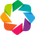

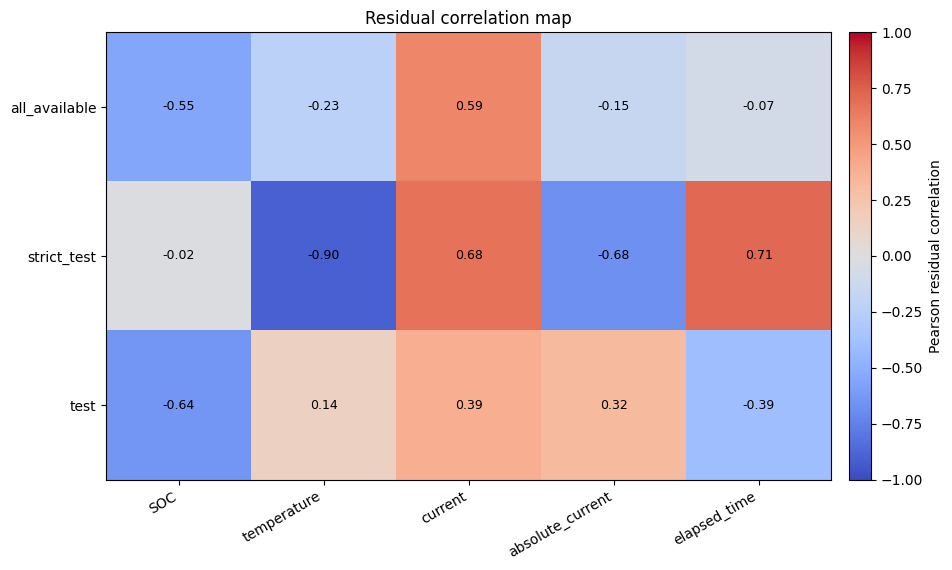

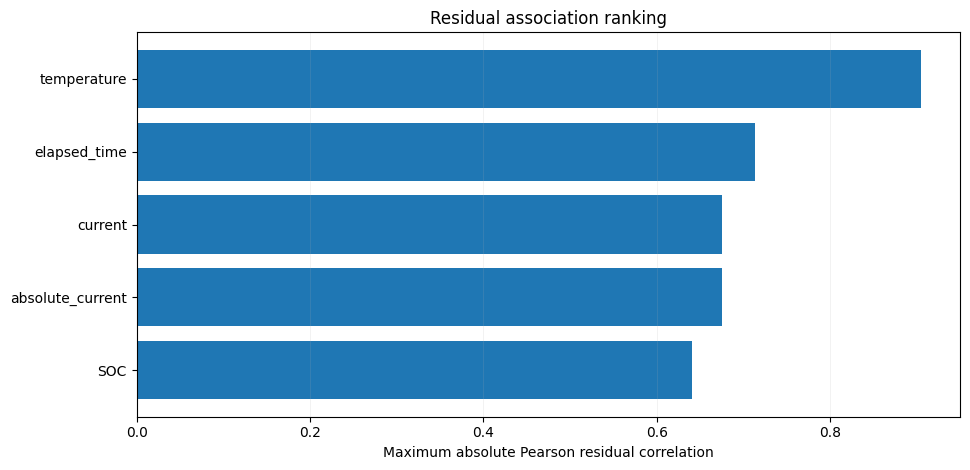

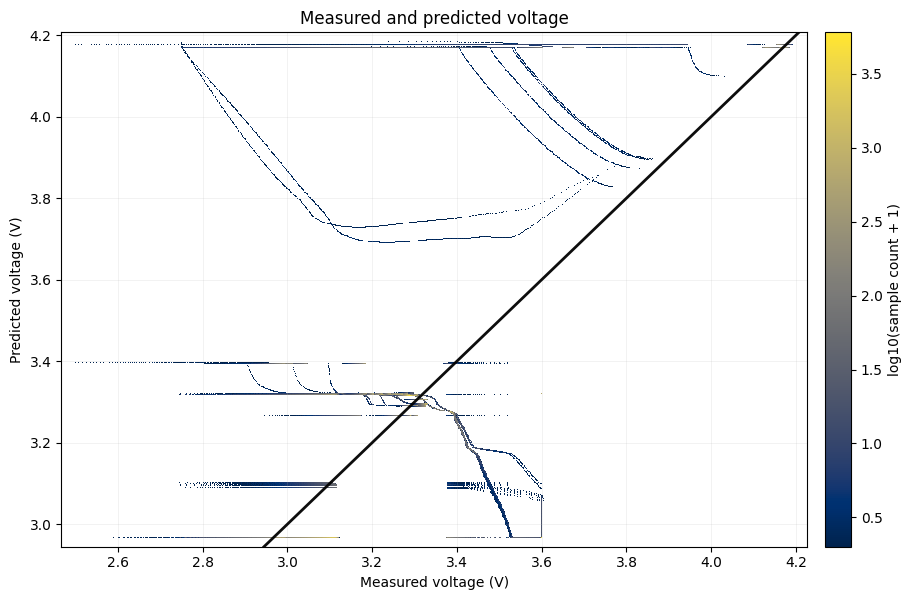

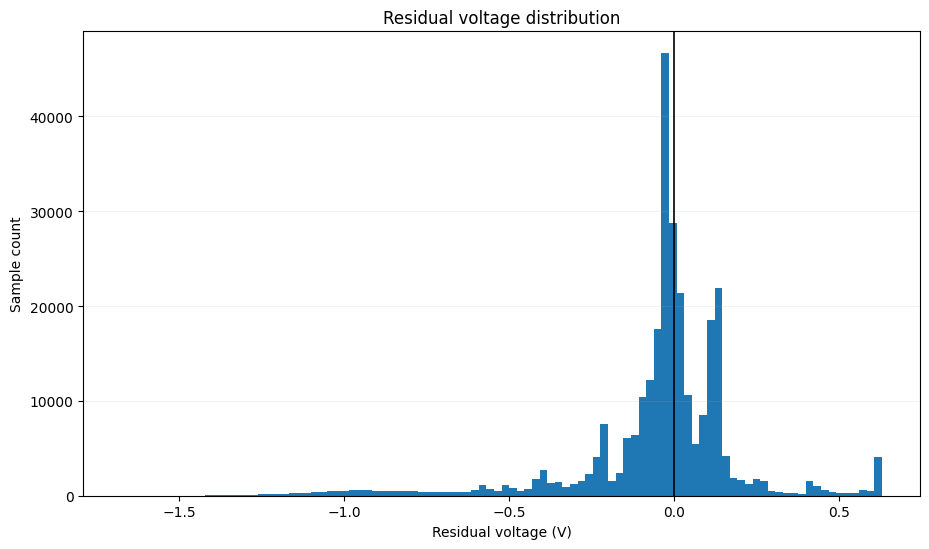

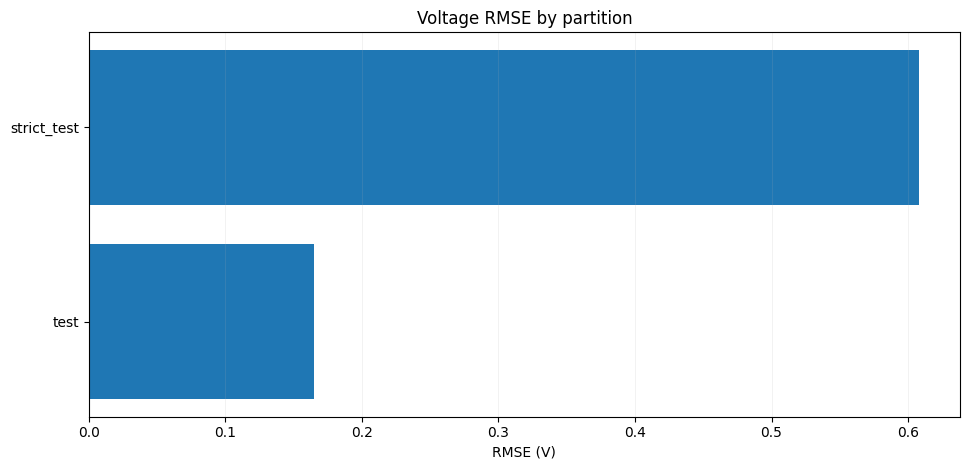

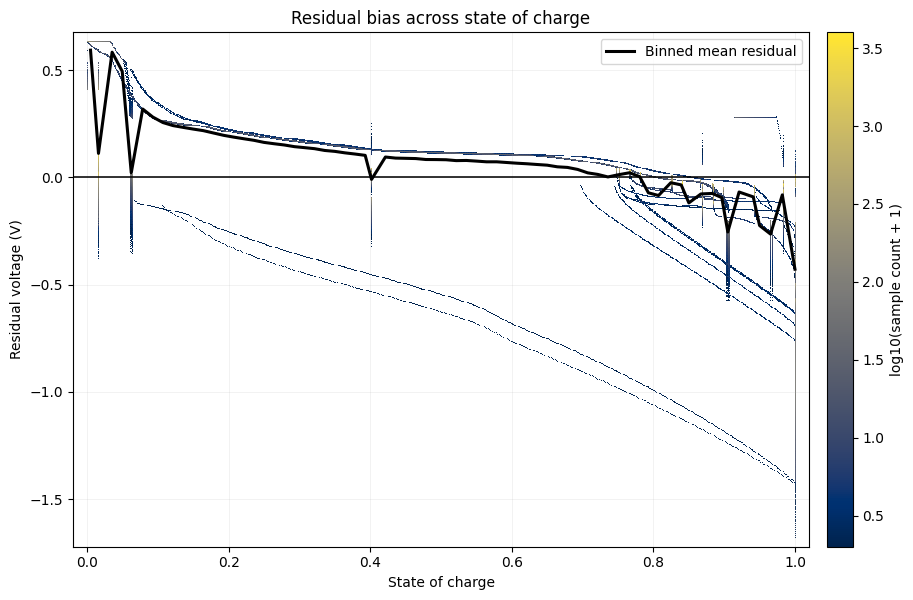

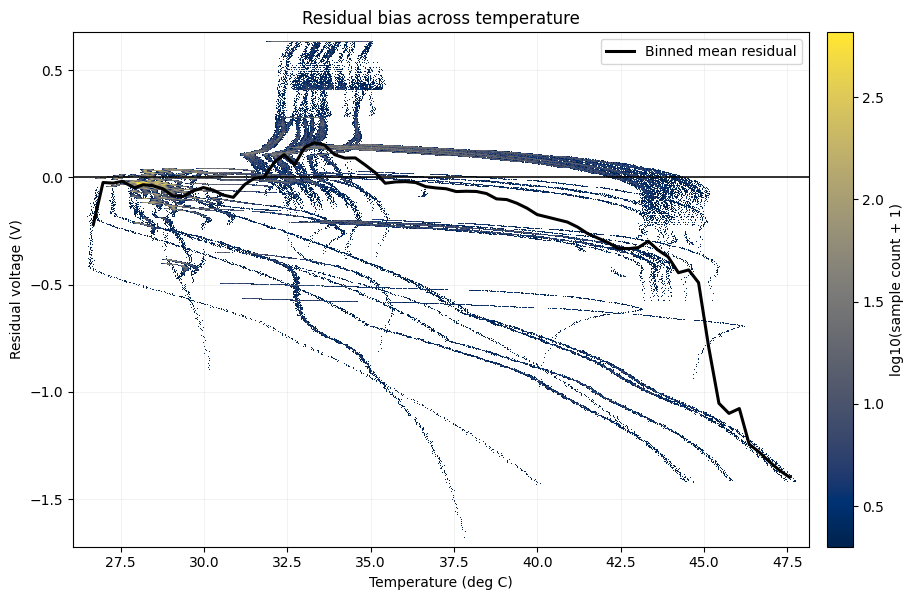

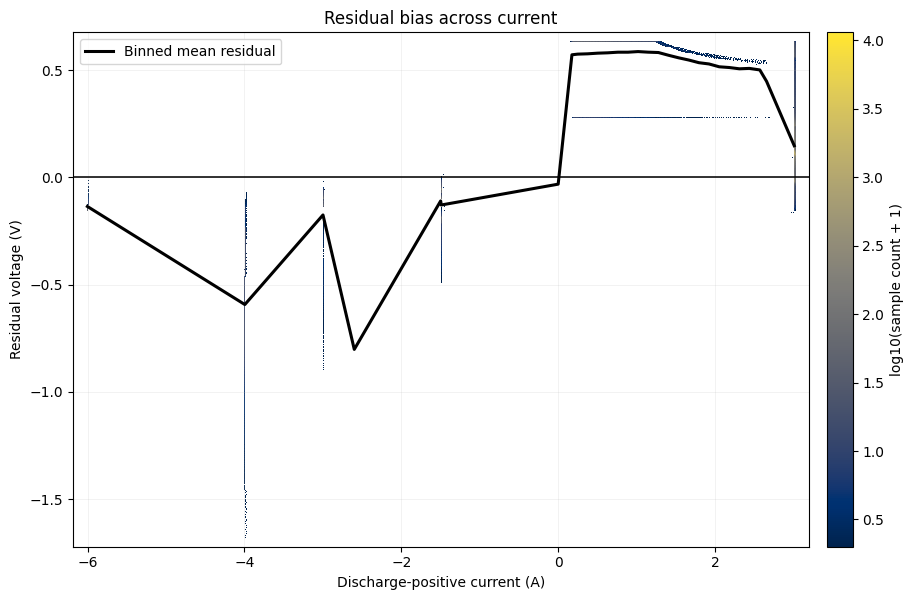

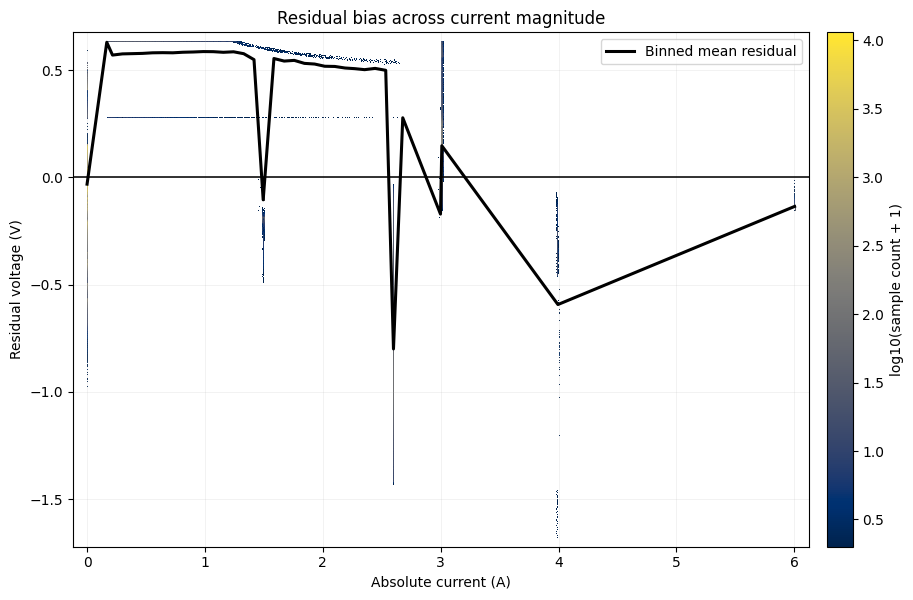

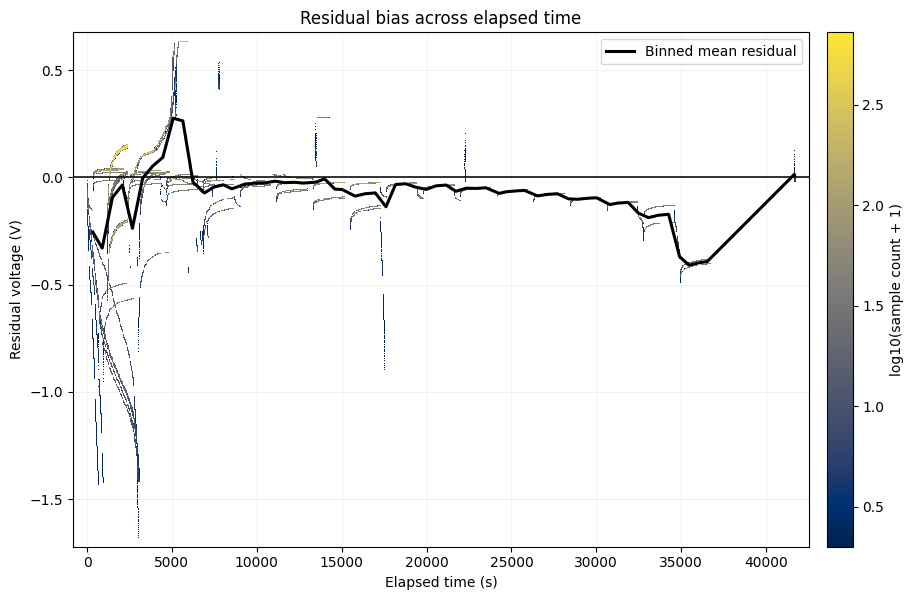

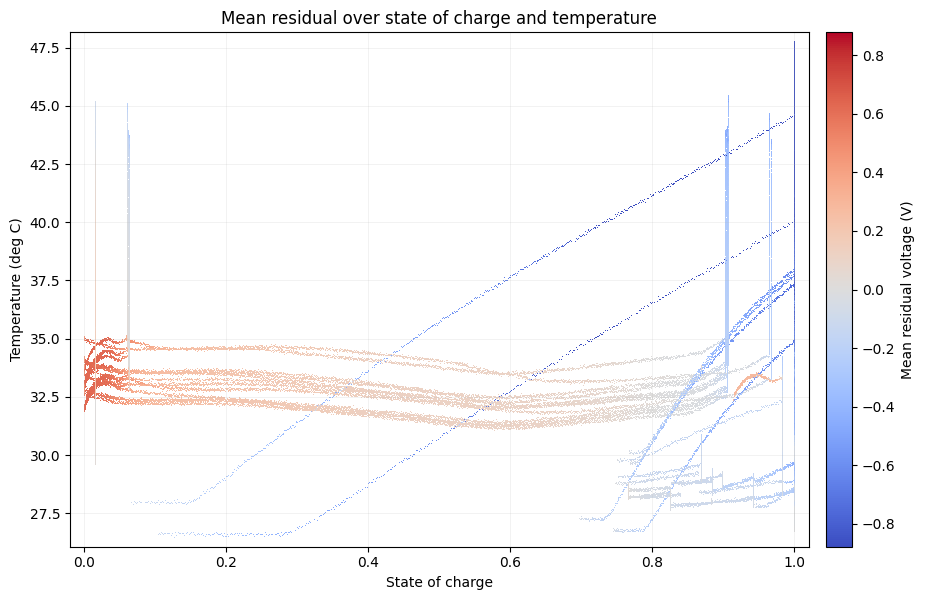

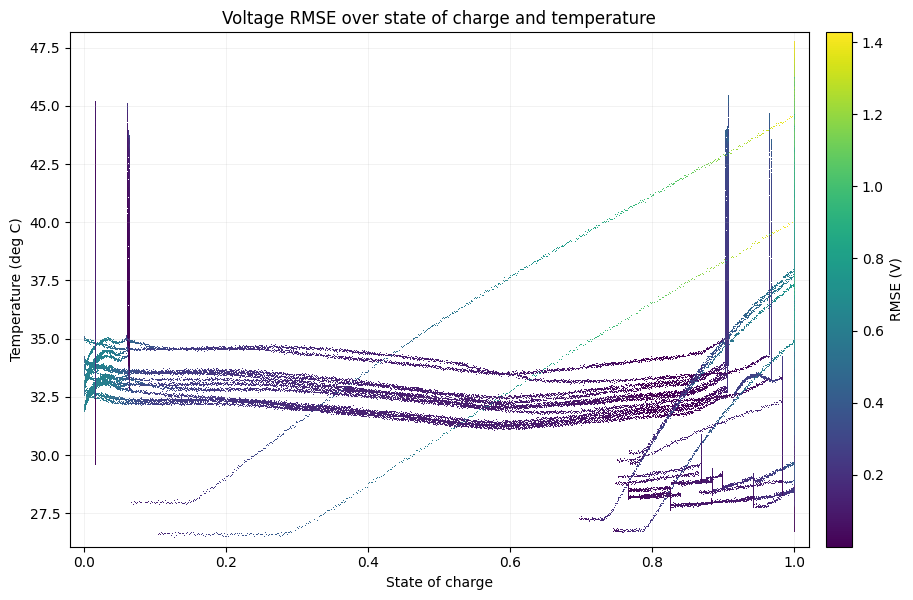

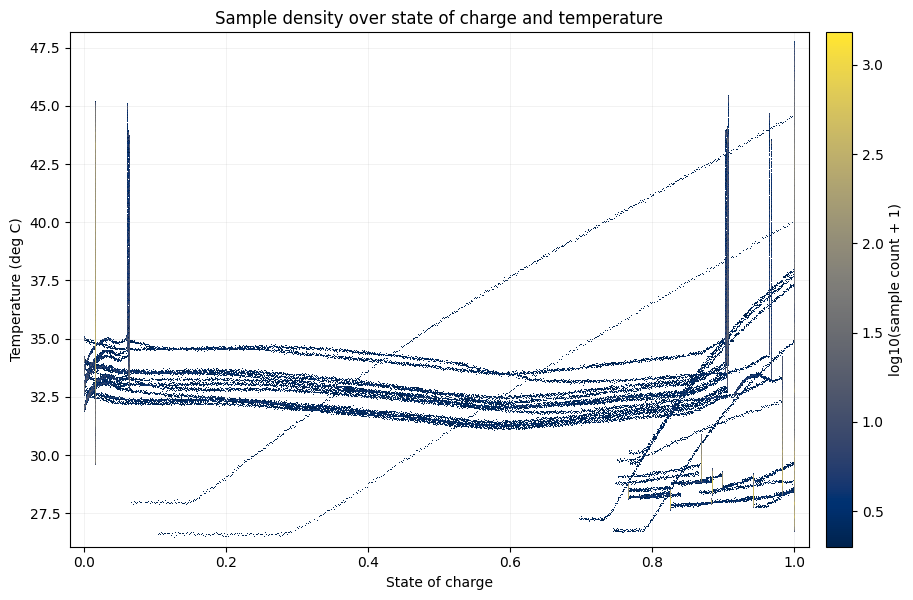

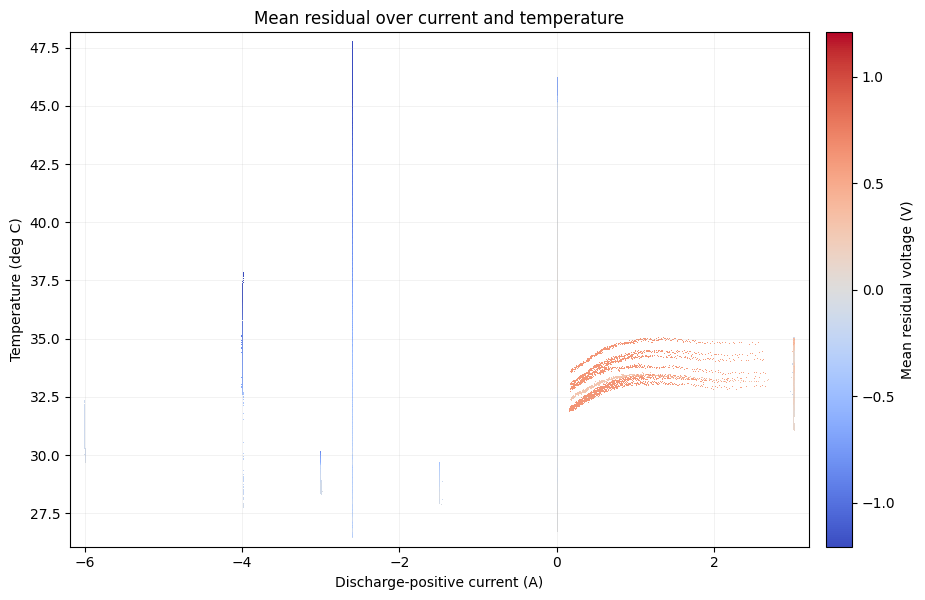

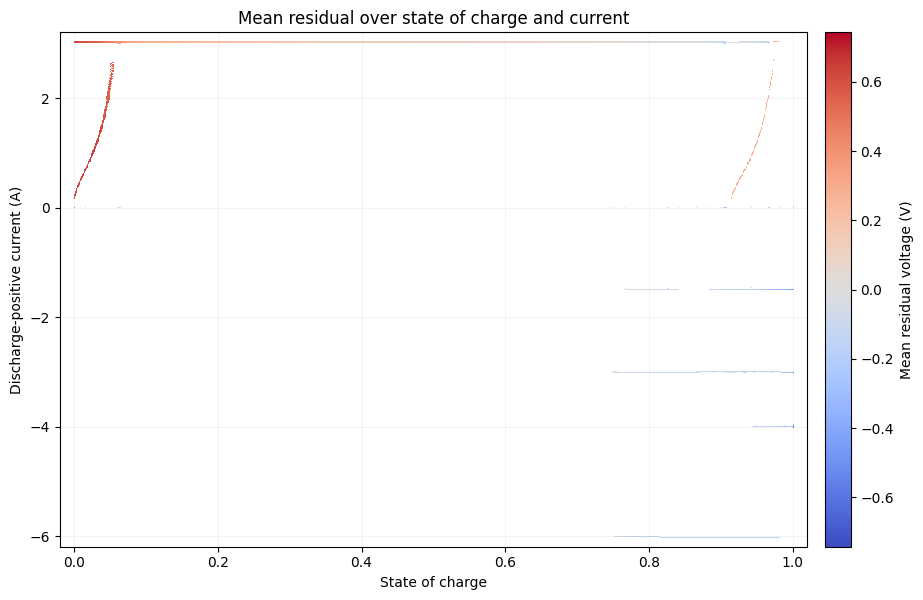

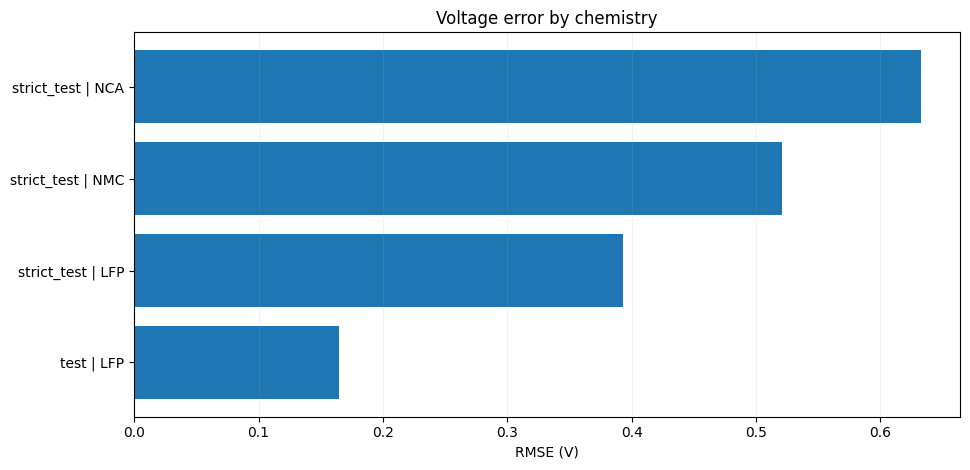

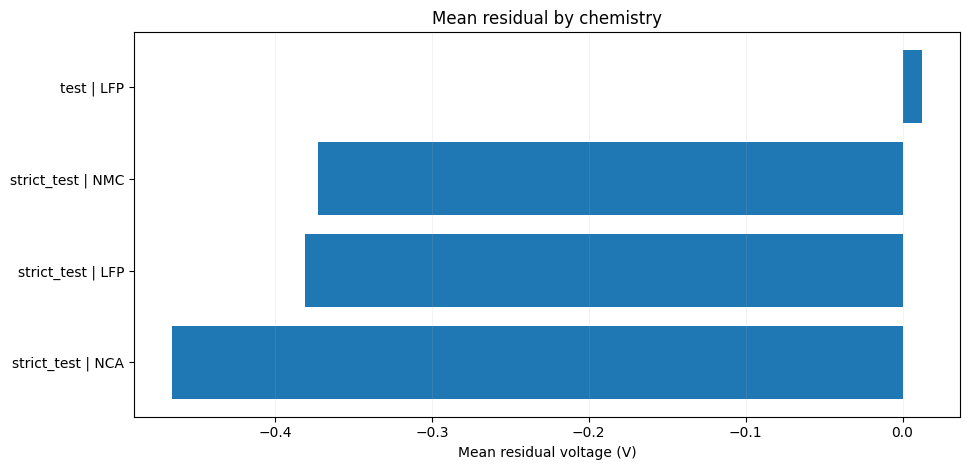

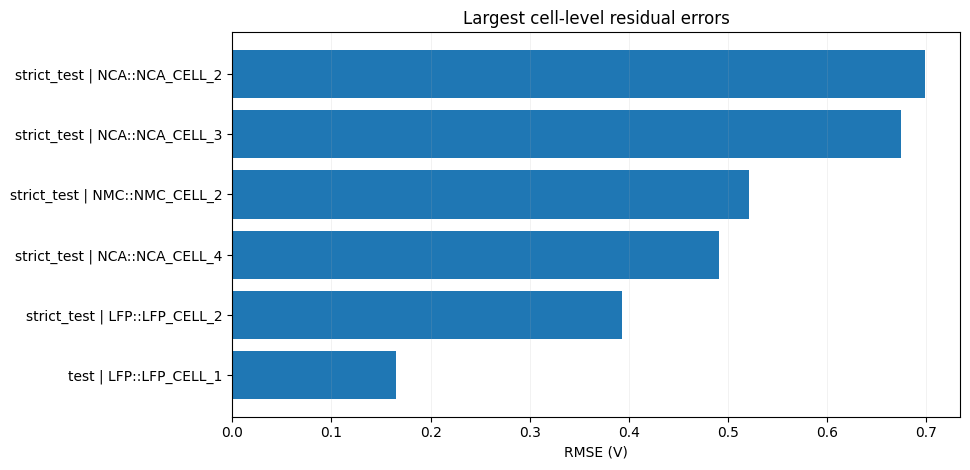

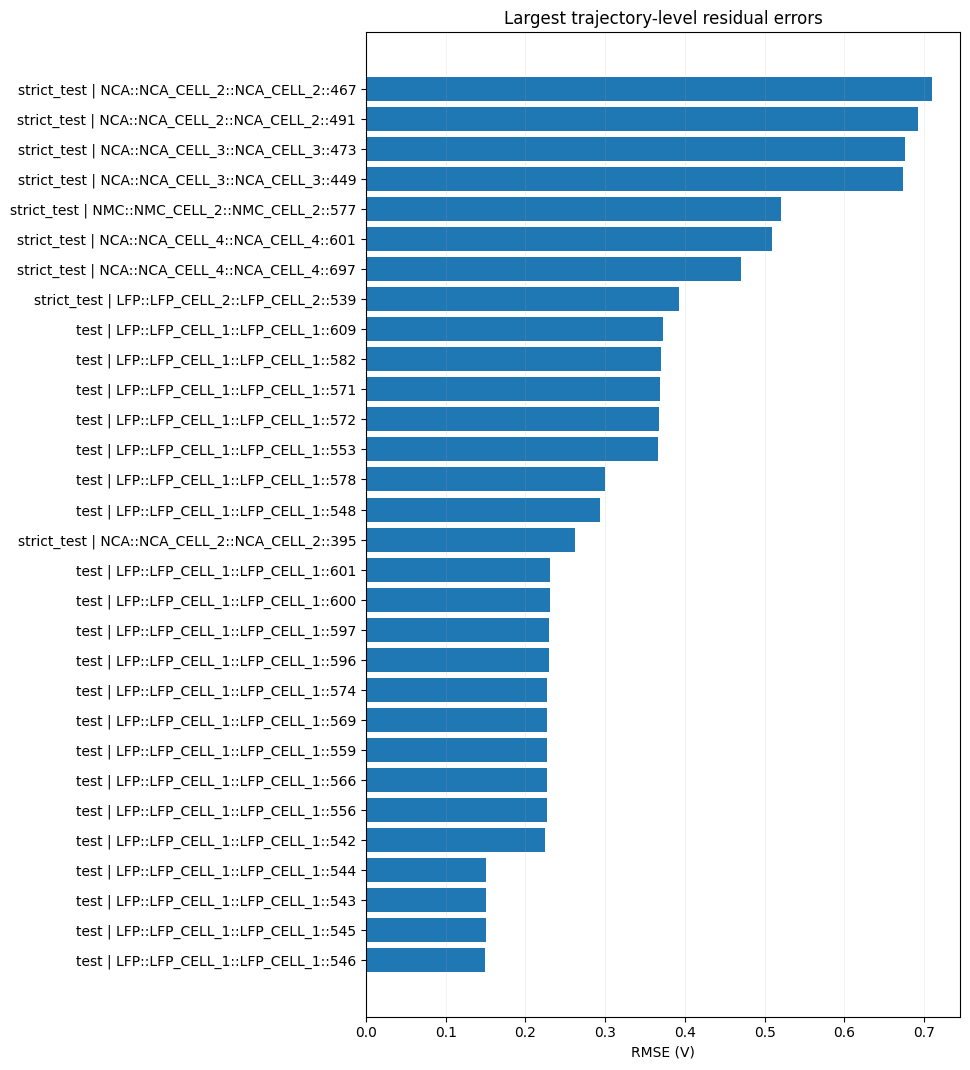

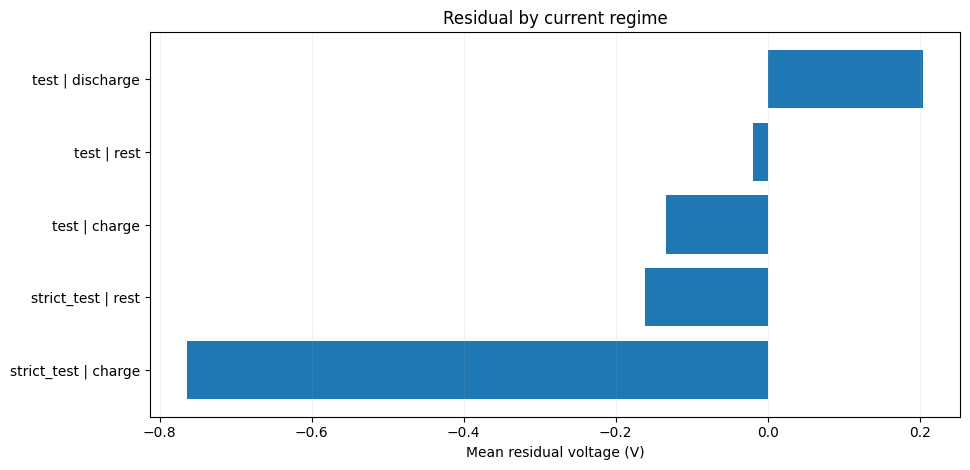

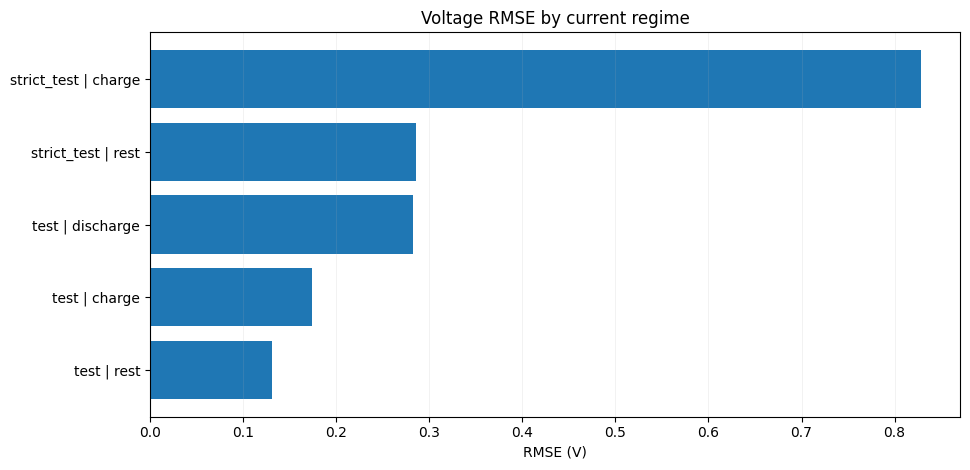

ADVANCED DIAGNOSTIC FIGURES SAVED
Project root                     : /home/xzkhu/Downloads/batter_lpv_project
Figure source rows               : 285,251
Static PNG directory             : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/static_png
Static PDF directory             : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/static_pdf
Interactive HTML directory       : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/interactive_html
Advanced table directory         : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/tables
Figure manifest                  : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/tables/notebook_13_advanced_figure_manifest.csv
Correlation map table            : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/figures_advanced/tables/notebook_13_residual_corre

,package,available
0,datashader,True
1,colorcet,True
2,holoviews,True
3,hvplot,True
4,bokeh,True


,rank,predictor,maximum_absolute_correlation,dominant_partition,interpretation,notebook_14_or_later_action
0,1,temperature,0.904732,strict_test,thermal voltage bias or temperature-transfer f...,Notebook 14 SOC-temperature voltage-bias corre...
1,2,elapsed_time,0.713053,strict_test,"trajectory drift, aging proxy, relaxation, or ...",Notebook 16/17 time-drift or aging audit
2,3,current,0.675903,strict_test,ohmic/polarization or current-direction mismatch,Notebook 15/16 current-direction or hysteresis...
3,4,absolute_current,0.675903,strict_test,current-amplitude-dependent polarization error,Notebook 15/16 regime-aware polarization exten...
4,5,SOC,0.640957,test,OCV/SOC voltage bias or SOC-dependent residual...,Notebook 14 voltage-bias correction


,figure,title,description,package,png_path,pdf_path,html_path,sample_count_used
0,residual_correlation_map,Residual correlation map,Signed Pearson correlation between residual vo...,matplotlib,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,,285251
1,residual_association_ranking,Residual association ranking,Operating variables ranked by maximum absolute...,matplotlib,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,,285251
2,measured_and_predicted_voltage_density,Measured and predicted voltage,Large-scale clear-background density view of m...,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251
3,residual_voltage_distribution,Residual voltage distribution,Distribution of frozen-model residual voltage.,matplotlib,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,,285251
4,voltage_rmse_by_partition,Voltage RMSE by partition,Frozen-model voltage RMSE by evaluation partit...,matplotlib,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,,285251
5,residual_bias_across_state_of_charge,Residual bias across state of charge,Residual voltage density over SOC with binned ...,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251
6,residual_bias_across_temperature,Residual bias across temperature,Residual voltage density over temperature with...,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251
7,residual_bias_across_current,Residual bias across current,Residual voltage density over discharge-positi...,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251
8,residual_bias_across_current_magnitude,Residual bias across current magnitude,Residual voltage density over absolute current...,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251
9,residual_bias_across_elapsed_time,Residual bias across elapsed time,Residual voltage density over elapsed time.,datashader_clear_background,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...,285251


In [30]:
# ======================================================================================
# CELL 16 — ADVANCED LARGE-SCALE DIAGNOSTIC FIGURES WITH CLEAR BACKGROUND
# ======================================================================================
# Mathematical role
# -----------------
# Notebook 13 visualizes the frozen Notebook 12 residual:
#
#     e_k = V_k - Vhat_k,
#
# where
#
#     V_k    = measured_voltage_v,
#     Vhat_k = predicted_voltage_v.
#
# The goal is to diagnose whether the frozen Notebook 12 selected model has systematic
# residual structure with respect to:
#
#     SOC_k,
#     T_k,
#     I_k,
#     |I_k|,
#     elapsed time.
#
# The main visual problem fixed here is that ordinary datashader count maps can color
# empty pixels as the darkest colormap value. That makes the background look dark and
# visually confusing. This cell masks zero-count pixels so empty areas remain white.
#
# This cell creates:
#
#   1. measured-vs-predicted voltage density;
#   2. residual-voltage distribution;
#   3. RMSE by partition;
#   4. residual density against SOC, temperature, current, current magnitude, time;
#   5. residual correlation heatmap;
#   6. residual association ranking;
#   7. SOC-temperature mean residual, RMSE, and sample-density maps;
#   8. current-temperature and SOC-current residual maps;
#   9. chemistry, cell, trajectory, and current-regime diagnostics.
#
# Figure-title rule
# -----------------
# Titles contain only the substantive title. They do not include "Notebook 13",
# "Figure", figure numbers, or similar prefixes.
# ======================================================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ======================================================================================
# 1. OPTIONAL ADVANCED PACKAGE IMPORTS
# ======================================================================================

ADVANCED_PACKAGE_STATUS = {}

try:
    import datashader as ds
    ADVANCED_PACKAGE_STATUS["datashader"] = True
except Exception as exc:
    ds = None
    ADVANCED_PACKAGE_STATUS["datashader"] = False
    print(f"datashader unavailable; matplotlib fallback will be used. Reason: {exc}")

try:
    import colorcet as cc
    ADVANCED_PACKAGE_STATUS["colorcet"] = True
except Exception as exc:
    cc = None
    ADVANCED_PACKAGE_STATUS["colorcet"] = False
    print(f"colorcet unavailable; matplotlib colormaps will be used. Reason: {exc}")

try:
    import holoviews as hv
    hv.extension("bokeh")
    ADVANCED_PACKAGE_STATUS["holoviews"] = True
except Exception as exc:
    hv = None
    ADVANCED_PACKAGE_STATUS["holoviews"] = False
    print(f"holoviews unavailable; interactive HTML plots will be skipped. Reason: {exc}")

try:
    import hvplot.pandas  # noqa: F401
    ADVANCED_PACKAGE_STATUS["hvplot"] = True
except Exception as exc:
    ADVANCED_PACKAGE_STATUS["hvplot"] = False
    print(f"hvplot unavailable; interactive HTML plots will be skipped. Reason: {exc}")

try:
    import bokeh  # noqa: F401
    ADVANCED_PACKAGE_STATUS["bokeh"] = True
except Exception as exc:
    ADVANCED_PACKAGE_STATUS["bokeh"] = False
    print(f"bokeh unavailable; interactive HTML plots will be skipped. Reason: {exc}")


# ======================================================================================
# 2. DEFAULTS AND INPUT VALIDATION
# ======================================================================================

if "RANDOM_SEED" not in globals():
    RANDOM_SEED = 20260703

if "ADVANCED_FIGURE_SAMPLE_ROWS" not in globals():
    ADVANCED_FIGURE_SAMPLE_ROWS = 350_000

if "FIGURE_SAMPLE_ROWS" not in globals():
    FIGURE_SAMPLE_ROWS = ADVANCED_FIGURE_SAMPLE_ROWS

ADVANCED_FIGURE_SAMPLE_ROWS = int(ADVANCED_FIGURE_SAMPLE_ROWS)

if ADVANCED_FIGURE_SAMPLE_ROWS <= 0:
    raise ValueError("ADVANCED_FIGURE_SAMPLE_ROWS must be positive.")

if "NOTEBOOK_13_EVALUATION_DF" not in globals():
    raise RuntimeError(
        "NOTEBOOK_13_EVALUATION_DF is not defined. "
        "Run Notebook 13 Cell 6 before running Cell 16."
    )

if not isinstance(NOTEBOOK_13_EVALUATION_DF, pd.DataFrame):
    raise TypeError("NOTEBOOK_13_EVALUATION_DF must be a pandas DataFrame.")

if len(NOTEBOOK_13_EVALUATION_DF) == 0:
    raise RuntimeError("NOTEBOOK_13_EVALUATION_DF is empty.")


# ======================================================================================
# 3. PROJECT ROOT AND OUTPUT DIRECTORIES
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the verified project root used by Notebooks 10, 11, and 12.

    Preferred root:

        /home/xzkhu/Downloads/batter_lpv_project
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate_root = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate_root.exists():
            return candidate_root

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_ROOT_DIR = PROJECT_ROOT / "data" / "processed" / "notebook_13"

NOTEBOOK_13_ADVANCED_FIGURE_DIR = NOTEBOOK_13_ROOT_DIR / "figures_advanced"
NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "static_png"
NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "static_pdf"
NOTEBOOK_13_ADVANCED_HTML_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "interactive_html"
NOTEBOOK_13_ADVANCED_TABLE_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "tables"

for directory in [
    NOTEBOOK_13_ADVANCED_FIGURE_DIR,
    NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR,
    NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR,
    NOTEBOOK_13_ADVANCED_HTML_DIR,
    NOTEBOOK_13_ADVANCED_TABLE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if "NOTEBOOK_13_TABLE_DIR" not in globals():
    NOTEBOOK_13_TABLE_DIR = NOTEBOOK_13_ROOT_DIR / "tables"
    NOTEBOOK_13_TABLE_DIR.mkdir(parents=True, exist_ok=True)

if "NOTEBOOK_13_MANIFEST_DIR" not in globals():
    NOTEBOOK_13_MANIFEST_DIR = NOTEBOOK_13_ROOT_DIR / "manifests"
    NOTEBOOK_13_MANIFEST_DIR.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 4. GENERAL HELPERS
# ======================================================================================

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def make_json_safe(value):
    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    return value


def atomic_write_json(path: Path, payload: dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(
            make_json_safe(payload),
            file,
            indent=2,
            sort_keys=True,
        )

    temporary_path.replace(path)


def resolve_column(
    dataframe: pd.DataFrame,
    candidate_names: tuple[str, ...],
    semantic_name: str,
    required: bool = False,
) -> str | None:
    """
    Resolve one dataframe column from possible names.
    """
    for candidate_name in candidate_names:
        if candidate_name in dataframe.columns:
            return candidate_name

    if required:
        raise RuntimeError(
            f"Could not find required column for {semantic_name}.\n"
            f"Candidate names checked: {candidate_names}\n"
            f"Available columns: {list(dataframe.columns)}"
        )

    return None


def safe_pearson(x_values: np.ndarray, y_values: np.ndarray) -> float:
    """
    Pearson residual correlation:

        rho(e, x) = cov(e, x) / (std(e) std(x)).
    """
    x_values = np.asarray(x_values, dtype=np.float64)
    y_values = np.asarray(y_values, dtype=np.float64)

    finite_mask = np.isfinite(x_values) & np.isfinite(y_values)

    if np.sum(finite_mask) < 3:
        return np.nan

    x = x_values[finite_mask]
    y = y_values[finite_mask]

    if np.std(x) <= 0.0 or np.std(y) <= 0.0:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def safe_spearman(x_values: np.ndarray, y_values: np.ndarray) -> float:
    """
    Spearman residual correlation. This detects monotone nonlinear association.
    """
    x_series = pd.Series(np.asarray(x_values, dtype=np.float64))
    y_series = pd.Series(np.asarray(y_values, dtype=np.float64))

    finite_mask = np.isfinite(x_series.to_numpy()) & np.isfinite(y_series.to_numpy())

    if int(np.sum(finite_mask)) < 3:
        return np.nan

    x = x_series.loc[finite_mask]
    y = y_series.loc[finite_mask]

    if x.nunique(dropna=True) <= 1 or y.nunique(dropna=True) <= 1:
        return np.nan

    return float(x.corr(y, method="spearman"))


def finite_numeric_array(dataframe: pd.DataFrame, column: str) -> np.ndarray:
    values = pd.to_numeric(
        dataframe[column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    return values[np.isfinite(values)]


def safe_metric_summary(group_df: pd.DataFrame, residual_column: str) -> dict[str, float | int]:
    """
    Residual metrics for one group:

        bias = mean(e_k),
        RMSE = sqrt(mean(e_k^2)),
        MAE  = mean(|e_k|).
    """
    residual = pd.to_numeric(
        group_df[residual_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    residual = residual[np.isfinite(residual)]

    if residual.size == 0:
        return {
            "sample_count": 0,
            "mean_residual_v": np.nan,
            "pooled_rmse_v": np.nan,
            "mae_v": np.nan,
            "p95_abs_residual_v": np.nan,
            "maximum_abs_residual_v": np.nan,
        }

    abs_residual = np.abs(residual)

    return {
        "sample_count": int(residual.size),
        "mean_residual_v": float(np.mean(residual)),
        "pooled_rmse_v": float(np.sqrt(np.mean(residual**2))),
        "mae_v": float(np.mean(abs_residual)),
        "p95_abs_residual_v": float(np.quantile(abs_residual, 0.95)),
        "maximum_abs_residual_v": float(np.max(abs_residual)),
    }


# ======================================================================================
# 5. RESOLVE COLUMNS
# ======================================================================================

partition_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("partition", "split", "primary_split"),
    "partition",
    required=False,
)

residual_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("residual_v", "voltage_residual_v", "prediction_error_v"),
    "voltage residual",
    required=True,
)

measured_voltage_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("measured_voltage_v", "voltage_v", "Voltage"),
    "measured voltage",
    required=False,
)

predicted_voltage_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("predicted_voltage_v", "voltage_prediction_v", "predicted_v"),
    "predicted voltage",
    required=False,
)

soc_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("soc_for_ocv", "soc", "SOC", "state_of_charge"),
    "SOC",
    required=False,
)

temperature_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("temperature_c", "temperature", "Temperature", "cell_temperature_c"),
    "temperature",
    required=False,
)

current_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("current_discharge_a", "current_a", "Current"),
    "discharge-positive current",
    required=False,
)

elapsed_time_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("elapsed_time_s", "time_s", "time", "Time"),
    "elapsed time",
    required=False,
)

chemistry_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("chemistry", "chemistry_name", "cell_chemistry"),
    "chemistry",
    required=False,
)

cell_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("cell_entity_id", "cell_id", "cell", "cell_name"),
    "cell identity",
    required=False,
)

trajectory_column = resolve_column(
    NOTEBOOK_13_EVALUATION_DF,
    ("trajectory_uid", "trajectory_id", "trajectory_key"),
    "trajectory identity",
    required=False,
)


# ======================================================================================
# 6. MEMORY-SAFE FIGURE DATAFRAME
# ======================================================================================

figure_df = NOTEBOOK_13_EVALUATION_DF.copy()

figure_df[residual_column] = pd.to_numeric(
    figure_df[residual_column],
    errors="coerce",
)

figure_df = figure_df.loc[
    np.isfinite(figure_df[residual_column].to_numpy(dtype=np.float64))
].copy()

if len(figure_df) == 0:
    raise RuntimeError("No finite residual values are available for plotting.")

if len(figure_df) > ADVANCED_FIGURE_SAMPLE_ROWS:
    figure_df = figure_df.sample(
        n=ADVANCED_FIGURE_SAMPLE_ROWS,
        random_state=RANDOM_SEED,
    ).copy()

if partition_column is None:
    figure_df["partition"] = "all_available"
    partition_column = "partition"
else:
    figure_df[partition_column] = figure_df[partition_column].astype(str)

for numeric_column in [
    measured_voltage_column,
    predicted_voltage_column,
    soc_column,
    temperature_column,
    current_column,
    elapsed_time_column,
]:
    if numeric_column is not None and numeric_column in figure_df.columns:
        figure_df[numeric_column] = pd.to_numeric(
            figure_df[numeric_column],
            errors="coerce",
        )

if current_column is not None:
    figure_df["abs_current_a"] = figure_df[current_column].abs()
else:
    figure_df["abs_current_a"] = np.nan


# ======================================================================================
# 7. FIGURE SAVE HELPERS
# ======================================================================================

figure_records: list[dict[str, object]] = []


def save_matplotlib_figure(
    filename_stem: str,
    title: str,
    description: str,
    package: str,
    html_path: Path | None = None,
) -> tuple[Path, Path]:
    """
    Save current matplotlib figure as PNG and PDF.
    """
    png_path = NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR / f"{filename_stem}.png"
    pdf_path = NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR / f"{filename_stem}.pdf"

    plt.tight_layout()
    plt.savefig(png_path, dpi=320, bbox_inches="tight", facecolor="white")
    plt.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    figure_records.append(
        {
            "figure": filename_stem,
            "title": title,
            "description": description,
            "package": package,
            "png_path": str(png_path),
            "pdf_path": str(pdf_path),
            "html_path": str(html_path) if html_path is not None else "",
            "sample_count_used": int(len(figure_df)),
        }
    )

    return png_path, pdf_path


def save_hvplot_html(
    dataframe: pd.DataFrame,
    x_column: str,
    y_column: str,
    title: str,
    filename_stem: str,
    x_label: str,
    y_label: str,
) -> Path | None:
    """
    Save optional interactive datashaded HTML using hvplot/holoviews.
    """
    if not (
        ADVANCED_PACKAGE_STATUS.get("holoviews", False)
        and ADVANCED_PACKAGE_STATUS.get("hvplot", False)
        and ADVANCED_PACKAGE_STATUS.get("bokeh", False)
    ):
        return None

    try:
        html_path = NOTEBOOK_13_ADVANCED_HTML_DIR / f"{filename_stem}.html"

        plot_df = dataframe[[x_column, y_column, partition_column]].copy()
        plot_df[x_column] = pd.to_numeric(plot_df[x_column], errors="coerce")
        plot_df[y_column] = pd.to_numeric(plot_df[y_column], errors="coerce")
        plot_df = plot_df.dropna(subset=[x_column, y_column])

        if len(plot_df) == 0:
            return None

        hv_object = plot_df.hvplot.scatter(
            x=x_column,
            y=y_column,
            by=partition_column,
            datashade=True,
            width=980,
            height=580,
            xlabel=x_label,
            ylabel=y_label,
            title=title,
        )

        hv.save(hv_object, html_path)

        return html_path

    except Exception as exc:
        print(f"Interactive HTML skipped for '{title}'. Reason: {exc}")
        return None


# ======================================================================================
# 8. CLEAR-BACKGROUND DATASHADER HELPERS
# ======================================================================================

def finite_plot_frame(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Keep only finite numeric plotting rows.
    """
    selected_columns = []
    for column in columns:
        if column is not None and column in dataframe.columns and column not in selected_columns:
            selected_columns.append(column)

    plot_df = dataframe[selected_columns].copy()

    for column in selected_columns:
        if column == partition_column:
            continue
        plot_df[column] = pd.to_numeric(plot_df[column], errors="coerce")

    numeric_columns = [
        column
        for column in selected_columns
        if column != partition_column
    ]

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=numeric_columns)

    return plot_df


def expanded_range(values: np.ndarray, fraction: float = 0.02) -> tuple[float, float]:
    """
    Compute axis range with small padding.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return 0.0, 1.0

    lower = float(np.min(values))
    upper = float(np.max(values))

    if lower == upper:
        delta = max(abs(lower), 1.0) * fraction
        return lower - delta, upper + delta

    pad = (upper - lower) * fraction
    return lower - pad, upper + pad


def symmetric_limits(values: np.ndarray, quantile: float = 0.98) -> tuple[float, float]:
    """
    Symmetric color limits for signed residual maps.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return -1.0, 1.0

    limit = float(np.quantile(np.abs(values), quantile))

    if not np.isfinite(limit) or limit <= 0.0:
        limit = float(np.max(np.abs(values)))

    if not np.isfinite(limit) or limit <= 0.0:
        limit = 1.0

    return -limit, limit


def add_binned_mean_curve(
    axis,
    dataframe: pd.DataFrame,
    x_column: str,
    y_column: str,
    bins: int = 70,
) -> None:
    """
    Overlay binned mean residual curve.

    For bin B_j:

        mean_j = mean(e_k | x_k in B_j).
    """
    plot_df = finite_plot_frame(dataframe, [x_column, y_column])

    if len(plot_df) < bins:
        return

    try:
        plot_df["_bin"] = pd.cut(plot_df[x_column], bins=bins)

        bin_df = (
            plot_df
            .groupby("_bin", observed=True)
            .agg(
                x_mean=(x_column, "mean"),
                y_mean=(y_column, "mean"),
            )
            .dropna()
            .reset_index(drop=True)
        )

        if len(bin_df) > 1:
            axis.plot(
                bin_df["x_mean"],
                bin_df["y_mean"],
                linewidth=2.2,
                color="black",
                label="Binned mean residual",
                zorder=5,
            )
            axis.legend(loc="best")

    except Exception as exc:
        print(f"Binned mean overlay skipped for {x_column}. Reason: {exc}")


def plot_density_map(
    dataframe: pd.DataFrame,
    x_column: str,
    y_column: str,
    x_label: str,
    y_label: str,
    title: str,
    filename_stem: str,
    value_column: str | None = None,
    aggregation: str = "count",
    overlay_zero_line: bool = False,
    overlay_identity_line: bool = False,
    overlay_binned_mean: bool = False,
    description: str = "",
) -> None:
    """
    Create clear-background density or residual-surface figure.

    Critical visual correction:
    ---------------------------
    Empty datashader bins are masked as NaN and rendered as white, instead of being
    colored with the lowest colormap color.
    """
    html_path = save_hvplot_html(
        dataframe=dataframe,
        x_column=x_column,
        y_column=y_column,
        title=title,
        filename_stem=filename_stem,
        x_label=x_label,
        y_label=y_label,
    )

    if ds is not None:
        try:
            plot_columns = [x_column, y_column]
            if value_column is not None:
                plot_columns.append(value_column)

            plot_df = finite_plot_frame(dataframe, plot_columns)

            if len(plot_df) == 0:
                raise RuntimeError(f"No finite rows available for {x_column} versus {y_column}.")

            x_range = expanded_range(plot_df[x_column].to_numpy(dtype=np.float64))
            y_range = expanded_range(plot_df[y_column].to_numpy(dtype=np.float64))

            canvas = ds.Canvas(
                plot_width=950,
                plot_height=600,
                x_range=x_range,
                y_range=y_range,
            )

            colorbar_label = ""

            if aggregation == "count":
                aggregate = canvas.points(
                    plot_df,
                    x_column,
                    y_column,
                    agg=ds.count(),
                )

                raw_array = np.asarray(aggregate, dtype=np.float64)

                # Empty bins remain white.
                array = np.full_like(raw_array, np.nan, dtype=np.float64)
                positive_mask = raw_array > 0.0
                array[positive_mask] = np.log10(raw_array[positive_mask] + 1.0)

                colorbar_label = "log10(sample count + 1)"
                cmap_name = "cividis"
                vmin = None
                vmax = None

            elif aggregation == "mean":
                if value_column is None:
                    raise ValueError("value_column is required for mean aggregation.")

                aggregate = canvas.points(
                    plot_df,
                    x_column,
                    y_column,
                    agg=ds.mean(value_column),
                )

                array = np.asarray(aggregate, dtype=np.float64)
                array = np.where(np.isfinite(array), array, np.nan)

                colorbar_label = "Mean residual voltage (V)"
                cmap_name = "coolwarm"
                vmin, vmax = symmetric_limits(array)

            elif aggregation == "rmse":
                if value_column is None:
                    raise ValueError("value_column is required for RMSE aggregation.")

                temporary_column = "_notebook_13_residual_squared_for_rmse"
                plot_df = plot_df.copy()
                plot_df[temporary_column] = plot_df[value_column].to_numpy(dtype=np.float64) ** 2

                aggregate = canvas.points(
                    plot_df,
                    x_column,
                    y_column,
                    agg=ds.mean(temporary_column),
                )

                array = np.sqrt(np.asarray(aggregate, dtype=np.float64))
                array = np.where(np.isfinite(array), array, np.nan)

                colorbar_label = "RMSE (V)"
                cmap_name = "viridis"
                vmin = None
                vmax = None

            else:
                raise ValueError(f"Unsupported aggregation: {aggregation}")

            finite_array = array[np.isfinite(array)]

            if finite_array.size == 0:
                raise RuntimeError("No finite aggregated values available for plotting.")

            fig, axis = plt.subplots(figsize=(9.8, 6.1))

            fig.patch.set_facecolor("white")
            axis.set_facecolor("white")

            cmap = plt.get_cmap(cmap_name).copy()
            cmap.set_bad(color="white")

            image = axis.imshow(
                np.ma.masked_invalid(array),
                extent=[x_range[0], x_range[1], y_range[0], y_range[1]],
                origin="lower",
                aspect="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )

            colorbar = fig.colorbar(image, ax=axis, pad=0.02)
            colorbar.set_label(colorbar_label)

            axis.set_xlabel(x_label)
            axis.set_ylabel(y_label)
            axis.set_title(title)

            axis.grid(True, alpha=0.18, linewidth=0.6)

            if overlay_zero_line:
                axis.axhline(
                    0.0,
                    color="black",
                    linewidth=1.25,
                    alpha=0.9,
                    zorder=4,
                )

            if overlay_identity_line:
                lower = max(x_range[0], y_range[0])
                upper = min(x_range[1], y_range[1])

                if lower < upper:
                    axis.plot(
                        [lower, upper],
                        [lower, upper],
                        color="black",
                        linewidth=2.0,
                        alpha=0.95,
                        linestyle="-",
                        zorder=5,
                    )

            if overlay_binned_mean:
                add_binned_mean_curve(
                    axis=axis,
                    dataframe=plot_df,
                    x_column=x_column,
                    y_column=y_column,
                )

            save_matplotlib_figure(
                filename_stem=filename_stem,
                title=title,
                description=description,
                package="datashader_clear_background",
                html_path=html_path,
            )

            return

        except Exception as exc:
            print(
                f"Datashader plot failed for '{title}', "
                f"falling back to matplotlib. Reason: {exc}"
            )

    # ----------------------------------------------------------------------------------
    # Matplotlib fallback
    # ----------------------------------------------------------------------------------
    plot_columns = [x_column, y_column]
    if value_column is not None:
        plot_columns.append(value_column)

    plot_df = finite_plot_frame(dataframe, plot_columns)

    if len(plot_df) == 0:
        print(f"Skipping '{title}' because no finite plotting rows are available.")
        return

    fig, axis = plt.subplots(figsize=(9.8, 6.1))

    fig.patch.set_facecolor("white")
    axis.set_facecolor("white")

    if aggregation == "count":
        handle = axis.hexbin(
            plot_df[x_column],
            plot_df[y_column],
            gridsize=95,
            bins="log",
            cmap="cividis",
            mincnt=1,
        )

        colorbar = fig.colorbar(handle, ax=axis, pad=0.02)
        colorbar.set_label("log10(sample count)")

    else:
        if aggregation == "mean":
            reduce_func = np.mean
            colorbar_label = "Mean residual voltage (V)"
            cmap_name = "coolwarm"
        elif aggregation == "rmse":
            reduce_func = lambda values: np.sqrt(np.mean(np.square(values)))
            colorbar_label = "RMSE (V)"
            cmap_name = "viridis"
        else:
            reduce_func = np.mean
            colorbar_label = "Aggregated value"
            cmap_name = "viridis"

        handle = axis.hexbin(
            plot_df[x_column],
            plot_df[y_column],
            C=plot_df[value_column],
            gridsize=95,
            reduce_C_function=reduce_func,
            cmap=cmap_name,
            mincnt=1,
        )

        colorbar = fig.colorbar(handle, ax=axis, pad=0.02)
        colorbar.set_label(colorbar_label)

    axis.set_xlabel(x_label)
    axis.set_ylabel(y_label)
    axis.set_title(title)
    axis.grid(True, alpha=0.18, linewidth=0.6)

    if overlay_zero_line:
        axis.axhline(
            0.0,
            color="black",
            linewidth=1.25,
            alpha=0.9,
        )

    if overlay_identity_line:
        lower = float(min(plot_df[x_column].min(), plot_df[y_column].min()))
        upper = float(max(plot_df[x_column].max(), plot_df[y_column].max()))

        axis.plot(
            [lower, upper],
            [lower, upper],
            color="black",
            linewidth=2.0,
            alpha=0.95,
        )

    if overlay_binned_mean:
        add_binned_mean_curve(
            axis=axis,
            dataframe=plot_df,
            x_column=x_column,
            y_column=y_column,
        )

    save_matplotlib_figure(
        filename_stem=filename_stem,
        title=title,
        description=description,
        package="matplotlib_hexbin_clear_background",
        html_path=html_path,
    )


def plot_barh(
    dataframe: pd.DataFrame,
    label_column: str,
    value_column: str,
    xlabel: str,
    title: str,
    filename_stem: str,
    description: str,
    top_n: int | None = None,
    ascending: bool = True,
) -> None:
    """
    Horizontal bar chart for grouped diagnostics.
    """
    plot_df = dataframe.copy()

    if label_column not in plot_df.columns or value_column not in plot_df.columns:
        print(f"Skipping '{title}' because required columns are missing.")
        return

    plot_df[value_column] = pd.to_numeric(plot_df[value_column], errors="coerce")
    plot_df = plot_df.dropna(subset=[label_column, value_column])
    plot_df = plot_df.sort_values(value_column, ascending=ascending)

    if top_n is not None and len(plot_df) > top_n:
        if ascending:
            plot_df = plot_df.tail(top_n)
        else:
            plot_df = plot_df.head(top_n)

    if len(plot_df) == 0:
        print(f"Skipping '{title}' because no rows are available.")
        return

    fig_height = max(4.8, 0.32 * len(plot_df) + 1.2)

    fig, axis = plt.subplots(figsize=(9.8, fig_height))
    fig.patch.set_facecolor("white")
    axis.set_facecolor("white")

    axis.barh(plot_df[label_column].astype(str), plot_df[value_column])
    axis.set_xlabel(xlabel)
    axis.set_ylabel("")
    axis.set_title(title)
    axis.grid(True, axis="x", alpha=0.18, linewidth=0.6)

    save_matplotlib_figure(
        filename_stem=filename_stem,
        title=title,
        description=description,
        package="matplotlib",
        html_path=None,
    )


# ======================================================================================
# 9. CORRELATION MAP AND ASSOCIATION RANKING
# ======================================================================================

def build_residual_correlation_table() -> pd.DataFrame:
    """
    Build Pearson and Spearman residual correlations by partition and predictor.
    """
    predictor_specs = [
        {
            "predictor": "SOC",
            "column": soc_column,
            "interpretation": "OCV/SOC voltage bias or SOC-dependent residual structure",
            "action": "Notebook 14 voltage-bias correction",
        },
        {
            "predictor": "temperature",
            "column": temperature_column,
            "interpretation": "thermal voltage bias or temperature-transfer failure",
            "action": "Notebook 14 SOC-temperature voltage-bias correction",
        },
        {
            "predictor": "current",
            "column": current_column,
            "interpretation": "ohmic/polarization or current-direction mismatch",
            "action": "Notebook 15/16 current-direction or hysteresis extension",
        },
        {
            "predictor": "absolute_current",
            "column": "abs_current_a" if "abs_current_a" in figure_df.columns else None,
            "interpretation": "current-amplitude-dependent polarization error",
            "action": "Notebook 15/16 regime-aware polarization extension",
        },
        {
            "predictor": "elapsed_time",
            "column": elapsed_time_column,
            "interpretation": "trajectory drift, aging proxy, relaxation, or time-correlated bias",
            "action": "Notebook 16/17 time-drift or aging audit",
        },
    ]

    records = []

    group_items = list(
        figure_df.groupby(
            partition_column,
            sort=False,
            observed=True,
        )
    )

    group_items.append(("all_available", figure_df))

    for partition_value, group_df in group_items:
        residual_values = pd.to_numeric(
            group_df[residual_column],
            errors="coerce",
        ).to_numpy(dtype=np.float64)

        for spec in predictor_specs:
            column = spec["column"]

            if column is None or column not in group_df.columns:
                continue

            predictor_values = pd.to_numeric(
                group_df[column],
                errors="coerce",
            ).to_numpy(dtype=np.float64)

            pearson_value = safe_pearson(predictor_values, residual_values)
            spearman_value = safe_spearman(predictor_values, residual_values)

            records.append(
                {
                    "partition": str(partition_value),
                    "predictor": spec["predictor"],
                    "source_column": column,
                    "pearson": pearson_value,
                    "spearman": spearman_value,
                    "absolute_pearson": abs(pearson_value) if np.isfinite(pearson_value) else np.nan,
                    "absolute_spearman": abs(spearman_value) if np.isfinite(spearman_value) else np.nan,
                    "sample_count": int(
                        np.sum(
                            np.isfinite(predictor_values)
                            & np.isfinite(residual_values)
                        )
                    ),
                    "interpretation": spec["interpretation"],
                    "notebook_14_or_later_action": spec["action"],
                }
            )

    return pd.DataFrame(records)


NOTEBOOK_13_ADVANCED_CORRELATION_DF = build_residual_correlation_table()

NOTEBOOK_13_ADVANCED_CORRELATION_PATH = (
    NOTEBOOK_13_ADVANCED_TABLE_DIR
    / "notebook_13_residual_correlation_map.csv"
)

NOTEBOOK_13_ADVANCED_CORRELATION_DF.to_csv(
    NOTEBOOK_13_ADVANCED_CORRELATION_PATH,
    index=False,
)

NOTEBOOK_13_RESIDUAL_CORRELATION_DF = (
    NOTEBOOK_13_ADVANCED_CORRELATION_DF
    .rename(
        columns={
            "pearson": "pearson_residual_correlation",
            "absolute_pearson": "absolute_pearson_residual_correlation",
        }
    )
    .copy()
)


def plot_correlation_heatmap() -> None:
    heatmap_df = NOTEBOOK_13_ADVANCED_CORRELATION_DF.copy()

    if len(heatmap_df) == 0:
        print("Correlation heatmap skipped because the correlation table is empty.")
        return

    pivot_df = heatmap_df.pivot_table(
        index="partition",
        columns="predictor",
        values="pearson",
        aggfunc="mean",
    )

    preferred_columns = [
        "SOC",
        "temperature",
        "current",
        "absolute_current",
        "elapsed_time",
    ]

    available_columns = [
        column
        for column in preferred_columns
        if column in pivot_df.columns
    ]

    pivot_df = pivot_df[available_columns]

    fig, axis = plt.subplots(figsize=(10.0, 5.8))
    fig.patch.set_facecolor("white")
    axis.set_facecolor("white")

    image = axis.imshow(
        pivot_df.to_numpy(dtype=np.float64),
        aspect="auto",
        vmin=-1.0,
        vmax=1.0,
        cmap="coolwarm",
    )

    axis.set_xticks(np.arange(len(pivot_df.columns)))
    axis.set_xticklabels(pivot_df.columns, rotation=30, ha="right")
    axis.set_yticks(np.arange(len(pivot_df.index)))
    axis.set_yticklabels(pivot_df.index)
    axis.set_title("Residual correlation map")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            value = pivot_df.iloc[i, j]
            if np.isfinite(value):
                axis.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black",
                )

    colorbar = fig.colorbar(image, ax=axis, pad=0.02)
    colorbar.set_label("Pearson residual correlation")

    save_matplotlib_figure(
        filename_stem="residual_correlation_map",
        title="Residual correlation map",
        description="Signed Pearson correlation between residual voltage and operating variables.",
        package="matplotlib",
    )


plot_correlation_heatmap()


ranking_records = []

for predictor, group_df in NOTEBOOK_13_ADVANCED_CORRELATION_DF.groupby(
    "predictor",
    sort=False,
    observed=True,
):
    group_df = group_df.copy()
    group_df["absolute_pearson"] = pd.to_numeric(
        group_df["absolute_pearson"],
        errors="coerce",
    )

    finite_group = group_df.dropna(subset=["absolute_pearson"])

    if len(finite_group) == 0:
        continue

    row = finite_group.sort_values("absolute_pearson", ascending=False).iloc[0]

    ranking_records.append(
        {
            "predictor": predictor,
            "maximum_absolute_correlation": float(row["absolute_pearson"]),
            "dominant_partition": str(row["partition"]),
            "interpretation": str(row["interpretation"]),
            "notebook_14_or_later_action": str(row["notebook_14_or_later_action"]),
        }
    )

NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF = (
    pd.DataFrame(ranking_records)
    .sort_values("maximum_absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF.insert(
    0,
    "rank",
    np.arange(1, len(NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF) + 1),
)

NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_PATH = (
    NOTEBOOK_13_ADVANCED_TABLE_DIR
    / "notebook_13_residual_association_ranking.csv"
)

NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF.to_csv(
    NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_PATH,
    index=False,
)

plot_barh(
    dataframe=NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF.sort_values(
        "maximum_absolute_correlation",
        ascending=True,
    ),
    label_column="predictor",
    value_column="maximum_absolute_correlation",
    xlabel="Maximum absolute Pearson residual correlation",
    title="Residual association ranking",
    filename_stem="residual_association_ranking",
    description="Operating variables ranked by maximum absolute residual correlation.",
    ascending=True,
)


# ======================================================================================
# 10. FROZEN MODEL OVERVIEW FIGURES
# ======================================================================================

if measured_voltage_column is not None and predicted_voltage_column is not None:
    plot_density_map(
        dataframe=figure_df,
        x_column=measured_voltage_column,
        y_column=predicted_voltage_column,
        x_label="Measured voltage (V)",
        y_label="Predicted voltage (V)",
        title="Measured and predicted voltage",
        filename_stem="measured_and_predicted_voltage_density",
        aggregation="count",
        overlay_identity_line=True,
        description="Large-scale clear-background density view of measured voltage against predicted voltage.",
    )

residual_values = finite_numeric_array(figure_df, residual_column)

if residual_values.size > 0:
    fig, axis = plt.subplots(figsize=(9.4, 5.6))
    fig.patch.set_facecolor("white")
    axis.set_facecolor("white")

    axis.hist(residual_values, bins=100)
    axis.axvline(0.0, linewidth=1.2, color="black")
    axis.set_xlabel("Residual voltage (V)")
    axis.set_ylabel("Sample count")
    axis.set_title("Residual voltage distribution")
    axis.grid(True, axis="y", alpha=0.18, linewidth=0.6)

    save_matplotlib_figure(
        filename_stem="residual_voltage_distribution",
        title="Residual voltage distribution",
        description="Distribution of frozen-model residual voltage.",
        package="matplotlib",
    )

partition_rmse_records = []

for partition_value, group_df in figure_df.groupby(
    partition_column,
    sort=False,
    observed=True,
):
    summary = safe_metric_summary(group_df, residual_column)
    partition_rmse_records.append(
        {
            "partition": str(partition_value),
            **summary,
        }
    )

NOTEBOOK_13_PARTITION_RMSE_DF = pd.DataFrame(partition_rmse_records)
NOTEBOOK_13_PARTITION_RMSE_PATH = (
    NOTEBOOK_13_ADVANCED_TABLE_DIR
    / "notebook_13_partition_rmse_summary.csv"
)
NOTEBOOK_13_PARTITION_RMSE_DF.to_csv(NOTEBOOK_13_PARTITION_RMSE_PATH, index=False)

plot_barh(
    dataframe=NOTEBOOK_13_PARTITION_RMSE_DF.sort_values("pooled_rmse_v", ascending=True),
    label_column="partition",
    value_column="pooled_rmse_v",
    xlabel="RMSE (V)",
    title="Voltage RMSE by partition",
    filename_stem="voltage_rmse_by_partition",
    description="Frozen-model voltage RMSE by evaluation partition.",
    ascending=True,
)


# ======================================================================================
# 11. ONE-DIMENSIONAL RESIDUAL STRUCTURE FIGURES
# ======================================================================================

if soc_column is not None:
    plot_density_map(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=residual_column,
        x_label="State of charge",
        y_label="Residual voltage (V)",
        title="Residual bias across state of charge",
        filename_stem="residual_bias_across_state_of_charge",
        aggregation="count",
        overlay_zero_line=True,
        overlay_binned_mean=True,
        description="Residual voltage density over SOC with binned mean residual overlay.",
    )

if temperature_column is not None:
    plot_density_map(
        dataframe=figure_df,
        x_column=temperature_column,
        y_column=residual_column,
        x_label="Temperature (deg C)",
        y_label="Residual voltage (V)",
        title="Residual bias across temperature",
        filename_stem="residual_bias_across_temperature",
        aggregation="count",
        overlay_zero_line=True,
        overlay_binned_mean=True,
        description="Residual voltage density over temperature with binned mean residual overlay.",
    )

if current_column is not None:
    plot_density_map(
        dataframe=figure_df,
        x_column=current_column,
        y_column=residual_column,
        x_label="Discharge-positive current (A)",
        y_label="Residual voltage (V)",
        title="Residual bias across current",
        filename_stem="residual_bias_across_current",
        aggregation="count",
        overlay_zero_line=True,
        overlay_binned_mean=True,
        description="Residual voltage density over discharge-positive current.",
    )

if "abs_current_a" in figure_df.columns and np.isfinite(figure_df["abs_current_a"]).any():
    plot_density_map(
        dataframe=figure_df,
        x_column="abs_current_a",
        y_column=residual_column,
        x_label="Absolute current (A)",
        y_label="Residual voltage (V)",
        title="Residual bias across current magnitude",
        filename_stem="residual_bias_across_current_magnitude",
        aggregation="count",
        overlay_zero_line=True,
        overlay_binned_mean=True,
        description="Residual voltage density over absolute current magnitude.",
    )

if elapsed_time_column is not None:
    plot_density_map(
        dataframe=figure_df,
        x_column=elapsed_time_column,
        y_column=residual_column,
        x_label="Elapsed time (s)",
        y_label="Residual voltage (V)",
        title="Residual bias across elapsed time",
        filename_stem="residual_bias_across_elapsed_time",
        aggregation="count",
        overlay_zero_line=True,
        overlay_binned_mean=True,
        description="Residual voltage density over elapsed time.",
    )


# ======================================================================================
# 12. TWO-DIMENSIONAL RESIDUAL SURFACES
# ======================================================================================

def make_binned_surface_table(
    dataframe: pd.DataFrame,
    x_column: str,
    y_column: str,
    x_name: str,
    y_name: str,
    filename_stem: str,
    bins: int = 40,
) -> pd.DataFrame:
    """
    Export binned residual surface table.

    For each bin pair B_ij:

        mean_residual = mean(e_k in B_ij),
        RMSE          = sqrt(mean(e_k^2 in B_ij)),
        sample_count  = |B_ij|.
    """
    plot_df = finite_plot_frame(
        dataframe,
        [partition_column, x_column, y_column, residual_column],
    )

    records = []

    for partition_value, group_df in plot_df.groupby(
        partition_column,
        sort=False,
        observed=True,
    ):
        if len(group_df) < 5:
            continue

        group_df = group_df.copy()
        group_df["_x_bin"] = pd.cut(group_df[x_column], bins=bins)
        group_df["_y_bin"] = pd.cut(group_df[y_column], bins=bins)

        grouped = group_df.groupby(
            ["_x_bin", "_y_bin"],
            observed=True,
            sort=False,
        )

        for (x_bin, y_bin), bin_df in grouped:
            residual = pd.to_numeric(
                bin_df[residual_column],
                errors="coerce",
            ).to_numpy(dtype=np.float64)

            residual = residual[np.isfinite(residual)]

            if residual.size == 0:
                continue

            records.append(
                {
                    "partition": str(partition_value),
                    f"{x_name}_bin": str(x_bin),
                    f"{y_name}_bin": str(y_bin),
                    "mean_residual_v": float(np.mean(residual)),
                    "rmse_v": float(np.sqrt(np.mean(residual**2))),
                    "sample_count": int(residual.size),
                }
            )

    surface_table = pd.DataFrame(records)
    surface_path = NOTEBOOK_13_ADVANCED_TABLE_DIR / f"{filename_stem}.csv"
    surface_table.to_csv(surface_path, index=False)

    return surface_table


if soc_column is not None and temperature_column is not None:
    make_binned_surface_table(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=temperature_column,
        x_name="soc",
        y_name="temperature",
        filename_stem="notebook_13_soc_temperature_residual_surface",
    )

    plot_density_map(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=temperature_column,
        x_label="State of charge",
        y_label="Temperature (deg C)",
        title="Mean residual over state of charge and temperature",
        filename_stem="mean_residual_over_state_of_charge_and_temperature",
        value_column=residual_column,
        aggregation="mean",
        description="Mean residual voltage surface over SOC and temperature.",
    )

    plot_density_map(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=temperature_column,
        x_label="State of charge",
        y_label="Temperature (deg C)",
        title="Voltage RMSE over state of charge and temperature",
        filename_stem="voltage_rmse_over_state_of_charge_and_temperature",
        value_column=residual_column,
        aggregation="rmse",
        description="Residual RMSE surface over SOC and temperature.",
    )

    plot_density_map(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=temperature_column,
        x_label="State of charge",
        y_label="Temperature (deg C)",
        title="Sample density over state of charge and temperature",
        filename_stem="sample_density_over_state_of_charge_and_temperature",
        aggregation="count",
        description="Sample density over SOC and temperature.",
    )

if current_column is not None and temperature_column is not None:
    make_binned_surface_table(
        dataframe=figure_df,
        x_column=current_column,
        y_column=temperature_column,
        x_name="current",
        y_name="temperature",
        filename_stem="notebook_13_current_temperature_residual_surface",
    )

    plot_density_map(
        dataframe=figure_df,
        x_column=current_column,
        y_column=temperature_column,
        x_label="Discharge-positive current (A)",
        y_label="Temperature (deg C)",
        title="Mean residual over current and temperature",
        filename_stem="mean_residual_over_current_and_temperature",
        value_column=residual_column,
        aggregation="mean",
        description="Mean residual voltage surface over current and temperature.",
    )

if soc_column is not None and current_column is not None:
    make_binned_surface_table(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=current_column,
        x_name="soc",
        y_name="current",
        filename_stem="notebook_13_soc_current_residual_surface",
    )

    plot_density_map(
        dataframe=figure_df,
        x_column=soc_column,
        y_column=current_column,
        x_label="State of charge",
        y_label="Discharge-positive current (A)",
        title="Mean residual over state of charge and current",
        filename_stem="mean_residual_over_state_of_charge_and_current",
        value_column=residual_column,
        aggregation="mean",
        description="Mean residual voltage surface over SOC and current.",
    )


# ======================================================================================
# 13. CHEMISTRY, CELL, TRAJECTORY, AND CURRENT-REGIME DIAGNOSTICS
# ======================================================================================

def grouped_residual_summary(
    dataframe: pd.DataFrame,
    group_columns: list[str],
) -> pd.DataFrame:
    records = []

    for group_key, group_df in dataframe.groupby(
        group_columns,
        sort=False,
        observed=True,
    ):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        record = {
            column: str(value)
            for column, value in zip(group_columns, group_key)
        }

        record.update(safe_metric_summary(group_df, residual_column))
        records.append(record)

    return pd.DataFrame(records)


if chemistry_column is not None:
    NOTEBOOK_13_CHEMISTRY_ADVANCED_DF = grouped_residual_summary(
        figure_df,
        [partition_column, chemistry_column],
    )

    NOTEBOOK_13_CHEMISTRY_ADVANCED_DF["label"] = (
        NOTEBOOK_13_CHEMISTRY_ADVANCED_DF[partition_column].astype(str)
        + " | "
        + NOTEBOOK_13_CHEMISTRY_ADVANCED_DF[chemistry_column].astype(str)
    )

    NOTEBOOK_13_CHEMISTRY_ADVANCED_PATH = (
        NOTEBOOK_13_ADVANCED_TABLE_DIR
        / "notebook_13_chemistry_residual_summary.csv"
    )

    NOTEBOOK_13_CHEMISTRY_ADVANCED_DF.to_csv(
        NOTEBOOK_13_CHEMISTRY_ADVANCED_PATH,
        index=False,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_CHEMISTRY_ADVANCED_DF.sort_values("pooled_rmse_v", ascending=True),
        label_column="label",
        value_column="pooled_rmse_v",
        xlabel="RMSE (V)",
        title="Voltage error by chemistry",
        filename_stem="voltage_error_by_chemistry",
        description="Voltage RMSE grouped by partition and chemistry.",
        ascending=True,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_CHEMISTRY_ADVANCED_DF.sort_values("mean_residual_v", ascending=True),
        label_column="label",
        value_column="mean_residual_v",
        xlabel="Mean residual voltage (V)",
        title="Mean residual by chemistry",
        filename_stem="mean_residual_by_chemistry",
        description="Mean residual grouped by partition and chemistry.",
        ascending=True,
    )

if cell_column is not None:
    NOTEBOOK_13_CELL_ADVANCED_DF = grouped_residual_summary(
        figure_df,
        [partition_column, cell_column],
    )

    NOTEBOOK_13_CELL_ADVANCED_DF["label"] = (
        NOTEBOOK_13_CELL_ADVANCED_DF[partition_column].astype(str)
        + " | "
        + NOTEBOOK_13_CELL_ADVANCED_DF[cell_column].astype(str)
    )

    NOTEBOOK_13_CELL_ADVANCED_PATH = (
        NOTEBOOK_13_ADVANCED_TABLE_DIR
        / "notebook_13_cell_residual_summary.csv"
    )

    NOTEBOOK_13_CELL_ADVANCED_DF.to_csv(
        NOTEBOOK_13_CELL_ADVANCED_PATH,
        index=False,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_CELL_ADVANCED_DF.sort_values("pooled_rmse_v", ascending=True),
        label_column="label",
        value_column="pooled_rmse_v",
        xlabel="RMSE (V)",
        title="Largest cell-level residual errors",
        filename_stem="largest_cell_level_residual_errors",
        description="Cells ranked by voltage RMSE.",
        top_n=30,
        ascending=True,
    )

if trajectory_column is not None:
    NOTEBOOK_13_TRAJECTORY_ADVANCED_DF = grouped_residual_summary(
        figure_df,
        [partition_column, trajectory_column],
    )

    NOTEBOOK_13_TRAJECTORY_ADVANCED_DF["label"] = (
        NOTEBOOK_13_TRAJECTORY_ADVANCED_DF[partition_column].astype(str)
        + " | "
        + NOTEBOOK_13_TRAJECTORY_ADVANCED_DF[trajectory_column].astype(str)
    )

    NOTEBOOK_13_TRAJECTORY_ADVANCED_PATH = (
        NOTEBOOK_13_ADVANCED_TABLE_DIR
        / "notebook_13_trajectory_residual_summary.csv"
    )

    NOTEBOOK_13_TRAJECTORY_ADVANCED_DF.to_csv(
        NOTEBOOK_13_TRAJECTORY_ADVANCED_PATH,
        index=False,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_TRAJECTORY_ADVANCED_DF.sort_values("pooled_rmse_v", ascending=True),
        label_column="label",
        value_column="pooled_rmse_v",
        xlabel="RMSE (V)",
        title="Largest trajectory-level residual errors",
        filename_stem="largest_trajectory_level_residual_errors",
        description="Trajectories ranked by voltage RMSE.",
        top_n=30,
        ascending=True,
    )


if current_column is not None:
    REST_CURRENT_A = float(globals().get("REST_CURRENT_A", 0.05))

    regime_df = figure_df.copy()
    current_values = pd.to_numeric(
        regime_df[current_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    regime_df = regime_df.loc[np.isfinite(current_values)].copy()
    current_values = pd.to_numeric(
        regime_df[current_column],
        errors="coerce",
    ).to_numpy(dtype=np.float64)

    regime_df["current_regime"] = np.select(
        [
            np.abs(current_values) <= REST_CURRENT_A,
            current_values > REST_CURRENT_A,
            current_values < -REST_CURRENT_A,
        ],
        [
            "rest",
            "discharge",
            "charge",
        ],
        default="unclassified",
    )

    NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF = grouped_residual_summary(
        regime_df,
        [partition_column, "current_regime"],
    )

    NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF["label"] = (
        NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF[partition_column].astype(str)
        + " | "
        + NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF["current_regime"].astype(str)
    )

    NOTEBOOK_13_CURRENT_REGIME_ADVANCED_PATH = (
        NOTEBOOK_13_ADVANCED_TABLE_DIR
        / "notebook_13_current_regime_residual_summary.csv"
    )

    NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF.to_csv(
        NOTEBOOK_13_CURRENT_REGIME_ADVANCED_PATH,
        index=False,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF.sort_values("mean_residual_v", ascending=True),
        label_column="label",
        value_column="mean_residual_v",
        xlabel="Mean residual voltage (V)",
        title="Residual by current regime",
        filename_stem="residual_by_current_regime",
        description="Mean residual grouped by current regime.",
        ascending=True,
    )

    plot_barh(
        dataframe=NOTEBOOK_13_CURRENT_REGIME_ADVANCED_DF.sort_values("pooled_rmse_v", ascending=True),
        label_column="label",
        value_column="pooled_rmse_v",
        xlabel="RMSE (V)",
        title="Voltage RMSE by current regime",
        filename_stem="voltage_rmse_by_current_regime",
        description="Voltage RMSE grouped by current regime.",
        ascending=True,
    )


# ======================================================================================
# 14. ADVANCED VISUAL DIAGNOSTIC SUMMARY
# ======================================================================================

strong_threshold = 0.60

strong_residual_factors = []

for _, row in NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF.iterrows():
    if float(row["maximum_absolute_correlation"]) >= strong_threshold:
        strong_residual_factors.append(str(row["predictor"]))

if len(strong_residual_factors) >= 2:
    advanced_visual_decision = "MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT"
elif len(strong_residual_factors) == 1:
    advanced_visual_decision = "SYSTEMATIC_RESIDUAL_STRUCTURE_PRESENT"
else:
    advanced_visual_decision = "NO_STRONG_LOW_DIMENSIONAL_VISUAL_STRUCTURE"

advanced_visual_summary = {
    "created_at_utc": utc_now_iso(),
    "project_root": str(PROJECT_ROOT),
    "selected_candidate_id_from_notebook_12": globals().get(
        "selected_candidate_id_from_notebook_12",
        "not_available",
    ),
    "selected_model_is_lpv": globals().get(
        "selected_model_is_lpv",
        None,
    ),
    "advanced_package_status": ADVANCED_PACKAGE_STATUS,
    "sample_count_used_for_figures": int(len(figure_df)),
    "strong_correlation_threshold": strong_threshold,
    "strong_residual_factors": strong_residual_factors,
    "advanced_visual_decision": advanced_visual_decision,
    "recommended_next_model": (
        "Begin with leakage-safe SOC-temperature voltage-bias correction "
        "b(SOC,T,chemistry,cell). Then test current-direction/hysteresis and "
        "time/aging drift in later notebooks."
    ),
    "correlation_table": str(NOTEBOOK_13_ADVANCED_CORRELATION_PATH),
    "association_ranking_table": str(NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_PATH),
}

NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH = (
    NOTEBOOK_13_ADVANCED_TABLE_DIR
    / "notebook_13_advanced_visual_diagnostic_summary.json"
)

atomic_write_json(
    NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH,
    advanced_visual_summary,
)


# ======================================================================================
# 15. SAVE FIGURE MANIFEST
# ======================================================================================

NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_DF = pd.DataFrame(figure_records)

NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_PATH = (
    NOTEBOOK_13_ADVANCED_TABLE_DIR
    / "notebook_13_advanced_figure_manifest.csv"
)

NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_DF.to_csv(
    NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_PATH,
    index=False,
)

NOTEBOOK_13_FIGURE_MANIFEST_DF = NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_DF.copy()
NOTEBOOK_13_FIGURE_MANIFEST_PATH = NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_PATH


# ======================================================================================
# 16. DISPLAY SUMMARY
# ======================================================================================

ADVANCED_PACKAGE_STATUS_DF = pd.DataFrame(
    [
        {
            "package": key,
            "available": value,
        }
        for key, value in ADVANCED_PACKAGE_STATUS.items()
    ]
)

print("=" * 110)
print("ADVANCED DIAGNOSTIC FIGURES SAVED")
print("=" * 110)
print(f"Project root                     : {PROJECT_ROOT}")
print(f"Figure source rows               : {len(figure_df):,}")
print(f"Static PNG directory             : {NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR}")
print(f"Static PDF directory             : {NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR}")
print(f"Interactive HTML directory       : {NOTEBOOK_13_ADVANCED_HTML_DIR}")
print(f"Advanced table directory         : {NOTEBOOK_13_ADVANCED_TABLE_DIR}")
print(f"Figure manifest                  : {NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_PATH}")
print(f"Correlation map table            : {NOTEBOOK_13_ADVANCED_CORRELATION_PATH}")
print(f"Association ranking table        : {NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_PATH}")
print(f"Visual diagnostic summary        : {NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH}")
print(f"Visual decision                  : {advanced_visual_decision}")
print(f"Strong residual factors          : {strong_residual_factors}")
print("=" * 110)

display(ADVANCED_PACKAGE_STATUS_DF)
display(NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_DF)
display(NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_DF)

In [32]:
# ======================================================================================
# CELL 17 — EXPORT NOTEBOOK 13 RUN MANIFEST
# ======================================================================================
# Mathematical role
# -----------------
# This final cell records every output table, figure, decision artifact, and prediction
# file created or used by Notebook 13.
#
# The purpose is reproducibility:
#
#     Notebook 14 should be able to read Notebook 13 outputs from files,
#     not from hidden notebook memory.
#
# Important correction
# --------------------
# The previous version failed because it assumed every earlier path variable exists:
#
#     NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_PATH
#     NOTEBOOK_13_MODEL_STATUS_PATH
#     NOTEBOOK_13_PREDICTION_MATERIALIZATION_PATH
#     ...
#
# Some of these variables may not exist if certain diagnostic cells were skipped or
# replaced. This corrected version only records paths that actually exist as variables
# or can be safely inferred.
#
# This cell also avoids direct dependence on Notebook 12 kernel variables such as:
#
#     SELECTED_CANDIDATE_ID.
# ======================================================================================

from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import math

import numpy as np
import pandas as pd
from IPython.display import display


# ======================================================================================
# 1. PROJECT ROOT AND OUTPUT DIRECTORIES
# ======================================================================================

def find_project_root_from_known_context() -> Path:
    """
    Resolve the verified project root used by Notebooks 10, 11, 12, and 13.

    Preferred root:

        /home/xzkhu/Downloads/batter_lpv_project
    """
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate.exists():
            return candidate

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_ROOT_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_13"
)

NOTEBOOK_13_TABLE_DIR = NOTEBOOK_13_ROOT_DIR / "tables"
NOTEBOOK_13_CONTRACT_DIR = NOTEBOOK_13_ROOT_DIR / "contracts"
NOTEBOOK_13_MANIFEST_DIR = NOTEBOOK_13_ROOT_DIR / "manifests"

NOTEBOOK_13_ADVANCED_FIGURE_DIR = NOTEBOOK_13_ROOT_DIR / "figures_advanced"
NOTEBOOK_13_ADVANCED_TABLE_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "tables"
NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "static_png"
NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "static_pdf"
NOTEBOOK_13_ADVANCED_HTML_DIR = NOTEBOOK_13_ADVANCED_FIGURE_DIR / "interactive_html"

for directory in [
    NOTEBOOK_13_ROOT_DIR,
    NOTEBOOK_13_TABLE_DIR,
    NOTEBOOK_13_CONTRACT_DIR,
    NOTEBOOK_13_MANIFEST_DIR,
    NOTEBOOK_13_ADVANCED_FIGURE_DIR,
    NOTEBOOK_13_ADVANCED_TABLE_DIR,
    NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR,
    NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR,
    NOTEBOOK_13_ADVANCED_HTML_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 2. SAFE UTILITY FUNCTIONS
# ======================================================================================

def utc_now_iso() -> str:
    """
    Return current UTC time as ISO-8601 string.
    """
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str | None:
    """
    Compute SHA256 for a file. Return None when the file does not exist.
    """
    path = Path(path)

    if not path.is_file():
        return None

    digest = hashlib.sha256()

    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)

    return digest.hexdigest()


def make_json_safe(value):
    """
    Convert numpy, pandas, and pathlib values into JSON-safe Python values.
    """
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, dict):
        return {
            str(key): make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    return value


def atomic_write_json(path: Path, payload: dict) -> None:
    """
    Write JSON through a temporary file and then atomically replace the final file.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(
            make_json_safe(payload),
            file,
            indent=2,
            sort_keys=True,
        )

    temporary_path.replace(path)


def add_path_if_available(
    output_paths: dict[str, Path],
    role: str,
    variable_name: str,
) -> None:
    """
    Add a path from globals() if the variable exists and is not None.
    """
    if variable_name not in globals():
        return

    value = globals().get(variable_name)

    if value is None:
        return

    try:
        output_paths[role] = Path(value)
    except Exception:
        return


def add_literal_path_if_exists(
    output_paths: dict[str, Path],
    role: str,
    path: Path,
) -> None:
    """
    Add a literal path only if it exists.
    """
    path = Path(path)

    if path.exists():
        output_paths[role] = path


def infer_selected_candidate_from_notebook_12() -> tuple[str, str]:
    """
    Infer Notebook 12 selected candidate without requiring Notebook 12 kernel state.
    """
    if "selected_candidate_id_from_notebook_12" in globals():
        value = str(globals()["selected_candidate_id_from_notebook_12"])
        if value.strip():
            return value, "notebook_13_global_selected_candidate_id_from_notebook_12"

    if "SELECTED_CANDIDATE_ID" in globals():
        value = str(globals()["SELECTED_CANDIDATE_ID"])
        if value.strip():
            return value, "kernel_global_SELECTED_CANDIDATE_ID"

    notebook_12_root = PROJECT_ROOT / "data" / "processed" / "notebook_12"

    candidate_keys = [
        "selected_candidate_id",
        "selected_candidate",
        "SELECTED_CANDIDATE_ID",
        "candidate_id",
        "final_candidate_id",
        "frozen_candidate_id",
        "selected_model_id",
    ]

    if notebook_12_root.exists():
        for json_path in sorted(notebook_12_root.rglob("*.json")):
            try:
                with json_path.open("r", encoding="utf-8") as file:
                    payload = json.load(file)
            except Exception:
                continue

            if isinstance(payload, dict):
                for key in candidate_keys:
                    if key in payload and payload[key] is not None:
                        candidate = str(payload[key])
                        if candidate.strip():
                            return candidate, f"json:{json_path}"

                for outer_value in payload.values():
                    if isinstance(outer_value, dict):
                        for key in candidate_keys:
                            if key in outer_value and outer_value[key] is not None:
                                candidate = str(outer_value[key])
                                if candidate.strip():
                                    return candidate, f"json_nested:{json_path}"

    return "not_available", "not_found"


def infer_selected_model_is_lpv(candidate_id: str):
    """
    Infer LPV status from candidate name.
    """
    candidate_upper = str(candidate_id).upper()

    if candidate_upper in {"", "NOT_AVAILABLE", "NONE", "NAN"}:
        return None

    if "FIXED" in candidate_upper or candidate_upper.startswith("M0"):
        return False

    if (
        "LPV" in candidate_upper
        or "GLOBAL" in candidate_upper
        or "HIERARCHICAL" in candidate_upper
        or candidate_upper.startswith("M1")
        or candidate_upper.startswith("M2")
        or candidate_upper.startswith("M3")
        or candidate_upper.startswith("M4")
    ):
        return True

    return None


# ======================================================================================
# 3. COLLECT OUTPUT PATHS SAFELY
# ======================================================================================

NOTEBOOK_13_OUTPUT_PATHS: dict[str, Path] = {}

# Core path variables from earlier Notebook 13 cells.
path_variable_registry = {
    "input_artifact_audit": "NOTEBOOK_13_INPUT_ARTIFACT_AUDIT_PATH",
    "frozen_model_status": "NOTEBOOK_13_MODEL_STATUS_PATH",
    "prediction_materialization": "NOTEBOOK_13_PREDICTION_MATERIALIZATION_PATH",
    "residual_definition_audit": "NOTEBOOK_13_RESIDUAL_DEFINITION_AUDIT_PATH",
    "residual_summary": "NOTEBOOK_13_RESIDUAL_SUMMARY_PATH",
    "residual_correlations": "NOTEBOOK_13_RESIDUAL_CORRELATION_PATH",
    "soc_binned_residuals": "NOTEBOOK_13_SOC_BINNED_RESIDUAL_PATH",
    "temperature_binned_residuals": "NOTEBOOK_13_TEMPERATURE_BINNED_RESIDUAL_PATH",
    "current_binned_residuals": "NOTEBOOK_13_CURRENT_BINNED_RESIDUAL_PATH",
    "current_regime_residuals": "NOTEBOOK_13_CURRENT_REGIME_RESIDUAL_PATH",
    "chemistry_residuals": "NOTEBOOK_13_CHEMISTRY_RESIDUAL_PATH",
    "cell_residuals": "NOTEBOOK_13_CELL_RESIDUAL_PATH",
    "trajectory_residuals": "NOTEBOOK_13_TRAJECTORY_RESIDUAL_PATH",
    "scheduler_ood_support": "NOTEBOOK_13_SCHEDULER_OOD_PATH",
    "scheduler_support_audit": "NOTEBOOK_13_SCHEDULER_SUPPORT_PATH",
    "scheduler_support_metadata": "NOTEBOOK_13_SCHEDULER_SUPPORT_METADATA_PATH",
    "physical_stability_audit": "NOTEBOOK_13_PHYSICAL_STABILITY_PATH",
    "soc_temperature_residual_surface": "NOTEBOOK_13_RESIDUAL_SURFACE_PATH",
    "diagnostic_decision_json": "NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH",
    "diagnostic_decision_table": "NOTEBOOK_13_DIAGNOSTIC_DECISION_TABLE_PATH",
    "figure_manifest": "NOTEBOOK_13_FIGURE_MANIFEST_PATH",
    "advanced_figure_manifest": "NOTEBOOK_13_ADVANCED_FIGURE_MANIFEST_PATH",
    "advanced_visual_summary": "NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH",
    "advanced_correlation_map": "NOTEBOOK_13_ADVANCED_CORRELATION_PATH",
    "advanced_association_ranking": "NOTEBOOK_13_RESIDUAL_ASSOCIATION_RANKING_PATH",
}

for role, variable_name in path_variable_registry.items():
    add_path_if_available(
        output_paths=NOTEBOOK_13_OUTPUT_PATHS,
        role=role,
        variable_name=variable_name,
    )

# Add standard files by literal paths if they exist, even if their variables were not defined.
standard_literal_paths = {
    "residual_definition_audit_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_residual_definition_audit.csv",
    "diagnostic_decision_json_literal": NOTEBOOK_13_CONTRACT_DIR / "notebook_13_diagnostic_decision.json",
    "diagnostic_decision_table_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_diagnostic_decision.csv",
    "advanced_visual_summary_literal": NOTEBOOK_13_ADVANCED_TABLE_DIR / "notebook_13_advanced_visual_diagnostic_summary.json",
    "advanced_figure_manifest_literal": NOTEBOOK_13_ADVANCED_TABLE_DIR / "notebook_13_advanced_figure_manifest.csv",
    "advanced_correlation_map_literal": NOTEBOOK_13_ADVANCED_TABLE_DIR / "notebook_13_residual_correlation_map.csv",
    "advanced_association_ranking_literal": NOTEBOOK_13_ADVANCED_TABLE_DIR / "notebook_13_residual_association_ranking.csv",
    "current_regime_residuals_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_current_regime_residuals.csv",
    "physical_stability_audit_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_physical_stability_audit.csv",
    "scheduler_support_audit_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_scheduler_support_audit.csv",
    "scheduler_support_metadata_literal": NOTEBOOK_13_TABLE_DIR / "notebook_13_scheduler_support_metadata.csv",
}

for role, path in standard_literal_paths.items():
    add_literal_path_if_exists(
        output_paths=NOTEBOOK_13_OUTPUT_PATHS,
        role=role,
        path=path,
    )

# Add prediction parquet paths if known.
if "NOTEBOOK_13_PREDICTION_PATHS" in globals():
    for partition, path in globals()["NOTEBOOK_13_PREDICTION_PATHS"].items():
        try:
            NOTEBOOK_13_OUTPUT_PATHS[f"{partition}_predictions"] = Path(path)
        except Exception:
            pass
else:
    notebook_12_prediction_candidates = {
        "test_predictions_from_notebook_12": (
            PROJECT_ROOT
            / "data"
            / "processed"
            / "notebook_12"
            / "data"
            / "lpv_ordinary_test_predictions.parquet"
        ),
        "strict_test_predictions_from_notebook_12": (
            PROJECT_ROOT
            / "data"
            / "processed"
            / "notebook_12"
            / "data"
            / "lpv_strict_test_predictions.parquet"
        ),
    }

    for role, path in notebook_12_prediction_candidates.items():
        add_literal_path_if_exists(
            output_paths=NOTEBOOK_13_OUTPUT_PATHS,
            role=role,
            path=path,
        )

# Add all advanced figures to the manifest.
for figure_dir_role, figure_dir in [
    ("advanced_static_png", NOTEBOOK_13_ADVANCED_STATIC_PNG_DIR),
    ("advanced_static_pdf", NOTEBOOK_13_ADVANCED_STATIC_PDF_DIR),
    ("advanced_interactive_html", NOTEBOOK_13_ADVANCED_HTML_DIR),
]:
    if figure_dir.exists():
        for path in sorted(figure_dir.glob("*")):
            if path.is_file():
                NOTEBOOK_13_OUTPUT_PATHS[f"{figure_dir_role}:{path.name}"] = path


# ======================================================================================
# 4. BUILD OUTPUT MANIFEST
# ======================================================================================

manifest_records = []

for role, path in sorted(NOTEBOOK_13_OUTPUT_PATHS.items()):
    path = Path(path)

    manifest_records.append(
        {
            "role": role,
            "path": str(path),
            "exists": bool(path.is_file()),
            "size_bytes": int(path.stat().st_size) if path.is_file() else 0,
            "sha256": file_sha256(path) if path.is_file() else None,
        }
    )

NOTEBOOK_13_OUTPUT_MANIFEST_DF = pd.DataFrame(manifest_records)

NOTEBOOK_13_OUTPUT_MANIFEST_PATH = (
    NOTEBOOK_13_MANIFEST_DIR
    / "notebook_13_output_manifest.csv"
)

NOTEBOOK_13_OUTPUT_MANIFEST_DF.to_csv(
    NOTEBOOK_13_OUTPUT_MANIFEST_PATH,
    index=False,
)


# ======================================================================================
# 5. BUILD RUN CONTRACT
# ======================================================================================

selected_candidate_id_from_notebook_12, selected_candidate_source = (
    infer_selected_candidate_from_notebook_12()
)

if "selected_model_is_lpv" in globals():
    selected_model_is_lpv_value = globals()["selected_model_is_lpv"]
else:
    selected_model_is_lpv_value = infer_selected_model_is_lpv(
        selected_candidate_id_from_notebook_12
    )

if "diagnostic_decision" in globals():
    diagnostic_decision_value = str(globals()["diagnostic_decision"])
elif "advanced_visual_decision" in globals():
    diagnostic_decision_value = str(globals()["advanced_visual_decision"])
else:
    diagnostic_decision_value = "not_available"

if "notebook_14_recommendation" in globals():
    notebook_14_recommendation_value = str(globals()["notebook_14_recommendation"])
else:
    notebook_14_recommendation_value = (
        "Begin with leakage-safe SOC-temperature voltage-bias correction "
        "b(SOC,T,chemistry,cell). Then test current-direction/hysteresis and "
        "time/aging drift in later notebooks."
    )

if "strong_residual_factors" in globals():
    strong_residual_factors_value = list(globals()["strong_residual_factors"])
else:
    strong_residual_factors_value = []

NOTEBOOK_13_RUN_CONTRACT = {
    "notebook": "Notebook 13",
    "purpose": (
        "Leakage-safe residual structure and generalization audit after "
        "Notebook 12 frozen model selection."
    ),
    "does_modify_notebook_12": False,
    "project_root": str(PROJECT_ROOT),
    "selected_candidate_id_from_notebook_12": selected_candidate_id_from_notebook_12,
    "selected_candidate_source": selected_candidate_source,
    "selected_model_is_lpv": selected_model_is_lpv_value,
    "diagnostic_decision": diagnostic_decision_value,
    "strong_residual_factors": strong_residual_factors_value,
    "notebook_14_recommendation": notebook_14_recommendation_value,
    "output_manifest_path": str(NOTEBOOK_13_OUTPUT_MANIFEST_PATH),
    "output_manifest_row_count": int(len(NOTEBOOK_13_OUTPUT_MANIFEST_DF)),
    "created_at_utc": utc_now_iso(),
}

# Include known diagnostic-decision paths if available.
if "NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH" in globals():
    NOTEBOOK_13_RUN_CONTRACT["diagnostic_decision_path"] = str(
        globals()["NOTEBOOK_13_DIAGNOSTIC_DECISION_PATH"]
    )

if "NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH" in globals():
    NOTEBOOK_13_RUN_CONTRACT["advanced_visual_summary_path"] = str(
        globals()["NOTEBOOK_13_ADVANCED_VISUAL_SUMMARY_PATH"]
    )

NOTEBOOK_13_RUN_CONTRACT_PATH = (
    NOTEBOOK_13_CONTRACT_DIR
    / "notebook_13_run_contract.json"
)

atomic_write_json(
    NOTEBOOK_13_RUN_CONTRACT_PATH,
    NOTEBOOK_13_RUN_CONTRACT,
)


# ======================================================================================
# 6. DISPLAY COMPLETION SUMMARY
# ======================================================================================

existing_outputs = int(NOTEBOOK_13_OUTPUT_MANIFEST_DF["exists"].sum())
total_outputs = int(len(NOTEBOOK_13_OUTPUT_MANIFEST_DF))

print("=" * 110)
print("NOTEBOOK 13 COMPLETE")
print("=" * 110)
print(f"Project root                  : {PROJECT_ROOT}")
print(f"Selected candidate             : {selected_candidate_id_from_notebook_12}")
print(f"Selected model is LPV          : {selected_model_is_lpv_value}")
print(f"Diagnostic decision            : {diagnostic_decision_value}")
print(f"Strong residual factors        : {strong_residual_factors_value}")
print(f"Notebook 14 plan               : {notebook_14_recommendation_value}")
print(f"Existing outputs in manifest   : {existing_outputs:,} / {total_outputs:,}")
print(f"Run contract                   : {NOTEBOOK_13_RUN_CONTRACT_PATH}")
print(f"Output manifest                : {NOTEBOOK_13_OUTPUT_MANIFEST_PATH}")
print("=" * 110)

display(NOTEBOOK_13_OUTPUT_MANIFEST_DF)

NOTEBOOK 13 COMPLETE
Project root                  : /home/xzkhu/Downloads/batter_lpv_project
Selected candidate             : M0_FIXED_2RC
Selected model is LPV          : False
Diagnostic decision            : MULTIPLE_SYSTEMATIC_RESIDUAL_STRUCTURES_PRESENT
Strong residual factors        : ['temperature', 'elapsed_time', 'current', 'absolute_current', 'SOC']
Notebook 14 plan               : Begin with leakage-safe SOC-temperature voltage-bias correction b(SOC,T,chemistry,cell), because SOC/temperature bias directly affects the voltage offset. Then reserve Notebook 15/16 for current-direction, hysteresis, and time/aging drift.
Existing outputs in manifest   : 86 / 86
Run contract                   : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/contracts/notebook_13_run_contract.json
Output manifest                : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/manifests/notebook_13_output_manifest.csv


,role,path,exists,size_bytes,sha256
0,advanced_association_ranking,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,830,224b0ba8c6e847afeb1a153e32f3df14fcd1f66d2337ec...
1,advanced_association_ranking_literal,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,830,224b0ba8c6e847afeb1a153e32f3df14fcd1f66d2337ec...
2,advanced_correlation_map,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,3499,35636dd4167c277b45e09c6b3b771682b27c341e5d4160...
3,advanced_correlation_map_literal,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,3499,35636dd4167c277b45e09c6b3b771682b27c341e5d4160...
4,advanced_figure_manifest,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,10628,2c3fd94343fe5a339f708cdf2e8d6f90612898d402b462...
...,...,...,...,...,...
81,soc_temperature_residual_surface,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,21176,aed4c5c68dfa364c4d948a3056d74a69f32a88bca8a7b5...
82,strict_test_predictions,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,1209569,f77d0aec7a44d311b25402bc63d6349cc3bfa33b4ee58c...
83,temperature_binned_residuals,/home/xzkhu/data/processed/notebook_13/tables/...,True,3036,38ce7d4ccaaecc14c01d7efed1cd6ef7b3d181005265a7...
84,test_predictions,/home/xzkhu/Downloads/batter_lpv_project/data/...,True,133552219,cfc600a13746589b6ff114ee05e01775480a48d10feb1c...


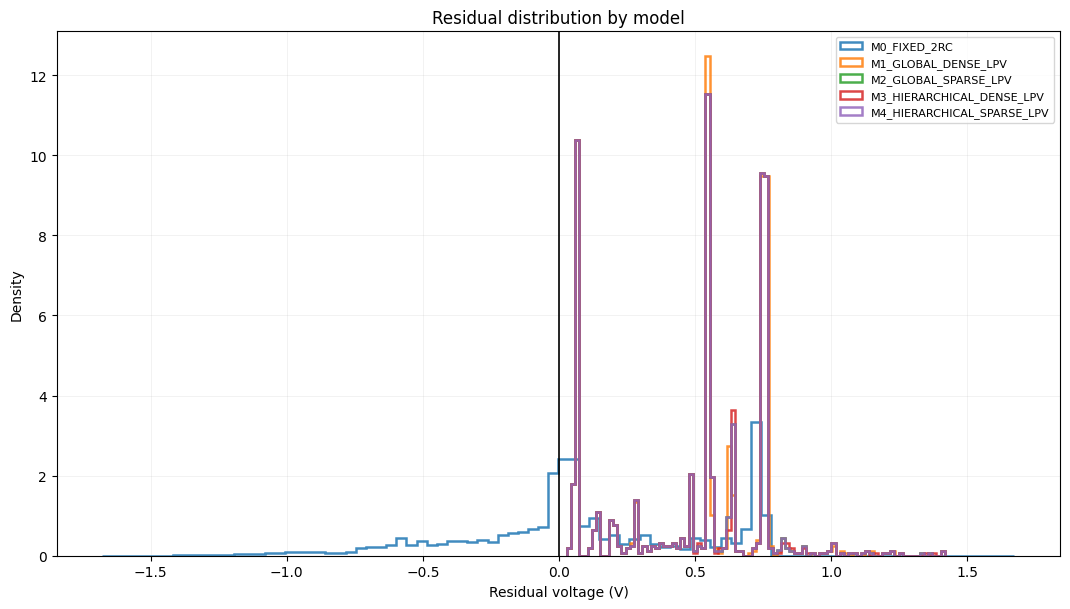

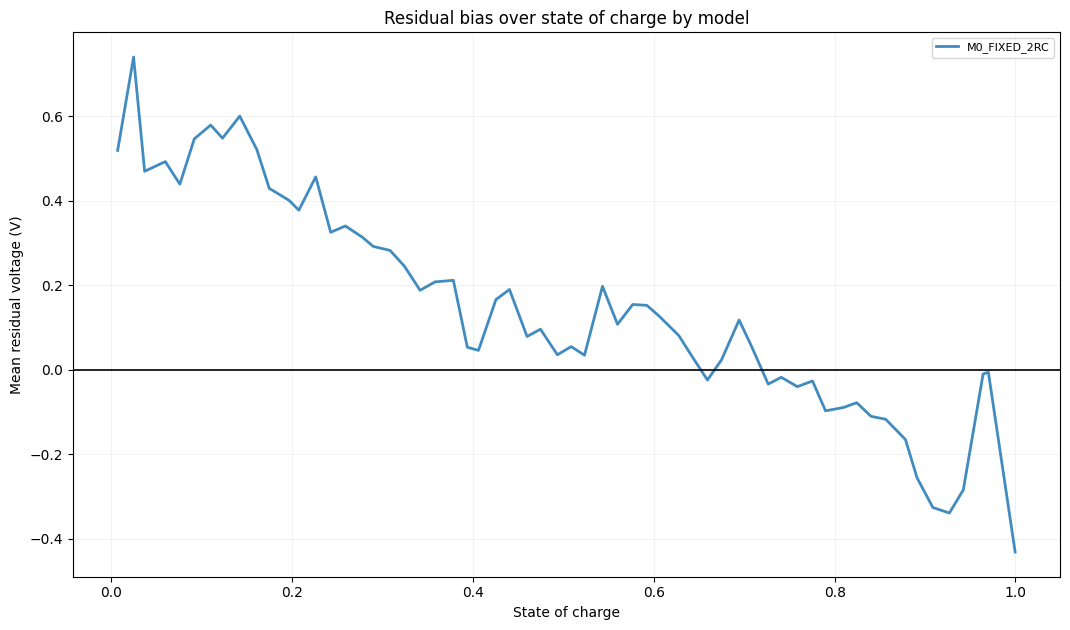

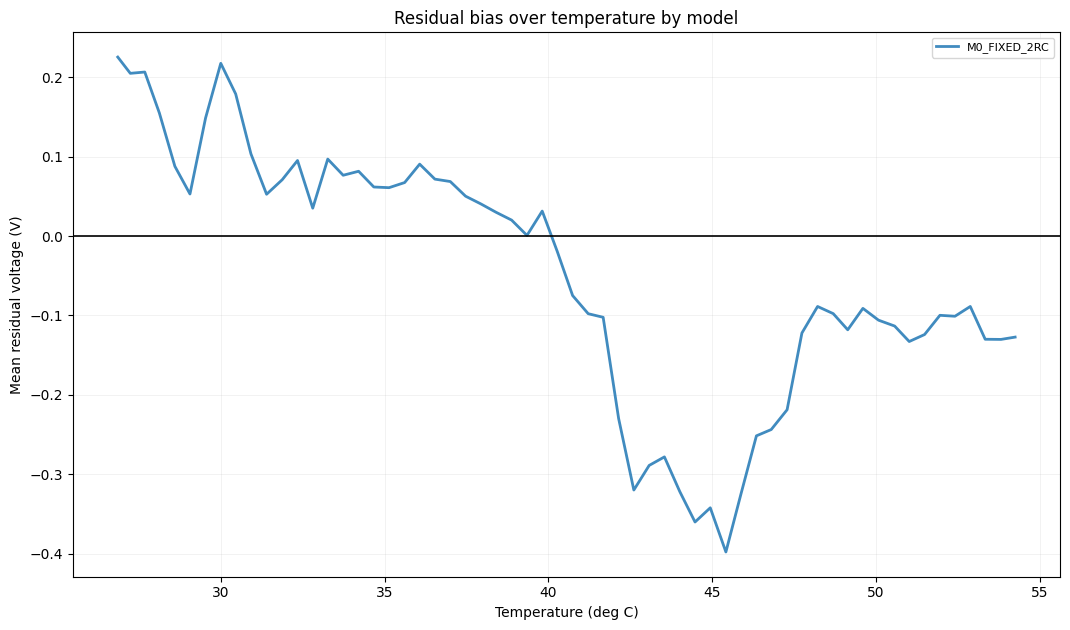

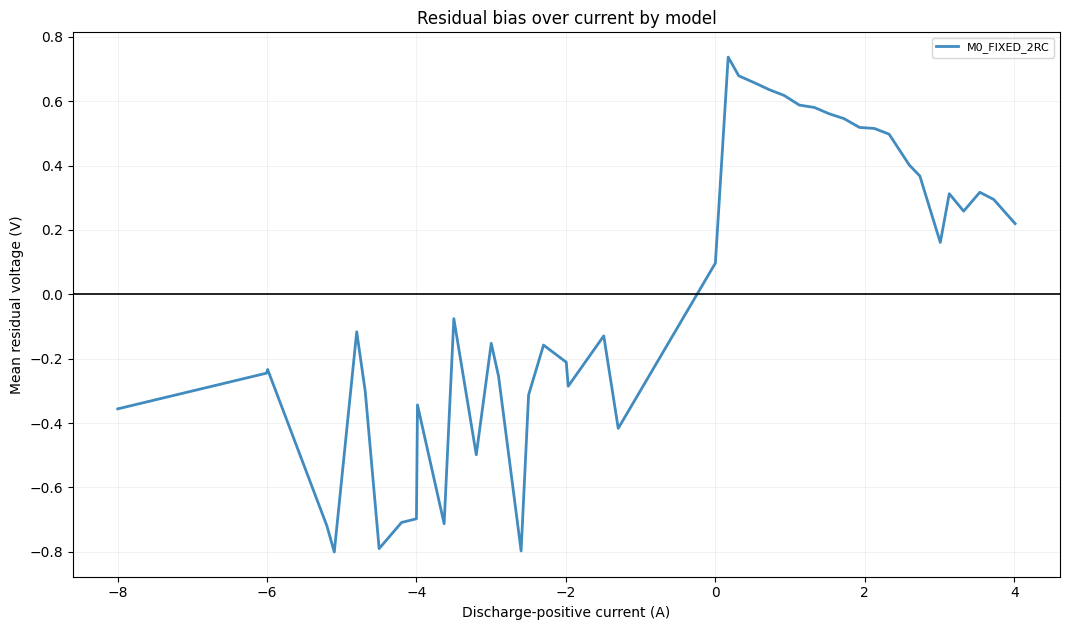

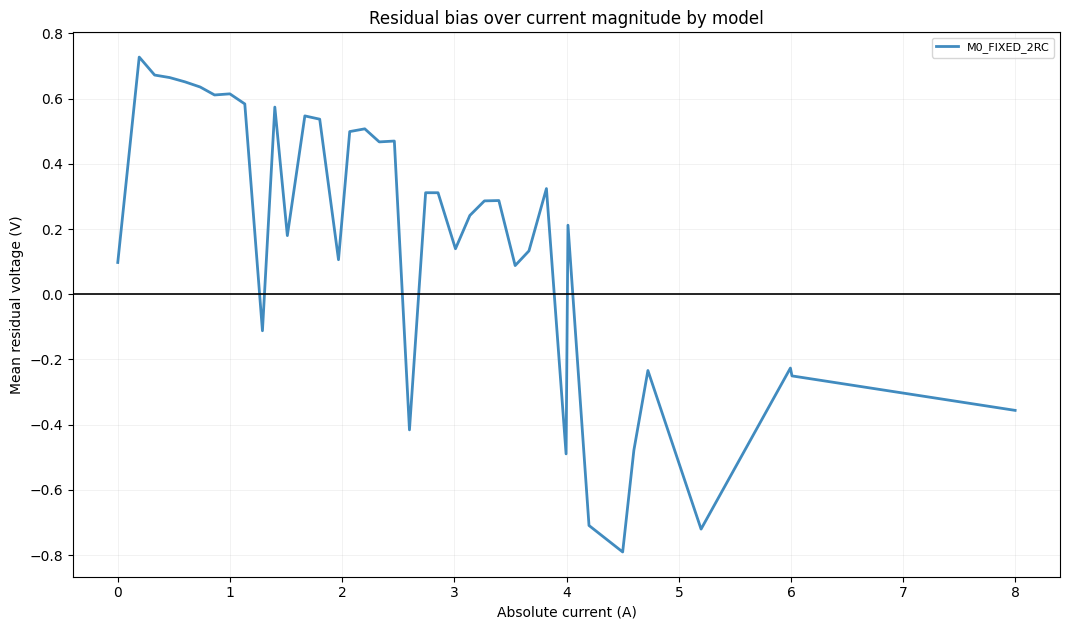

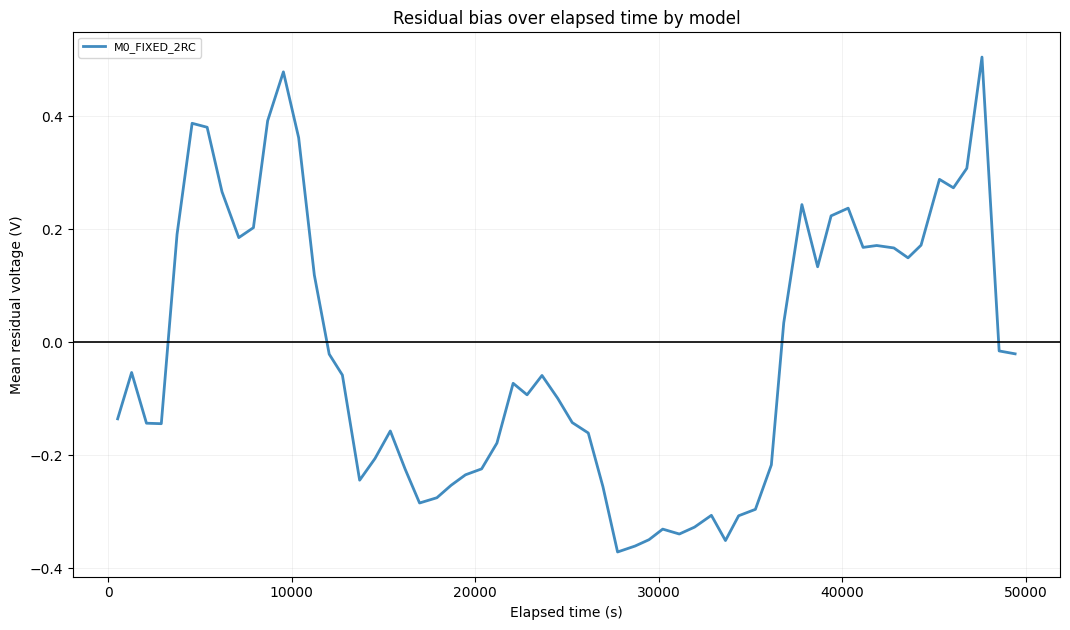

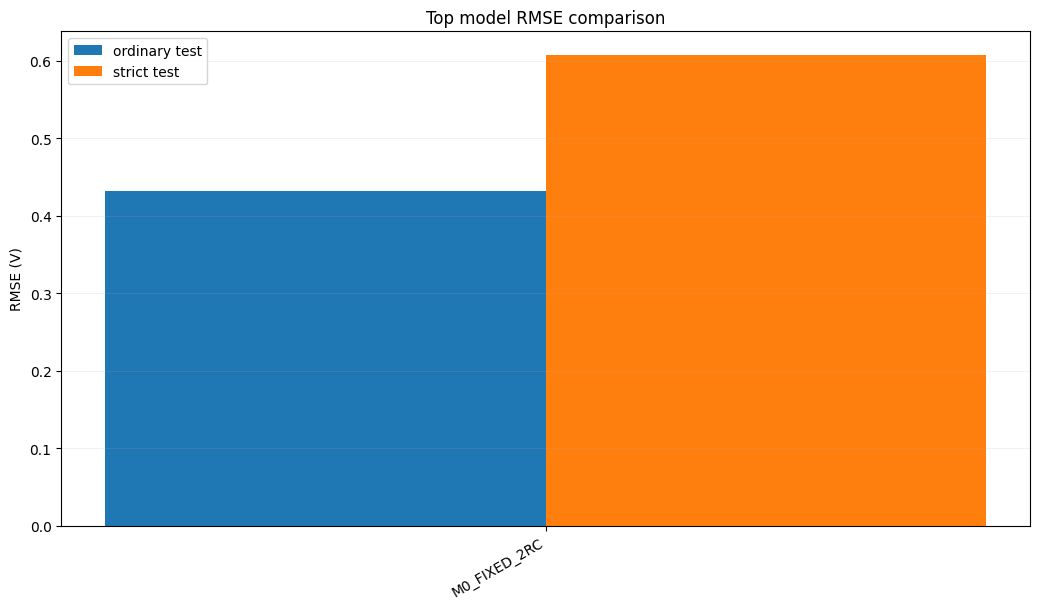

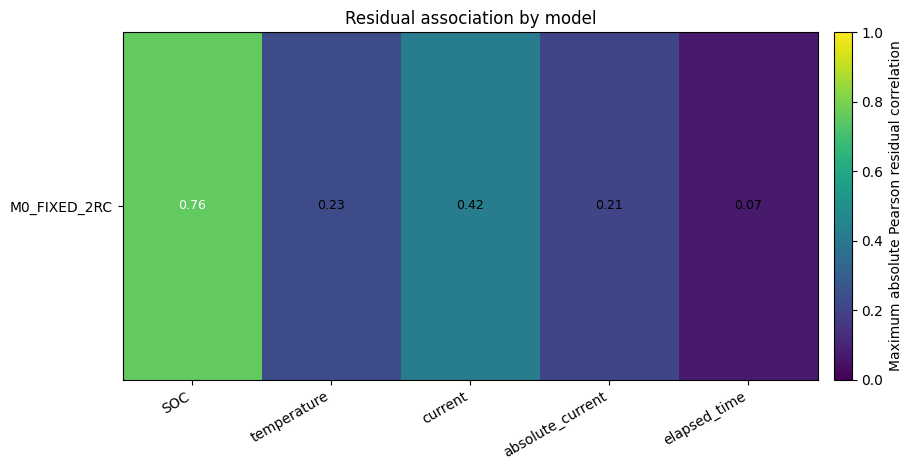

TOP MODEL RESIDUAL COMPARISON COMPLETE
Project root                    : /home/xzkhu/Downloads/batter_lpv_project
Top model IDs                   : ['M0_FIXED_2RC', 'M1_GLOBAL_DENSE_LPV', 'M2_GLOBAL_SPARSE_LPV', 'M3_HIERARCHICAL_DENSE_LPV', 'M4_HIERARCHICAL_SPARSE_LPV']
Models plotted                  : ['M0_FIXED_2RC', 'M1_GLOBAL_DENSE_LPV', 'M2_GLOBAL_SPARSE_LPV', 'M3_HIERARCHICAL_DENSE_LPV', 'M4_HIERARCHICAL_SPARSE_LPV']
Available prediction models      : 5
Final comparison table           : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/top_five_model_residual_comparison/tables/final_top_five_model_comparison_table.csv
Residual correlation table       : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/top_five_model_residual_comparison/tables/all_model_residual_correlations.csv
Figure directory                 : /home/xzkhu/Downloads/batter_lpv_project/data/processed/notebook_13/top_five_model_residual_comparison/figures
Figure manifest      

,candidate_id,test_rmse_v,strict_test_rmse_v,generalization_gap_v,maximum_residual_correlation,available_prediction_sample_count,available_sample_mean_residual_v,available_sample_rmse_v,available_sample_mae_v,available_sample_p95_abs_residual_v,...,sample_strict_test_rmse_v,sample_strict_test_bias_v,available_prediction_sample_count_from_sample,available_sample_mean_residual_v_from_sample,available_sample_rmse_v_from_sample,available_sample_mae_v_from_sample,available_sample_p95_abs_residual_v_from_sample,available_sample_max_abs_residual_v_from_sample,available_sample_max_abs_residual_correlation_from_corr,top_five_model_for_comparison
0,M0_FIXED_2RC,0.431588,0.607619,0.176031,0.904732,290130.0,0.095934,0.457549,0.346709,0.760499,...,0.607619,-0.448338,290130,0.095934,0.457549,0.346709,0.760499,1.676417,0.904732,True
1,M1_GLOBAL_DENSE_LPV,NaN,NaN,NaN,NaN,1018.0,0.506200,0.578918,0.506200,0.766890,...,NaN,NaN,1018,0.506200,0.578918,0.506200,0.766890,1.418401,NaN,True
2,M2_GLOBAL_SPARSE_LPV,NaN,NaN,NaN,NaN,5090.0,0.506111,0.578764,0.506111,0.767561,...,NaN,NaN,5090,0.506111,0.578764,0.506111,0.767561,1.417622,NaN,True
3,M3_HIERARCHICAL_DENSE_LPV,NaN,NaN,NaN,NaN,1018.0,0.506272,0.579000,0.506272,0.765823,...,NaN,NaN,1018,0.506272,0.579000,0.506272,0.765823,1.417619,NaN,True
4,M4_HIERARCHICAL_SPARSE_LPV,NaN,NaN,NaN,NaN,5090.0,0.506113,0.578768,0.506113,0.767556,...,NaN,NaN,5090,0.506113,0.578768,0.506113,0.767556,1.417621,NaN,True


,candidate_id,partition,predictor,pearson_residual_correlation,absolute_pearson_residual_correlation,sample_count
0,M0_FIXED_2RC,test,SOC,-0.762295,0.762295,249942
1,M0_FIXED_2RC,test,temperature,-0.073301,0.073301,249942
2,M0_FIXED_2RC,test,current,0.181336,0.181336,249942
3,M0_FIXED_2RC,test,absolute_current,0.071275,0.071275,249942
4,M0_FIXED_2RC,test,elapsed_time,-0.238437,0.238437,249942
...,...,...,...,...,...,...
60,M4_HIERARCHICAL_SPARSE_LPV,all_available,SOC,NaN,NaN,0
61,M4_HIERARCHICAL_SPARSE_LPV,all_available,temperature,NaN,NaN,0
62,M4_HIERARCHICAL_SPARSE_LPV,all_available,current,NaN,NaN,0
63,M4_HIERARCHICAL_SPARSE_LPV,all_available,absolute_current,NaN,NaN,0


,figure,title,description,png_path,pdf_path
0,residual_distribution_by_model,Residual distribution by model,Overlayed residual distributions for available...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
1,top_model_residual_bias_over_state_of_charge_b...,Residual bias over state of charge by model,Top model residual comparison over State of ch...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
2,top_model_residual_bias_over_temperature_by_model,Residual bias over temperature by model,Top model residual comparison over Temperature...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
3,top_model_residual_bias_over_current_by_model,Residual bias over current by model,Top model residual comparison over Discharge-p...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
4,top_model_residual_bias_over_current_magnitude...,Residual bias over current magnitude by model,Top model residual comparison over Absolute cu...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
5,top_model_residual_bias_over_elapsed_time_by_m...,Residual bias over elapsed time by model,Top model residual comparison over Elapsed tim...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
6,top_model_rmse_comparison,Top model RMSE comparison,Ordinary-test and strict-test RMSE comparison ...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...
7,top_model_residual_association_heatmap,Residual association by model,Residual-correlation heatmap for available top...,/home/xzkhu/Downloads/batter_lpv_project/data/...,/home/xzkhu/Downloads/batter_lpv_project/data/...


In [37]:
# ======================================================================================
# CELL 18D — ROBUST TOP-FIVE MODEL RESIDUAL COMPARISON WITHOUT SELECTED LABELS
# ======================================================================================
# Purpose
# -------
# This cell fixes the missing-column error:
#
#     KeyError: 'available_sample_max_abs_residual_correlation'
#
# and creates same-graph residual comparison plots for the available top models.
#
# Label rule
# ----------
# Plot legends use only model names. No "selected", "selected model", or similar labels
# are added to the plots.
# ======================================================================================

from pathlib import Path
from datetime import datetime, timezone
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ======================================================================================
# 1. SETTINGS AND DIRECTORIES
# ======================================================================================

TOP_N_MODELS_TO_COMPARE = int(globals().get("TOP_N_MODELS_TO_COMPARE", 5))
BIN_COUNT = int(globals().get("BIN_COUNT", 60))
MIN_SAMPLES_PER_CURVE = int(globals().get("MIN_SAMPLES_PER_CURVE", 50))
RANDOM_SEED = int(globals().get("RANDOM_SEED", 20260703))


def find_project_root_from_known_context() -> Path:
    preferred_root = Path("/home/xzkhu/Downloads/batter_lpv_project")

    if preferred_root.exists():
        return preferred_root.resolve()

    if "PROJECT_ROOT" in globals():
        candidate_root = Path(PROJECT_ROOT).expanduser().resolve()
        if candidate_root.exists():
            return candidate_root

    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate

    return current


PROJECT_ROOT = find_project_root_from_known_context()

NOTEBOOK_13_ROOT_DIR = PROJECT_ROOT / "data" / "processed" / "notebook_13"

NOTEBOOK_13_MODEL_COMPARISON_DIR = (
    NOTEBOOK_13_ROOT_DIR
    / "top_five_model_residual_comparison"
)

NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR = (
    NOTEBOOK_13_MODEL_COMPARISON_DIR
    / "tables"
)

NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR = (
    NOTEBOOK_13_MODEL_COMPARISON_DIR
    / "figures"
)

NOTEBOOK_13_MODEL_COMPARISON_CONTRACT_DIR = (
    NOTEBOOK_13_MODEL_COMPARISON_DIR
    / "contracts"
)

for directory in [
    NOTEBOOK_13_MODEL_COMPARISON_DIR,
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR,
    NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR,
    NOTEBOOK_13_MODEL_COMPARISON_CONTRACT_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ======================================================================================
# 2. SAFE HELPERS
# ======================================================================================

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def safe_numeric(values) -> pd.Series:
    return pd.to_numeric(values, errors="coerce")


def ensure_column(dataframe: pd.DataFrame, column: str, default_value=np.nan) -> pd.DataFrame:
    if column not in dataframe.columns:
        dataframe[column] = default_value
    return dataframe


def make_json_safe(value):
    if isinstance(value, Path):
        return str(value)

    if isinstance(value, (np.integer,)):
        return int(value)

    if isinstance(value, (np.floating,)):
        value = float(value)
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, (np.bool_,)):
        return bool(value)

    if isinstance(value, float):
        if math.isnan(value) or math.isinf(value):
            return None
        return value

    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}

    if isinstance(value, list):
        return [make_json_safe(item) for item in value]

    return value


def atomic_write_json(path: Path, payload: dict) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    temporary_path = path.with_suffix(path.suffix + ".tmp")

    with temporary_path.open("w", encoding="utf-8") as file:
        json.dump(make_json_safe(payload), file, indent=2, sort_keys=True)

    temporary_path.replace(path)


def safe_pearson(x_values: np.ndarray, y_values: np.ndarray) -> float:
    x_values = np.asarray(x_values, dtype=np.float64)
    y_values = np.asarray(y_values, dtype=np.float64)

    finite_mask = np.isfinite(x_values) & np.isfinite(y_values)

    if int(np.sum(finite_mask)) < 30:
        return np.nan

    x = x_values[finite_mask]
    y = y_values[finite_mask]

    if np.std(x) <= 0.0 or np.std(y) <= 0.0:
        return np.nan

    return float(np.corrcoef(x, y)[0, 1])


def load_table_from_global_or_file(global_name: str, file_path: Path) -> pd.DataFrame:
    if global_name in globals() and isinstance(globals()[global_name], pd.DataFrame):
        return globals()[global_name].copy()

    if file_path.exists():
        return pd.read_csv(file_path)

    return pd.DataFrame()


# ======================================================================================
# 3. LOAD AVAILABLE TABLES SAFELY
# ======================================================================================

CANDIDATE_SUMMARY_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "candidate_summary_from_notebook_12.csv"
)

ALL_MODEL_SAMPLE_METRICS_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "all_model_sample_residual_metrics.csv"
)

ALL_MODEL_CORRELATION_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "all_model_residual_correlations.csv"
)

ALL_MODEL_PREDICTION_SAMPLE_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "all_model_prediction_sample_long_format.csv"
)

CANDIDATE_SUMMARY_DF = load_table_from_global_or_file(
    "CANDIDATE_SUMMARY_DF",
    CANDIDATE_SUMMARY_PATH,
)

ALL_MODEL_SAMPLE_METRICS_DF = load_table_from_global_or_file(
    "ALL_MODEL_SAMPLE_METRICS_DF",
    ALL_MODEL_SAMPLE_METRICS_PATH,
)

ALL_MODEL_CORRELATION_DF = load_table_from_global_or_file(
    "ALL_MODEL_CORRELATION_DF",
    ALL_MODEL_CORRELATION_PATH,
)

ALL_MODEL_PREDICTION_SAMPLE_DF = load_table_from_global_or_file(
    "ALL_MODEL_PREDICTION_SAMPLE_DF",
    ALL_MODEL_PREDICTION_SAMPLE_PATH,
)


# ======================================================================================
# 4. BUILD A ROBUST FINAL COMPARISON TABLE
# ======================================================================================

if len(CANDIDATE_SUMMARY_DF) > 0:
    fixed_comparison_df = CANDIDATE_SUMMARY_DF.copy()
else:
    fixed_comparison_df = pd.DataFrame(columns=["candidate_id"])

fixed_comparison_df = ensure_column(fixed_comparison_df, "candidate_id", "")

fixed_comparison_df["candidate_id"] = fixed_comparison_df["candidate_id"].astype(str)

for column in [
    "test_rmse_v",
    "strict_test_rmse_v",
    "generalization_gap_v",
    "maximum_residual_correlation",
    "available_prediction_sample_count",
    "available_sample_mean_residual_v",
    "available_sample_rmse_v",
    "available_sample_mae_v",
    "available_sample_p95_abs_residual_v",
    "available_sample_max_abs_residual_v",
    "available_sample_max_abs_residual_correlation",
]:
    fixed_comparison_df = ensure_column(fixed_comparison_df, column, np.nan)


# --------------------------------------------------------------------------------------
# Add sample-based metrics if available.
# --------------------------------------------------------------------------------------

if len(ALL_MODEL_SAMPLE_METRICS_DF) > 0:
    ALL_MODEL_SAMPLE_METRICS_DF["candidate_id"] = (
        ALL_MODEL_SAMPLE_METRICS_DF["candidate_id"]
        .astype(str)
    )

    ALL_MODEL_SAMPLE_METRICS_DF["partition"] = (
        ALL_MODEL_SAMPLE_METRICS_DF["partition"]
        .astype(str)
    )

    for required_column in [
        "sample_count",
        "mean_residual_v",
        "sample_rmse_v",
        "sample_mae_v",
        "p95_abs_residual_v",
        "max_abs_residual_v",
    ]:
        ALL_MODEL_SAMPLE_METRICS_DF = ensure_column(
            ALL_MODEL_SAMPLE_METRICS_DF,
            required_column,
            np.nan,
        )

    ordinary_metric_df = (
        ALL_MODEL_SAMPLE_METRICS_DF
        .loc[
            ALL_MODEL_SAMPLE_METRICS_DF["partition"]
            .str.lower()
            .isin(["test", "ordinary_test", "ordinary", "validation_test"])
        ]
        .groupby("candidate_id", observed=True)
        .agg(
            sample_test_rmse_v=("sample_rmse_v", "mean"),
            sample_test_bias_v=("mean_residual_v", "mean"),
        )
        .reset_index()
    )

    strict_metric_df = (
        ALL_MODEL_SAMPLE_METRICS_DF
        .loc[
            ALL_MODEL_SAMPLE_METRICS_DF["partition"]
            .str.lower()
            .isin(["strict_test", "strict", "heldout_strict"])
        ]
        .groupby("candidate_id", observed=True)
        .agg(
            sample_strict_test_rmse_v=("sample_rmse_v", "mean"),
            sample_strict_test_bias_v=("mean_residual_v", "mean"),
        )
        .reset_index()
    )

    all_metric_df = (
        ALL_MODEL_SAMPLE_METRICS_DF
        .loc[ALL_MODEL_SAMPLE_METRICS_DF["partition"].str.lower().eq("all_available")]
        .groupby("candidate_id", observed=True)
        .agg(
            available_prediction_sample_count=("sample_count", "sum"),
            available_sample_mean_residual_v=("mean_residual_v", "mean"),
            available_sample_rmse_v=("sample_rmse_v", "mean"),
            available_sample_mae_v=("sample_mae_v", "mean"),
            available_sample_p95_abs_residual_v=("p95_abs_residual_v", "mean"),
            available_sample_max_abs_residual_v=("max_abs_residual_v", "max"),
        )
        .reset_index()
    )

    if len(ordinary_metric_df) > 0:
        fixed_comparison_df = fixed_comparison_df.merge(
            ordinary_metric_df,
            on="candidate_id",
            how="outer",
        )

        fixed_comparison_df["test_rmse_v"] = fixed_comparison_df["test_rmse_v"].fillna(
            fixed_comparison_df["sample_test_rmse_v"]
        )

    if len(strict_metric_df) > 0:
        fixed_comparison_df = fixed_comparison_df.merge(
            strict_metric_df,
            on="candidate_id",
            how="outer",
        )

        fixed_comparison_df["strict_test_rmse_v"] = fixed_comparison_df[
            "strict_test_rmse_v"
        ].fillna(
            fixed_comparison_df["sample_strict_test_rmse_v"]
        )

    if len(all_metric_df) > 0:
        fixed_comparison_df = fixed_comparison_df.merge(
            all_metric_df,
            on="candidate_id",
            how="outer",
            suffixes=("", "_from_sample"),
        )

        for column in [
            "available_prediction_sample_count",
            "available_sample_mean_residual_v",
            "available_sample_rmse_v",
            "available_sample_mae_v",
            "available_sample_p95_abs_residual_v",
            "available_sample_max_abs_residual_v",
        ]:
            from_sample_column = f"{column}_from_sample"

            fixed_comparison_df = ensure_column(fixed_comparison_df, column, np.nan)

            if from_sample_column in fixed_comparison_df.columns:
                fixed_comparison_df[column] = fixed_comparison_df[column].fillna(
                    fixed_comparison_df[from_sample_column]
                )


# --------------------------------------------------------------------------------------
# Add correlation safely.
# This is where the earlier code failed. Here the column is always created first.
# --------------------------------------------------------------------------------------

fixed_comparison_df = ensure_column(
    fixed_comparison_df,
    "available_sample_max_abs_residual_correlation",
    np.nan,
)

if len(ALL_MODEL_CORRELATION_DF) > 0:
    ALL_MODEL_CORRELATION_DF["candidate_id"] = (
        ALL_MODEL_CORRELATION_DF["candidate_id"]
        .astype(str)
    )

    ALL_MODEL_CORRELATION_DF = ensure_column(
        ALL_MODEL_CORRELATION_DF,
        "absolute_pearson_residual_correlation",
        np.nan,
    )

    corr_summary_df = (
        ALL_MODEL_CORRELATION_DF
        .groupby("candidate_id", observed=True)
        .agg(
            available_sample_max_abs_residual_correlation=(
                "absolute_pearson_residual_correlation",
                "max",
            )
        )
        .reset_index()
    )

    if len(corr_summary_df) > 0:
        fixed_comparison_df = fixed_comparison_df.merge(
            corr_summary_df,
            on="candidate_id",
            how="outer",
            suffixes=("", "_from_corr"),
        )

        if "available_sample_max_abs_residual_correlation_from_corr" in fixed_comparison_df.columns:
            fixed_comparison_df["available_sample_max_abs_residual_correlation"] = (
                fixed_comparison_df["available_sample_max_abs_residual_correlation"]
                .fillna(
                    fixed_comparison_df[
                        "available_sample_max_abs_residual_correlation_from_corr"
                    ]
                )
            )

fixed_comparison_df = ensure_column(
    fixed_comparison_df,
    "maximum_residual_correlation",
    np.nan,
)

fixed_comparison_df["maximum_residual_correlation"] = fixed_comparison_df[
    "maximum_residual_correlation"
].fillna(
    fixed_comparison_df["available_sample_max_abs_residual_correlation"]
)


# --------------------------------------------------------------------------------------
# Numeric cleanup and ranking.
# --------------------------------------------------------------------------------------

for column in [
    "test_rmse_v",
    "strict_test_rmse_v",
    "generalization_gap_v",
    "maximum_residual_correlation",
    "available_prediction_sample_count",
    "available_sample_mean_residual_v",
    "available_sample_rmse_v",
    "available_sample_mae_v",
    "available_sample_p95_abs_residual_v",
    "available_sample_max_abs_residual_v",
    "available_sample_max_abs_residual_correlation",
]:
    fixed_comparison_df[column] = safe_numeric(fixed_comparison_df[column])

fixed_comparison_df["generalization_gap_v"] = (
    fixed_comparison_df["strict_test_rmse_v"]
    - fixed_comparison_df["test_rmse_v"]
)

fixed_comparison_df = fixed_comparison_df.loc[
    fixed_comparison_df["candidate_id"].astype(str).str.len().gt(0)
].copy()

fixed_comparison_df = fixed_comparison_df.loc[
    ~fixed_comparison_df["candidate_id"].astype(str).str.lower().isin(
        ["nan", "none", "not_available"]
    )
].copy()

if fixed_comparison_df["strict_test_rmse_v"].notna().any():
    ranking_metric = "strict_test_rmse_v"
elif fixed_comparison_df["test_rmse_v"].notna().any():
    ranking_metric = "test_rmse_v"
elif fixed_comparison_df["available_sample_rmse_v"].notna().any():
    ranking_metric = "available_sample_rmse_v"
else:
    ranking_metric = "candidate_id"

if ranking_metric == "candidate_id":
    fixed_comparison_df = fixed_comparison_df.sort_values(
        "candidate_id",
        ascending=True,
    )
else:
    fixed_comparison_df = fixed_comparison_df.sort_values(
        ranking_metric,
        ascending=True,
        na_position="last",
    )

fixed_comparison_df = fixed_comparison_df.reset_index(drop=True)

TOP_FIVE_MODEL_IDS = (
    fixed_comparison_df["candidate_id"]
    .astype(str)
    .head(TOP_N_MODELS_TO_COMPARE)
    .to_list()
)

fixed_comparison_df["top_five_model_for_comparison"] = (
    fixed_comparison_df["candidate_id"]
    .astype(str)
    .isin(TOP_FIVE_MODEL_IDS)
)

FINAL_MODEL_COMPARISON_DF = fixed_comparison_df.copy()

FINAL_MODEL_COMPARISON_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "final_top_five_model_comparison_table.csv"
)

FINAL_MODEL_COMPARISON_DF.to_csv(
    FINAL_MODEL_COMPARISON_PATH,
    index=False,
)


# ======================================================================================
# 5. DETERMINE MODELS AVAILABLE FOR SAME-GRAPH RESIDUAL PLOTS
# ======================================================================================

if len(ALL_MODEL_PREDICTION_SAMPLE_DF) > 0:
    ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"] = (
        ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"]
        .astype(str)
    )

    available_prediction_model_ids = set(
        ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"]
        .astype(str)
        .unique()
    )

    PLOTTED_MODEL_IDS = [
        model_id
        for model_id in TOP_FIVE_MODEL_IDS
        if model_id in available_prediction_model_ids
    ]

    if len(PLOTTED_MODEL_IDS) == 0:
        PLOTTED_MODEL_IDS = (
            ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"]
            .astype(str)
            .drop_duplicates()
            .head(TOP_N_MODELS_TO_COMPARE)
            .to_list()
        )
else:
    available_prediction_model_ids = set()
    PLOTTED_MODEL_IDS = []


# ======================================================================================
# 6. REBUILD CORRELATIONS IF NEEDED
# ======================================================================================

def rebuild_all_model_correlation_if_needed() -> pd.DataFrame:
    if len(ALL_MODEL_CORRELATION_DF) > 0:
        return ALL_MODEL_CORRELATION_DF.copy()

    if len(ALL_MODEL_PREDICTION_SAMPLE_DF) == 0:
        return pd.DataFrame()

    predictor_specs = [
        ("SOC", "soc_for_ocv"),
        ("temperature", "temperature_c"),
        ("current", "current_discharge_a"),
        ("absolute_current", "abs_current_a"),
        ("elapsed_time", "elapsed_time_s"),
    ]

    records = []

    for candidate_id, group_df in ALL_MODEL_PREDICTION_SAMPLE_DF.groupby(
        "candidate_id",
        sort=False,
        observed=True,
    ):
        residual_values = safe_numeric(group_df["residual_v"]).to_numpy(dtype=np.float64)

        for predictor_name, predictor_column in predictor_specs:
            if predictor_column not in group_df.columns:
                continue

            predictor_values = safe_numeric(group_df[predictor_column]).to_numpy(dtype=np.float64)

            corr_value = safe_pearson(predictor_values, residual_values)

            records.append(
                {
                    "candidate_id": str(candidate_id),
                    "partition": "all_available",
                    "predictor": predictor_name,
                    "pearson_residual_correlation": corr_value,
                    "absolute_pearson_residual_correlation": (
                        abs(corr_value) if np.isfinite(corr_value) else np.nan
                    ),
                    "sample_count": int(
                        np.sum(np.isfinite(predictor_values) & np.isfinite(residual_values))
                    ),
                }
            )

    return pd.DataFrame(records)


ALL_MODEL_CORRELATION_DF = rebuild_all_model_correlation_if_needed()

ALL_MODEL_CORRELATION_DF.to_csv(
    ALL_MODEL_CORRELATION_PATH,
    index=False,
)


# ======================================================================================
# 7. FIGURE HELPERS
# ======================================================================================

figure_records = []


def save_figure(filename_stem: str, title: str, description: str) -> tuple[Path, Path]:
    png_path = NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR / f"{filename_stem}.pdf"

    plt.tight_layout()
    plt.savefig(png_path, dpi=320, bbox_inches="tight", facecolor="white")
    plt.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close()

    figure_records.append(
        {
            "figure": filename_stem,
            "title": title,
            "description": description,
            "png_path": str(png_path),
            "pdf_path": str(pdf_path),
        }
    )

    return png_path, pdf_path


# ======================================================================================
# 8. SAME-GRAPH RESIDUAL PLOTS
# ======================================================================================

def plot_residual_distribution_by_model() -> None:
    if len(ALL_MODEL_PREDICTION_SAMPLE_DF) == 0 or len(PLOTTED_MODEL_IDS) == 0:
        print("Skipping residual distribution by model: no per-model prediction sample data.")
        return

    plot_df = ALL_MODEL_PREDICTION_SAMPLE_DF.loc[
        ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"].astype(str).isin(PLOTTED_MODEL_IDS)
    ].copy()

    plot_df["residual_v"] = safe_numeric(plot_df["residual_v"])
    plot_df = plot_df.dropna(subset=["residual_v"])

    if len(plot_df) == 0:
        print("Skipping residual distribution by model: no finite residuals.")
        return

    plt.figure(figsize=(10.8, 6.2))

    for candidate_id, candidate_df in plot_df.groupby("candidate_id", sort=False, observed=True):
        residual = safe_numeric(candidate_df["residual_v"]).to_numpy(dtype=np.float64)
        residual = residual[np.isfinite(residual)]

        if residual.size < 10:
            continue

        plt.hist(
            residual,
            bins=90,
            density=True,
            histtype="step",
            linewidth=1.8,
            alpha=0.85,
            label=str(candidate_id),
        )

    plt.axvline(0.0, color="black", linewidth=1.2)
    plt.xlabel("Residual voltage (V)")
    plt.ylabel("Density")
    plt.title("Residual distribution by model")
    plt.grid(True, alpha=0.18, linewidth=0.6)
    plt.legend(loc="best", fontsize=8)

    save_figure(
        "residual_distribution_by_model",
        "Residual distribution by model",
        "Overlayed residual distributions for available top models.",
    )


def plot_overlay_binned_residual(
    predictor_column: str,
    x_label: str,
    title: str,
    filename_stem: str,
) -> None:
    if len(ALL_MODEL_PREDICTION_SAMPLE_DF) == 0 or len(PLOTTED_MODEL_IDS) == 0:
        print(f"Skipping {title}: no per-model prediction sample data.")
        return

    if predictor_column not in ALL_MODEL_PREDICTION_SAMPLE_DF.columns:
        print(f"Skipping {title}: missing column {predictor_column}.")
        return

    plot_df = ALL_MODEL_PREDICTION_SAMPLE_DF.loc[
        ALL_MODEL_PREDICTION_SAMPLE_DF["candidate_id"].astype(str).isin(PLOTTED_MODEL_IDS)
    ].copy()

    plot_df[predictor_column] = safe_numeric(plot_df[predictor_column])
    plot_df["residual_v"] = safe_numeric(plot_df["residual_v"])

    plot_df = plot_df.replace([np.inf, -np.inf], np.nan)
    plot_df = plot_df.dropna(subset=[predictor_column, "residual_v"])

    if len(plot_df) == 0:
        print(f"Skipping {title}: no finite plotting rows.")
        return

    plt.figure(figsize=(10.8, 6.4))

    curve_records = []

    for candidate_id, candidate_df in plot_df.groupby("candidate_id", sort=False, observed=True):
        if len(candidate_df) < MIN_SAMPLES_PER_CURVE:
            continue

        candidate_df = candidate_df.copy()
        candidate_df["_bin"] = pd.cut(candidate_df[predictor_column], bins=BIN_COUNT)

        curve_df = (
            candidate_df
            .groupby("_bin", observed=True)
            .agg(
                x_mean=(predictor_column, "mean"),
                residual_mean=("residual_v", "mean"),
                residual_median=("residual_v", "median"),
                residual_q25=("residual_v", lambda x: float(np.quantile(x, 0.25))),
                residual_q75=("residual_v", lambda x: float(np.quantile(x, 0.75))),
                sample_count=("residual_v", "size"),
            )
            .dropna()
            .reset_index(drop=True)
        )

        if len(curve_df) < 2:
            continue

        plt.plot(
            curve_df["x_mean"],
            curve_df["residual_mean"],
            linewidth=2.0,
            alpha=0.85,
            label=str(candidate_id),
        )

        for _, row in curve_df.iterrows():
            curve_records.append(
                {
                    "candidate_id": str(candidate_id),
                    "predictor": predictor_column,
                    "x_mean": float(row["x_mean"]),
                    "residual_mean_v": float(row["residual_mean"]),
                    "residual_median_v": float(row["residual_median"]),
                    "residual_q25_v": float(row["residual_q25"]),
                    "residual_q75_v": float(row["residual_q75"]),
                    "sample_count": int(row["sample_count"]),
                }
            )

    plt.axhline(0.0, color="black", linewidth=1.2)
    plt.xlabel(x_label)
    plt.ylabel("Mean residual voltage (V)")
    plt.title(title)
    plt.grid(True, alpha=0.18, linewidth=0.6)
    plt.legend(loc="best", fontsize=8)

    save_figure(filename_stem, title, f"Top model residual comparison over {x_label}.")

    if curve_records:
        curve_table_path = (
            NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
            / f"{filename_stem}_curve_table.csv"
        )

        pd.DataFrame(curve_records).to_csv(curve_table_path, index=False)


def plot_top_model_rmse_comparison() -> None:
    plot_df = FINAL_MODEL_COMPARISON_DF.loc[
        FINAL_MODEL_COMPARISON_DF["candidate_id"].astype(str).isin(TOP_FIVE_MODEL_IDS)
    ].copy()

    if len(plot_df) == 0:
        print("Skipping RMSE comparison: no top-model rows available.")
        return

    for column in ["test_rmse_v", "strict_test_rmse_v", "available_sample_rmse_v"]:
        plot_df[column] = safe_numeric(plot_df[column])

    paired_df = plot_df.dropna(subset=["test_rmse_v", "strict_test_rmse_v"], how="any").copy()

    if len(paired_df) > 0:
        paired_df = paired_df.sort_values("strict_test_rmse_v", ascending=True)

        x = np.arange(len(paired_df))
        width = 0.38

        plt.figure(figsize=(max(10.5, 1.15 * len(paired_df)), 6.2))
        plt.bar(x - width / 2.0, paired_df["test_rmse_v"], width, label="ordinary test")
        plt.bar(x + width / 2.0, paired_df["strict_test_rmse_v"], width, label="strict test")
        plt.xticks(x, paired_df["candidate_id"].astype(str), rotation=30, ha="right")
        plt.ylabel("RMSE (V)")
        plt.title("Top model RMSE comparison")
        plt.grid(True, axis="y", alpha=0.18, linewidth=0.6)
        plt.legend(loc="best")

        save_figure(
            "top_model_rmse_comparison",
            "Top model RMSE comparison",
            "Ordinary-test and strict-test RMSE comparison for top models.",
        )

        return

    available_df = plot_df.dropna(subset=["available_sample_rmse_v"], how="any").copy()

    if len(available_df) > 0:
        available_df = available_df.sort_values("available_sample_rmse_v", ascending=True)

        plt.figure(figsize=(10.5, max(4.8, 0.45 * len(available_df) + 1.4)))
        plt.barh(available_df["candidate_id"].astype(str), available_df["available_sample_rmse_v"])
        plt.xlabel("Available-sample RMSE (V)")
        plt.title("Top model RMSE comparison")
        plt.grid(True, axis="x", alpha=0.18, linewidth=0.6)

        save_figure(
            "top_model_rmse_comparison",
            "Top model RMSE comparison",
            "Available-sample RMSE comparison for top models.",
        )

        return

    print("Skipping RMSE comparison: no RMSE metric is available.")


def plot_residual_correlation_heatmap() -> None:
    if len(ALL_MODEL_CORRELATION_DF) == 0 or len(PLOTTED_MODEL_IDS) == 0:
        print("Skipping residual association heatmap: no correlation data.")
        return

    plot_df = ALL_MODEL_CORRELATION_DF.copy()

    if "partition" in plot_df.columns:
        all_rows = plot_df.loc[plot_df["partition"].astype(str).eq("all_available")].copy()
        if len(all_rows) > 0:
            plot_df = all_rows

    plot_df = plot_df.loc[
        plot_df["candidate_id"].astype(str).isin(PLOTTED_MODEL_IDS)
    ].copy()

    if len(plot_df) == 0:
        print("Skipping residual association heatmap: no plotted model correlation rows.")
        return

    pivot_df = plot_df.pivot_table(
        index="candidate_id",
        columns="predictor",
        values="absolute_pearson_residual_correlation",
        aggfunc="max",
    )

    preferred_columns = ["SOC", "temperature", "current", "absolute_current", "elapsed_time"]
    available_columns = [column for column in preferred_columns if column in pivot_df.columns]

    pivot_df = pivot_df[available_columns]

    if len(pivot_df) == 0 or len(pivot_df.columns) == 0:
        print("Skipping residual association heatmap: empty pivot table.")
        return

    plt.figure(figsize=(9.8, max(4.8, 0.48 * len(pivot_df) + 1.5)))

    image = plt.imshow(
        pivot_df.to_numpy(dtype=np.float64),
        aspect="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    plt.xticks(np.arange(len(pivot_df.columns)), pivot_df.columns, rotation=30, ha="right")
    plt.yticks(np.arange(len(pivot_df.index)), pivot_df.index)
    plt.title("Residual association by model")

    axis = plt.gca()

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            value = pivot_df.iloc[i, j]
            if np.isfinite(value):
                axis.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="white" if value > 0.55 else "black",
                )

    colorbar = plt.colorbar(image, pad=0.02)
    colorbar.set_label("Maximum absolute Pearson residual correlation")

    save_figure(
        "top_model_residual_association_heatmap",
        "Residual association by model",
        "Residual-correlation heatmap for available top models.",
    )


# ======================================================================================
# 9. CREATE FIGURES
# ======================================================================================

plot_residual_distribution_by_model()

plot_overlay_binned_residual(
    predictor_column="soc_for_ocv",
    x_label="State of charge",
    title="Residual bias over state of charge by model",
    filename_stem="top_model_residual_bias_over_state_of_charge_by_model",
)

plot_overlay_binned_residual(
    predictor_column="temperature_c",
    x_label="Temperature (deg C)",
    title="Residual bias over temperature by model",
    filename_stem="top_model_residual_bias_over_temperature_by_model",
)

plot_overlay_binned_residual(
    predictor_column="current_discharge_a",
    x_label="Discharge-positive current (A)",
    title="Residual bias over current by model",
    filename_stem="top_model_residual_bias_over_current_by_model",
)

plot_overlay_binned_residual(
    predictor_column="abs_current_a",
    x_label="Absolute current (A)",
    title="Residual bias over current magnitude by model",
    filename_stem="top_model_residual_bias_over_current_magnitude_by_model",
)

plot_overlay_binned_residual(
    predictor_column="elapsed_time_s",
    x_label="Elapsed time (s)",
    title="Residual bias over elapsed time by model",
    filename_stem="top_model_residual_bias_over_elapsed_time_by_model",
)

plot_top_model_rmse_comparison()

plot_residual_correlation_heatmap()


# ======================================================================================
# 10. SAVE MANIFEST AND CONTRACT
# ======================================================================================

FIGURE_MANIFEST_DF = pd.DataFrame(figure_records)

FIGURE_MANIFEST_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_TABLE_DIR
    / "top_model_residual_comparison_figure_manifest.csv"
)

FIGURE_MANIFEST_DF.to_csv(FIGURE_MANIFEST_PATH, index=False)

available_prediction_model_count = int(len(available_prediction_model_ids))

COMPARISON_CONTRACT_PATH = (
    NOTEBOOK_13_MODEL_COMPARISON_CONTRACT_DIR
    / "top_model_residual_comparison_contract.json"
)

comparison_contract = {
    "created_at_utc": utc_now_iso(),
    "project_root": str(PROJECT_ROOT),
    "top_n_models_requested": TOP_N_MODELS_TO_COMPARE,
    "top_model_ids": TOP_FIVE_MODEL_IDS,
    "plotted_model_ids": PLOTTED_MODEL_IDS,
    "available_prediction_model_count": available_prediction_model_count,
    "final_comparison_table": str(FINAL_MODEL_COMPARISON_PATH),
    "correlation_table": str(ALL_MODEL_CORRELATION_PATH),
    "figure_manifest": str(FIGURE_MANIFEST_PATH),
    "figure_directory": str(NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR),
    "label_rule": "Legends use model names only.",
}

atomic_write_json(COMPARISON_CONTRACT_PATH, comparison_contract)


# ======================================================================================
# 11. DISPLAY SUMMARY
# ======================================================================================

print("=" * 110)
print("TOP MODEL RESIDUAL COMPARISON COMPLETE")
print("=" * 110)
print(f"Project root                    : {PROJECT_ROOT}")
print(f"Top model IDs                   : {TOP_FIVE_MODEL_IDS}")
print(f"Models plotted                  : {PLOTTED_MODEL_IDS}")
print(f"Available prediction models      : {available_prediction_model_count:,}")
print(f"Final comparison table           : {FINAL_MODEL_COMPARISON_PATH}")
print(f"Residual correlation table       : {ALL_MODEL_CORRELATION_PATH}")
print(f"Figure directory                 : {NOTEBOOK_13_MODEL_COMPARISON_FIGURE_DIR}")
print(f"Figure manifest                  : {FIGURE_MANIFEST_PATH}")
print(f"Comparison contract              : {COMPARISON_CONTRACT_PATH}")
print("=" * 110)

display(FINAL_MODEL_COMPARISON_DF)
display(ALL_MODEL_CORRELATION_DF)
display(FIGURE_MANIFEST_DF)